In [10]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import numpy as np

In [11]:
with open("../ford_categories.json", "r", encoding='utf-8') as file:
    ford_categories = json.load(file)

In [12]:
df_c19 = pd.read_csv('../data/c19_final.csv')
df_m17 = pd.read_csv('../data/m17_final.csv')
df_c19 = df_c19.astype({'cited':'int32'})
df_m17 = df_m17.astype({'evaluation':'int32'})

In [13]:
def plot_categorical_distribution(df, target_variable, categorical_variable):
    plt.figure(figsize=(10, 6))
    data = '_c19' if target_variable == 'cited' else '_m17'
    sns.set_palette('viridis')

    if df[df[categorical_variable] == 'medium'].shape[0] != 0:
        category_order = ['low', 'medium', 'high']
        ax = sns.countplot(data=df, x=categorical_variable, hue=target_variable, order=category_order, palette='viridis')
    else:
        ax = sns.countplot(data=df, x=categorical_variable, hue=target_variable, palette='viridis')
    
    plt.ylabel('Count')
    if '0' in categorical_variable:
        categorical_variable = ford_categories[categorical_variable]
    plt.xlabel(categorical_variable)

    plt.title(f'Distribution of {categorical_variable} by {target_variable}')

    for p in ax.patches:
        if p.get_height() != 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                        textcoords='offset points')

    plt.legend(title=target_variable)
    plt.xticks(rotation=45)  

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.show()


from scipy.stats import chi2_contingency
from sklearn.utils import resample

def get_stat_significance(df, categorical_variable, target_variable, n_bootstrap=2500):
    cross_tab = pd.crosstab(df[categorical_variable], df[target_variable])

    chi2, p_val, _, expected_freq = chi2_contingency(cross_tab)

    # Calculate effect size (Cramér's V)
    n = cross_tab.sum().sum()  # total number of observations
    k = min(cross_tab.shape) - 1  # smaller of (rows - 1) or (columns - 1)
    cramers_v = np.sqrt(chi2 / (n * k))

    # Bootstrap validation
    bootstrap_p_values = []
    i = 0
    for _ in range(n_bootstrap):
        df_sample = resample(df)
        cross_tab_sample = pd.crosstab(df_sample[categorical_variable], df_sample[target_variable])
        if cross_tab_sample.shape == cross_tab.shape:  # Ensure same shape for comparison
            chi2_sample, p_val_sample, _, _ = chi2_contingency(cross_tab_sample)
            if p_val_sample < 0.05:
                i+= 1
            bootstrap_p_values.append(p_val_sample)

    mean_p_val = np.mean(bootstrap_p_values)

    # print(f"Chi-Squared Value: {chi2}")
    print(f"Original P-value: {p_val}")
    print(f"Bootstrap Mean P-value: {mean_p_val}")
    print(f"Relationship is significant in {i}/{n_bootstrap} bootstrap samples.")

    print(f"Cramér's V (Effect Size): {cramers_v}")

    # Interpret effect size (Cramér's V)
    effect_size_interpretation = (
        "Weak association" if cramers_v <= 0.1 else
        "Moderate association" if cramers_v <= 0.3 else
        "Strong association"
    )
    print(f"Effect Size: {effect_size_interpretation}")

    if p_val < 0.05:
        print(f"Significant association between {categorical_variable} and {target_variable}.")
    else:
        print(f"No significant association between {categorical_variable} and {target_variable}.")

    print("---------------------------------------------------------------")



# def get_stat_significance(df, categorical_variable, target_variable):
#     cross_tab = pd.crosstab(df[categorical_variable], df[target_variable])
#     # print(cross_tab)
# 
#     chi2, p_val, _, expected_freq = chi2_contingency(cross_tab)
# 
#     # Calculate effect size (Cramér's V)
#     n = cross_tab.sum().sum()  # total number of observations
#     k = min(cross_tab.shape) - 1  # smaller of (rows - 1) or (columns - 1)
#     cramers_v = np.sqrt(chi2 / (n * k))
# 
#     print("Chi-Squared Value:", chi2)
#     print("P-value:", p_val)
#     print("Cramér's V (Effect Size):", cramers_v)
# 
#     # Interpret effect size (Cramér's V)
#     if cramers_v <= 0.1:
#         effect_size_interpretation = "Weak association"
#     elif cramers_v <= 0.3:
#         effect_size_interpretation = "Moderate association"
#     else:
#         effect_size_interpretation = "Strong association"
# 
#     print("Effect Size:", effect_size_interpretation)
# 
#     if p_val < 0.05:
#         print(f"There is a significant association between {categorical_variable} and {target_variable}.")
#     else:
#         print(f"There is no significant association between {categorical_variable} and {target_variable}")
# 
#     print("---------------------------------------------------------------")

Original P-value: 0.0008586505323392688
Bootstrap Mean P-value: 0.01369089797714467
Relationship is significant in 2357/2500 bootstrap samples.
Cramér's V (Effect Size): 0.06862875226025426
Effect Size: Weak association
Significant association between novelty and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_36308\3151116547.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


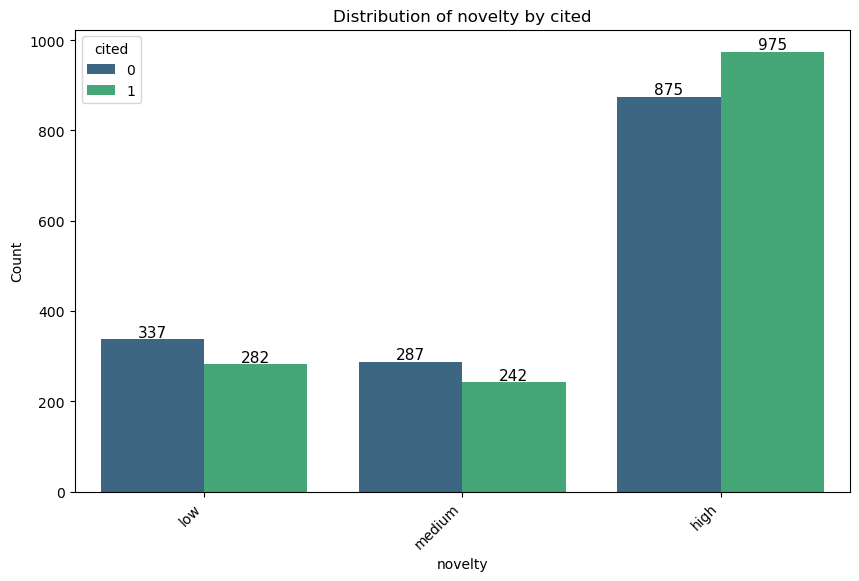

Original P-value: 1.9920906553215145e-47
Bootstrap Mean P-value: 6.775595841495012e-31
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.24508303513948965
Effect Size: Moderate association
Significant association between novelty and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_36308\3151116547.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


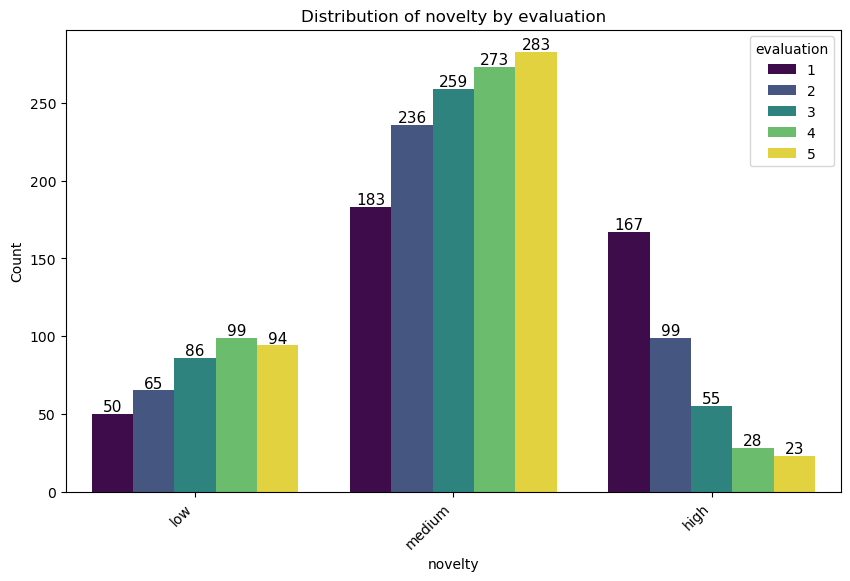

In [14]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='novelty')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="novelty")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='novelty')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="novelty")

In [ ]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='basic_medicine')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="basic_medicine")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='basic_medicine')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="basic_medicine")

Original P-value: 0.0661537695532712
Bootstrap Mean P-value: 0.16504899226084682
Relationship is significant in 500/1000 boostrap samples.
Cramér's V (Effect Size): 0.03355700919216443
Effect Size: Weak association
No significant association between applied_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_36308\2662959644.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


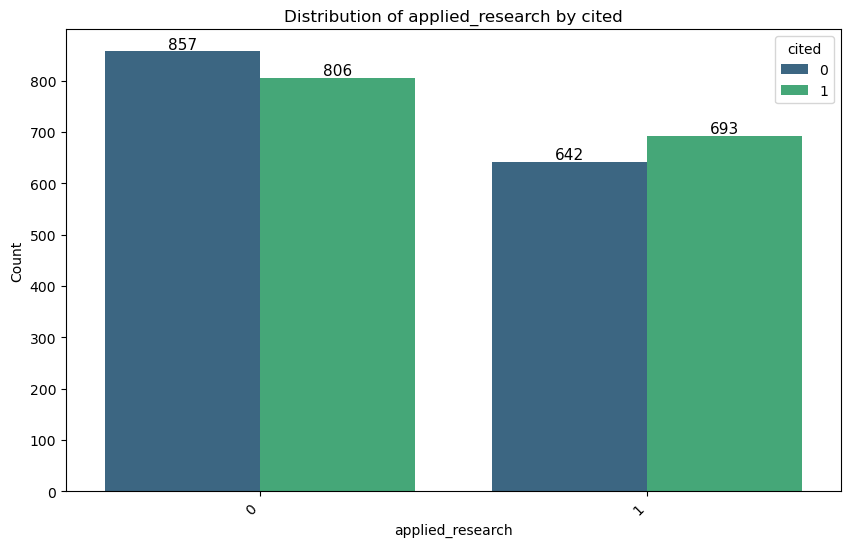

Original P-value: 7.516505691881802e-10
Bootstrap Mean P-value: 3.8028819145516864e-06
Relationship is significant in 1000/1000 boostrap samples.
Cramér's V (Effect Size): 0.15568257207006558
Effect Size: Moderate association
Significant association between applied_research and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_36308\2662959644.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


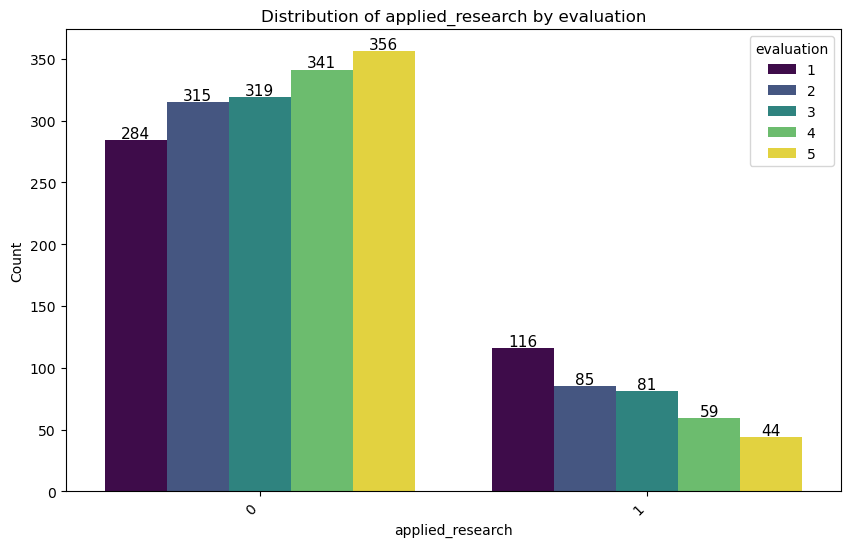

In [7]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='applied_research')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="applied_research")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='applied_research')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="applied_research")

Original P-value: 0.9467455187293435
Bootstrap Mean P-value: 0.5262361867184226
Relationship is significant in 55/1000 boostrap samples.
Cramér's V (Effect Size): 0.0012198968752529413
Effect Size: Weak association
No significant association between grammar and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_36308\2662959644.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


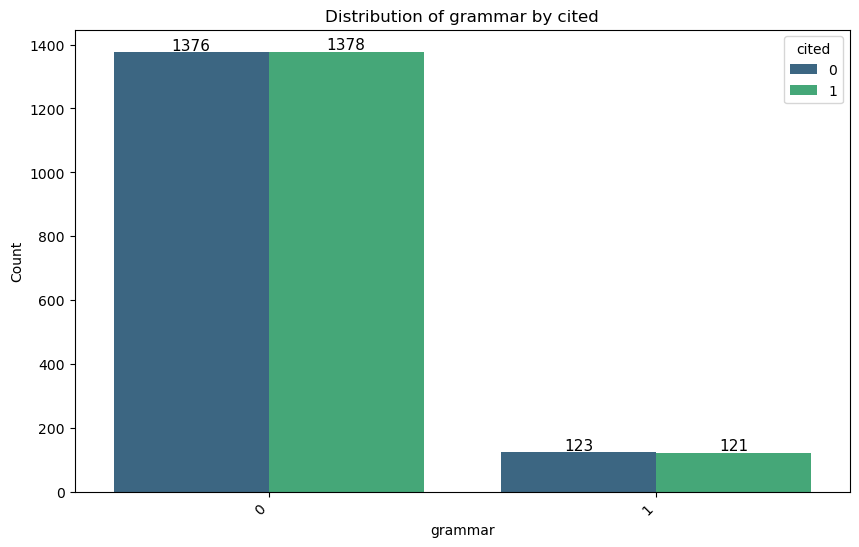

Original P-value: 4.686521172253479e-20
Bootstrap Mean P-value: 7.695050876293111e-12
Relationship is significant in 1000/1000 boostrap samples.
Cramér's V (Effect Size): 0.2200161484028683
Effect Size: Moderate association
Significant association between grammar and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_36308\2662959644.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


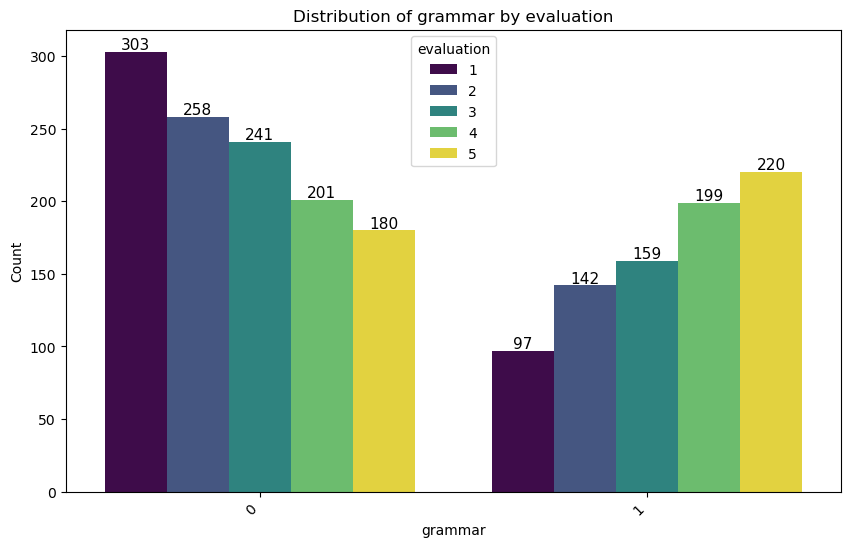

In [8]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='grammar')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="grammar")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable="grammar")
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="grammar")

In [9]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='rigor')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="rigor")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='rigor')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="rigor")


KeyboardInterrupt



Chi-Squared Value: 0.35347598253275114
Original P-value: 0.5521520254249233
Bootstrap Mean P-value: 0.46213803000342624
Relationship is significant in 91/1000.
Cramér's V (Effect Size): 0.01085835761664739
Effect Size: Weak association
No significant association between accessibility and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_22844\2889363776.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


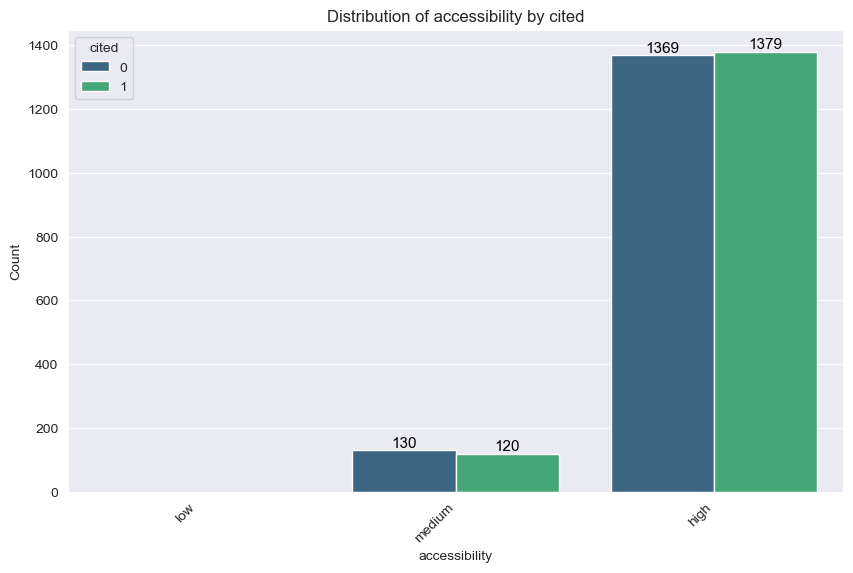

Chi-Squared Value: 12.046424759871933
Original P-value: 0.1491445134929061
Bootstrap Mean P-value: 0.0687309621366911
Relationship is significant in 691/1000.
Cramér's V (Effect Size): 0.0548781030099254
Effect Size: Weak association
No significant association between accessibility and evaluation.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_22844\2889363776.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


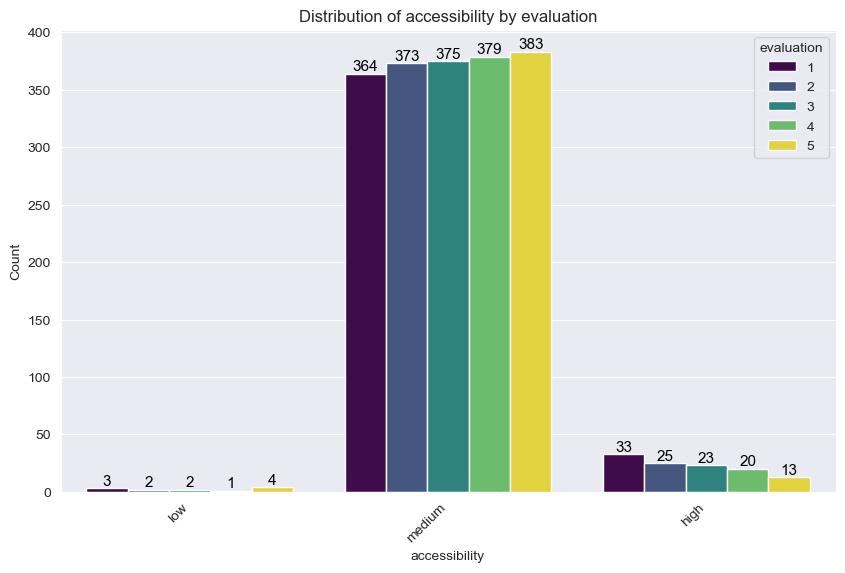

In [26]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='accessibility')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="accessibility")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='accessibility')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="accessibility")

In [27]:
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='accessibility')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="accessibility")


KeyboardInterrupt



In [17]:
df_c19['replicability'].value_counts()

replicability
1    1856
0    1142
Name: count, dtype: int64

Chi-Squared Value: 1.732701061356362
Original P-value: 0.1880663143327544
Bootstrap Mean P-value: 0.2908418001832606
Cramér's V (Effect Size): 0.024040638968216312
Effect Size: Weak association
No significant association between replicability and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


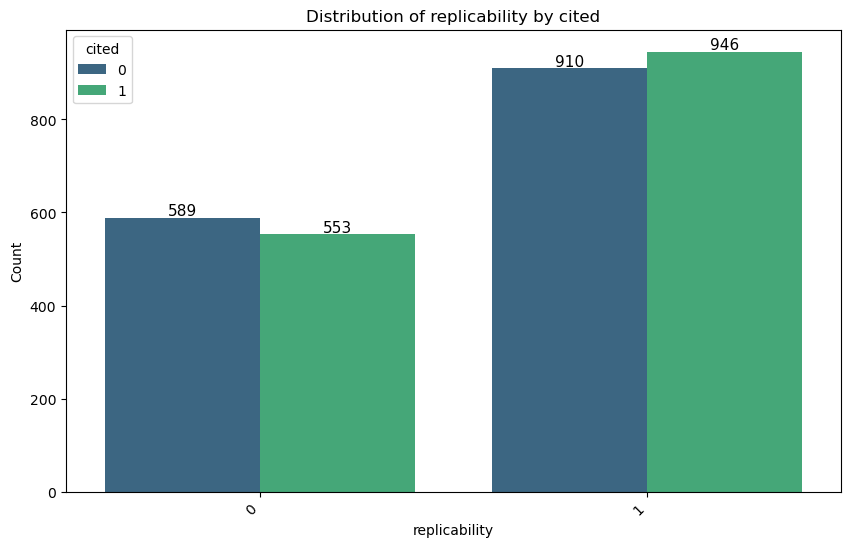

Chi-Squared Value: 207.7815894147755
Original P-value: 7.971471796954154e-44
Bootstrap Mean P-value: 1.1859860256861666e-28
Cramér's V (Effect Size): 0.32232094984252535
Effect Size: Strong association
Significant association between replicability and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


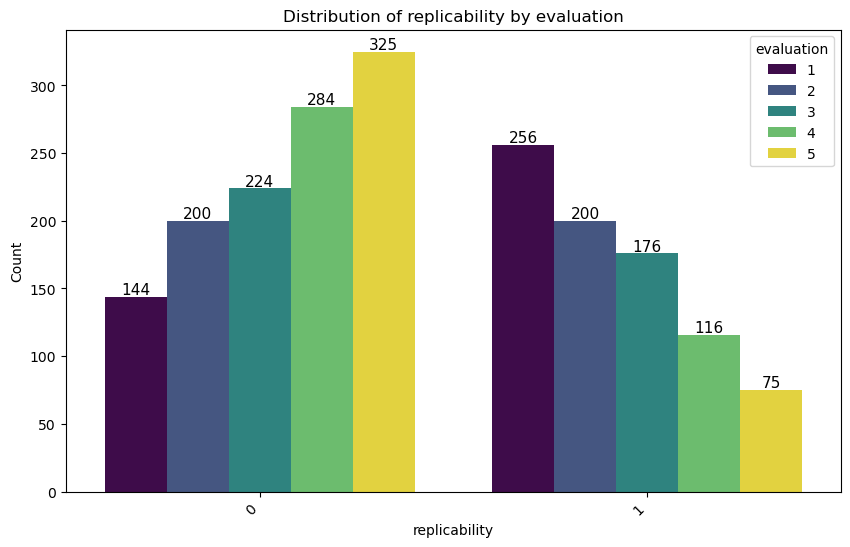

In [18]:
get_stat_significance(df_c19, target_variable='cited' ,categorical_variable='replicability')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="replicability")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='replicability')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="replicability")

In [19]:
# for col in df.columns:
#     get_stat_significance(col)

In [20]:
df_m17.head()

,title,abstract,science_field,collaborators,journal_name,evaluation,novelty,rigor,grammar,replicability,...,exploratory_research,focus_groups,interviews,mixed_methods,observation,qualitative_research,quantitative_research,questionnaires,secondary_research,survey_methodology
0,The making of a socialist underworld: people o...,This text depicts the mechanisms that created ...,60101.0,"Dušková, Lucie",European Review of History/Revue Europeenne d&...,1,medium,high,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Selective Translation Complex Profiling Reveal...,Translational control targeting the initiation...,10608.0,"Wagner, Susan:Herrmannová, Anna:Hronová, Vladi...",Molecular Cell,1,high,high,0,1,...,0,0,0,1,0,0,0,0,0,0
2,Layered Black Phosphorus: Strongly Anisotropic...,"Layered elemental materials, such as black pho...",0.0,"Sofer, Zdeněk:Sedmidubský, David:Huber, Štěpán...",Angewandte Chemie-International Edition,1,high,high,1,1,...,0,0,0,0,0,0,0,0,0,0
3,Geochemical Modelling of Igneous Processes - P...,The aim of this book is to unlock the power of...,0.0,"Janoušek, Vojtěch: Moyen, Jean-Francois: Marti...",Geochemical Modelling of Igneous Processes - P...,1,medium,medium,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Plant diversity increases with the strength of...,Theory predicts that higher biodiversity in th...,40102.0,"Janík, David:Král, Kamil:Vrška, Tomáš",Science,1,high,high,0,1,...,1,0,0,1,0,1,1,0,0,0


now in rigor
Chi-Squared Value: 31.263529091710335
Original P-value: 1.6263383960153328e-07
Bootstrap Mean P-value: 0.00019186694124845793
Cramér's V (Effect Size): 0.1021182082174206
Effect Size: Moderate association
Significant association between rigor and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


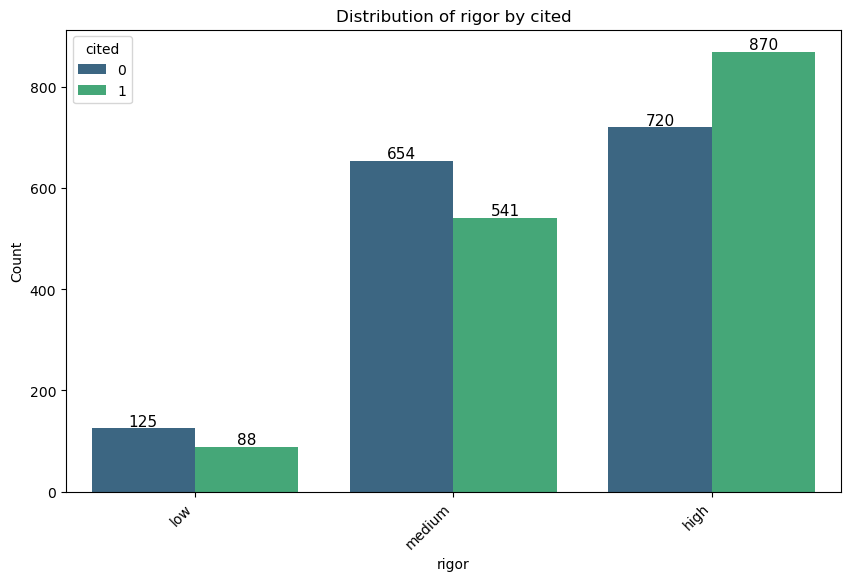

now in novelty
Chi-Squared Value: 14.120297099124466
Original P-value: 0.0008586505323392688
Bootstrap Mean P-value: 0.014152319720429414
Cramér's V (Effect Size): 0.06862875226025426
Effect Size: Weak association
Significant association between novelty and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


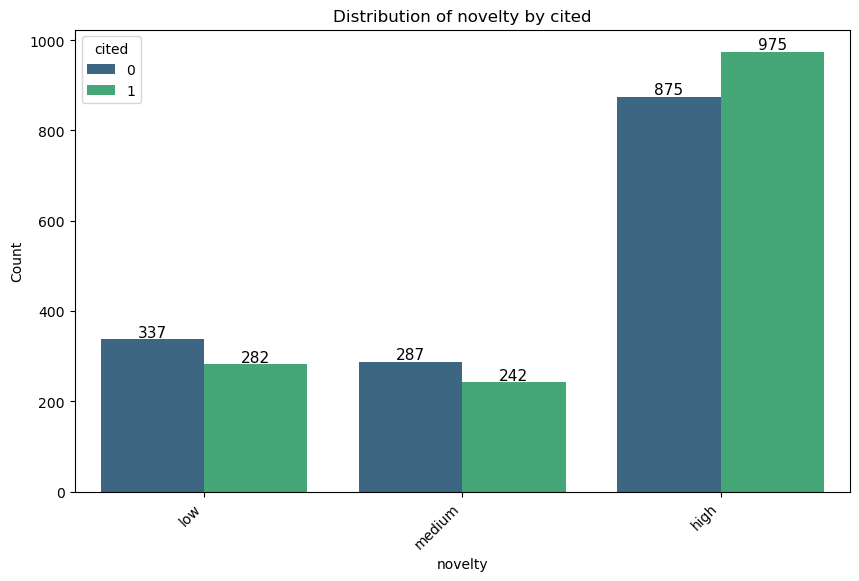

now in grammar
Chi-Squared Value: 0.004461468861983167
Original P-value: 0.9467455187293435
Bootstrap Mean P-value: 0.5316197134177434
Cramér's V (Effect Size): 0.0012198968752529413
Effect Size: Weak association
No significant association between grammar and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


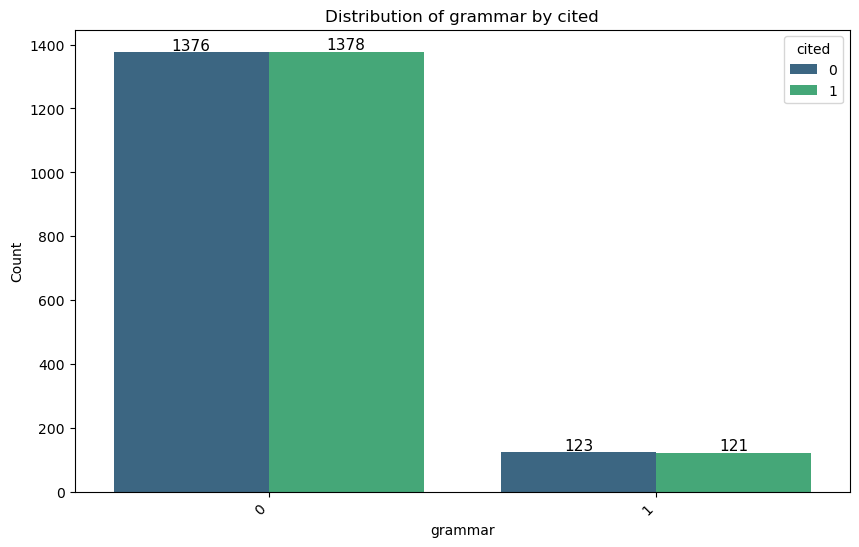

now in replicability
Chi-Squared Value: 1.732701061356362
Original P-value: 0.1880663143327544
Bootstrap Mean P-value: 0.29724642110726013
Cramér's V (Effect Size): 0.024040638968216312
Effect Size: Weak association
No significant association between replicability and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


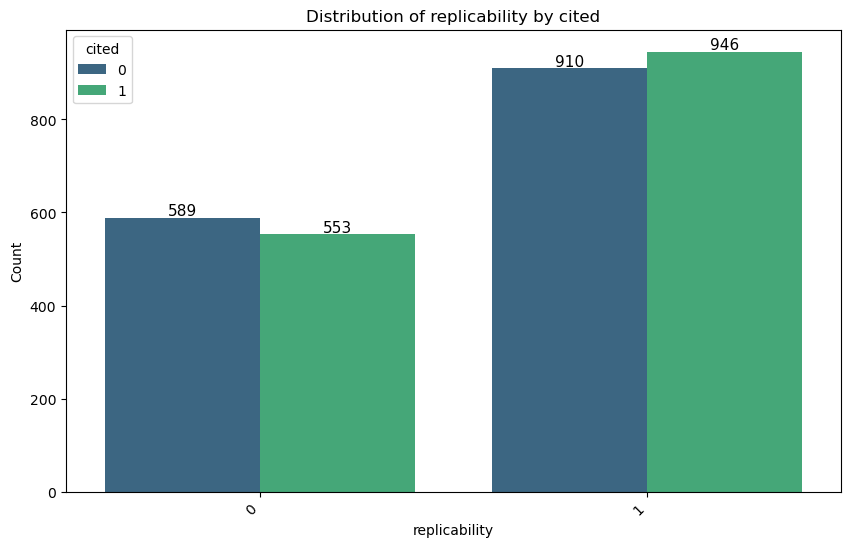

now in accessibility
Chi-Squared Value: 0.35347598253275114
Original P-value: 0.5521520254249233
Bootstrap Mean P-value: 0.47474897466701177
Cramér's V (Effect Size): 0.01085835761664739
Effect Size: Weak association
No significant association between accessibility and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


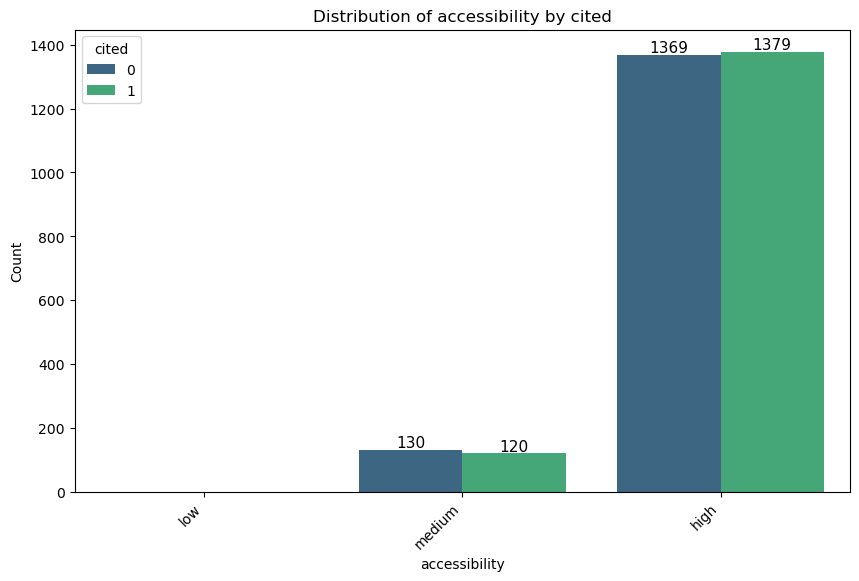

now in mathematics
Chi-Squared Value: 7.728430134680135
Original P-value: 0.005435799120309172
Bootstrap Mean P-value: 0.046023356163138955
Cramér's V (Effect Size): 0.0507726496537452
Effect Size: Weak association
Significant association between mathematics and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


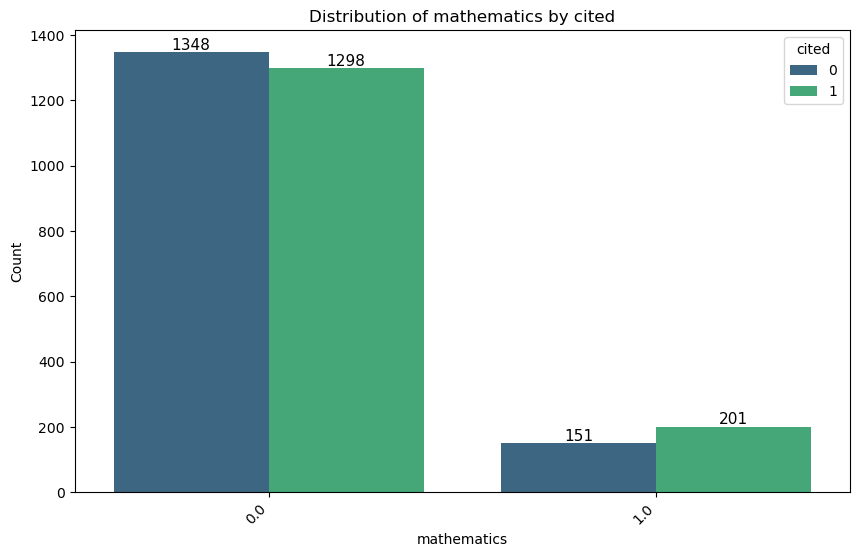

now in computer_sciences
Chi-Squared Value: 20.84991311748012
Original P-value: 4.967147887614575e-06
Bootstrap Mean P-value: 0.001170863275687772
Cramér's V (Effect Size): 0.08339428903781594
Effect Size: Weak association
Significant association between computer_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


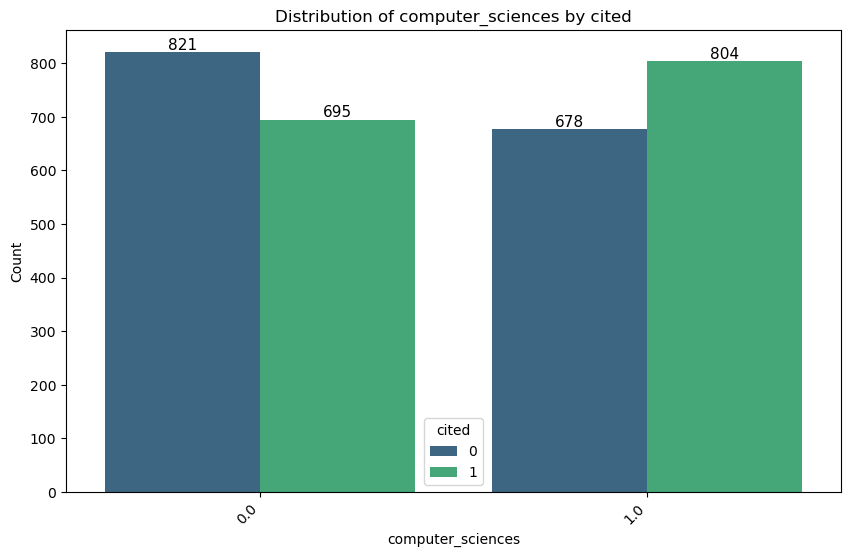

now in physical_sciences
Chi-Squared Value: 46.78514756456424
Original P-value: 7.921146558572942e-12
Bootstrap Mean P-value: 6.382339596895617e-07
Cramér's V (Effect Size): 0.1249217868244114
Effect Size: Moderate association
Significant association between physical_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


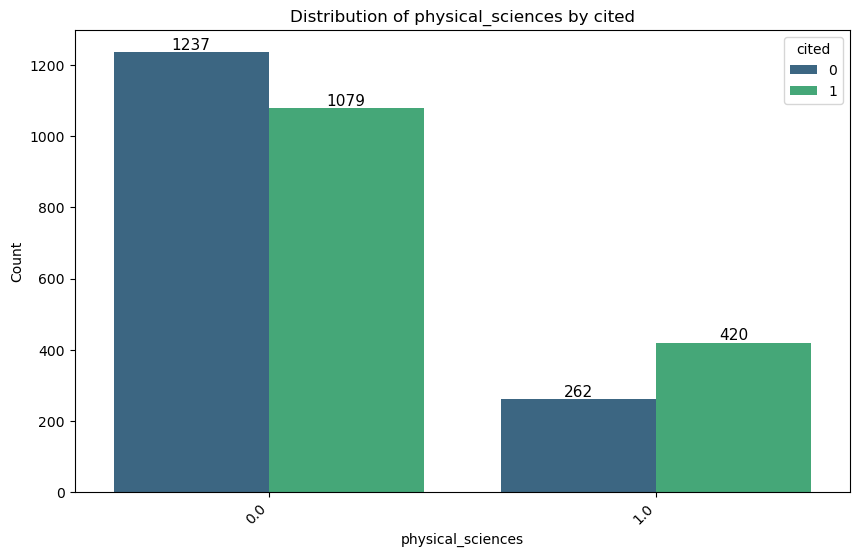

now in chemical_sciences
Chi-Squared Value: 59.82944174969782
Original P-value: 1.0344426359606074e-14
Bootstrap Mean P-value: 8.029981731668433e-09
Cramér's V (Effect Size): 0.1412673053149002
Effect Size: Moderate association
Significant association between chemical_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


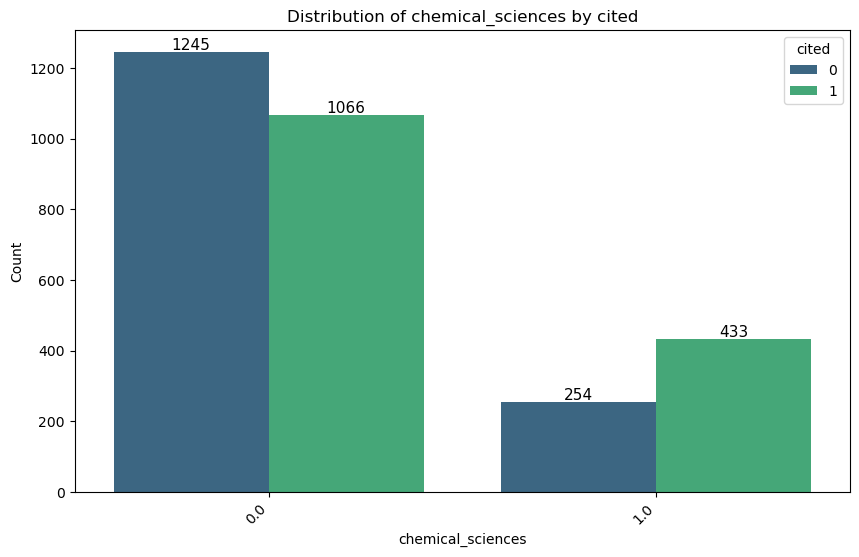

now in earth_and_related_sciences
Chi-Squared Value: 29.777345980044927
Original P-value: 4.846219278452379e-08
Bootstrap Mean P-value: 0.0001333296009817981
Cramér's V (Effect Size): 0.09966144488088396
Effect Size: Weak association
Significant association between earth_and_related_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


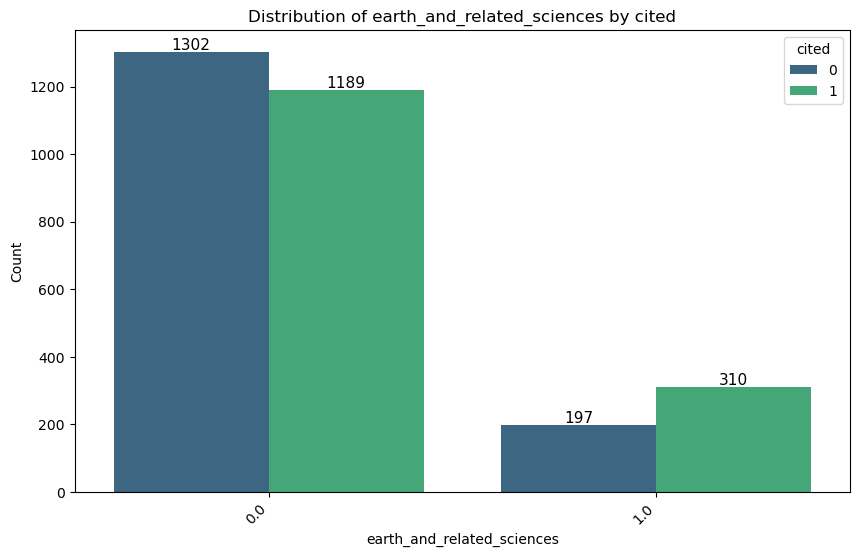

now in biological_sciences
Chi-Squared Value: 62.78159228387263
Original P-value: 2.3094724156967886e-15
Bootstrap Mean P-value: 2.0793016100418113e-08
Cramér's V (Effect Size): 0.14471060154698734
Effect Size: Moderate association
Significant association between biological_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


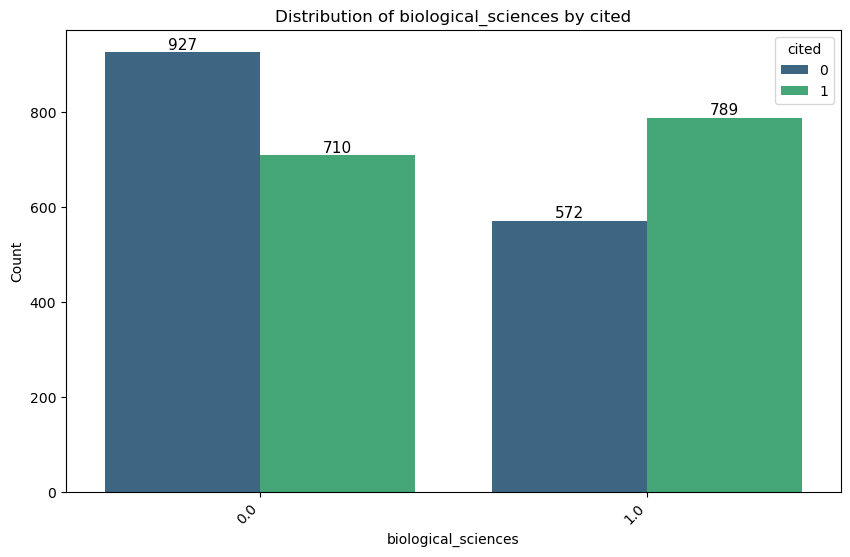

now in other_natural_sciences
Chi-Squared Value: 31.50323165238871
Original P-value: 1.9910860856943468e-08
Bootstrap Mean P-value: 3.556300427412551e-05
Cramér's V (Effect Size): 0.10250893915101655
Effect Size: Moderate association
Significant association between other_natural_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


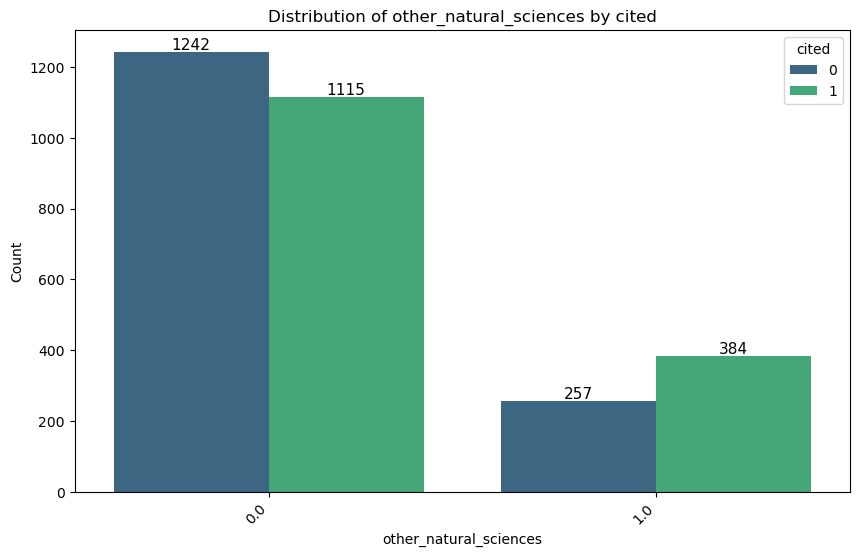

now in civil_engineering
Chi-Squared Value: 5.384970674486803
Original P-value: 0.020310929535942168
Bootstrap Mean P-value: 0.10414153448166164
Cramér's V (Effect Size): 0.04238145447344224
Effect Size: Weak association
Significant association between civil_engineering and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


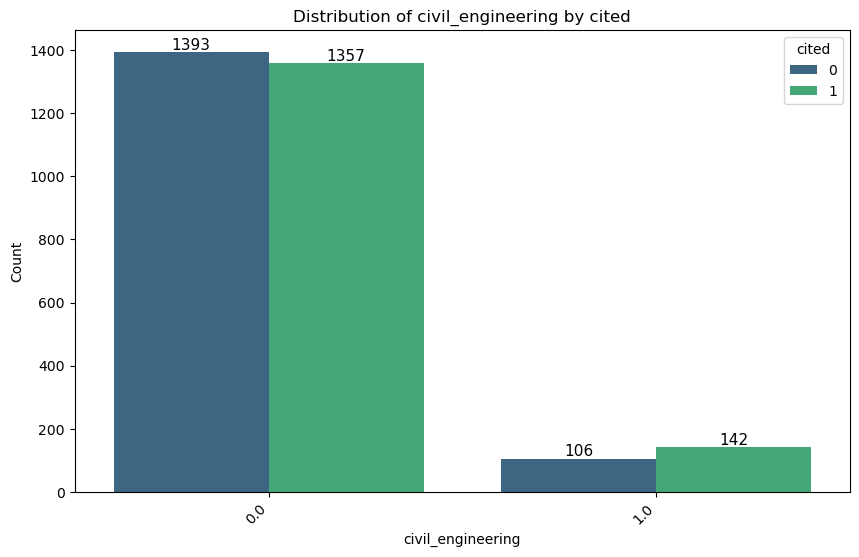

now in electrical_engineering
Chi-Squared Value: 3.798470934765659
Original P-value: 0.05129940965875685
Bootstrap Mean P-value: 0.15959806730754103
Cramér's V (Effect Size): 0.03559496658263964
Effect Size: Weak association
No significant association between electrical_engineering and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


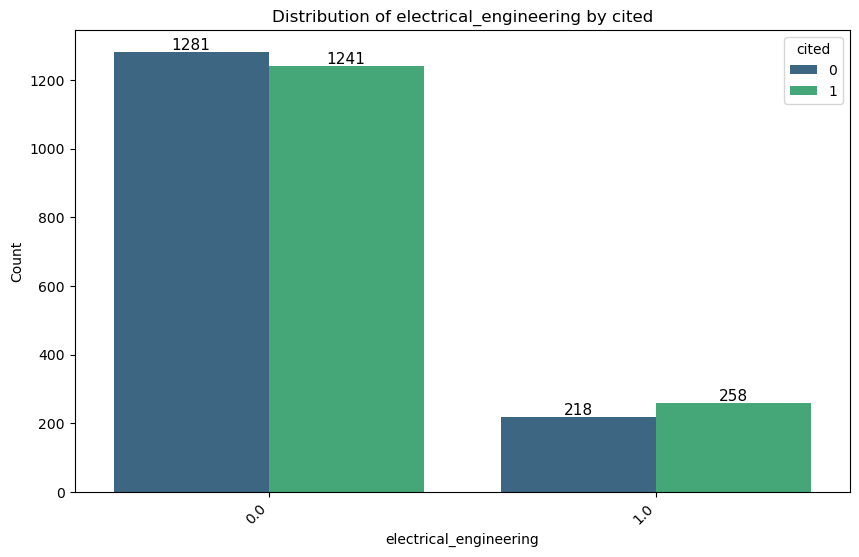

now in mechanical_engineering
Chi-Squared Value: 20.384647259138717
Original P-value: 6.333588441014675e-06
Bootstrap Mean P-value: 0.001153782086335088
Cramér's V (Effect Size): 0.08245856755539979
Effect Size: Weak association
Significant association between mechanical_engineering and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


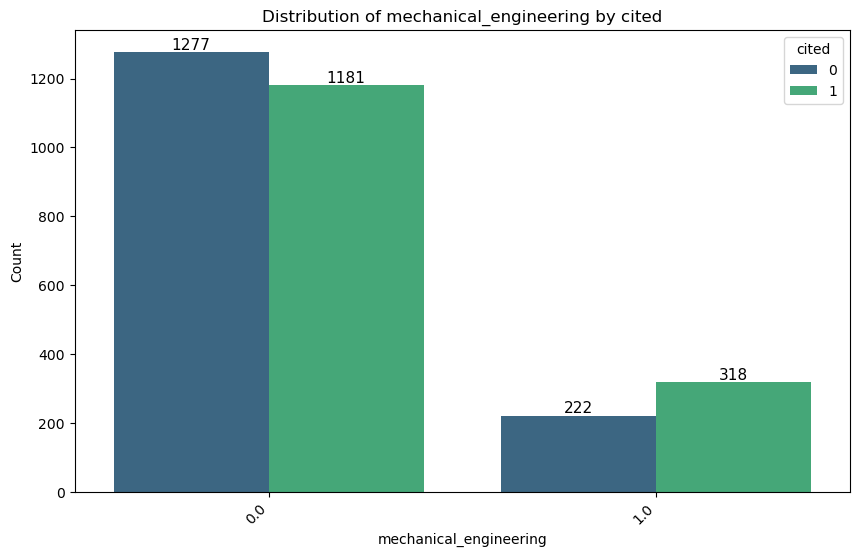

now in chemical_engineering
Chi-Squared Value: 32.94738157322903
Original P-value: 9.468718878426198e-09
Bootstrap Mean P-value: 7.505041953923665e-05
Cramér's V (Effect Size): 0.10483218517759268
Effect Size: Moderate association
Significant association between chemical_engineering and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


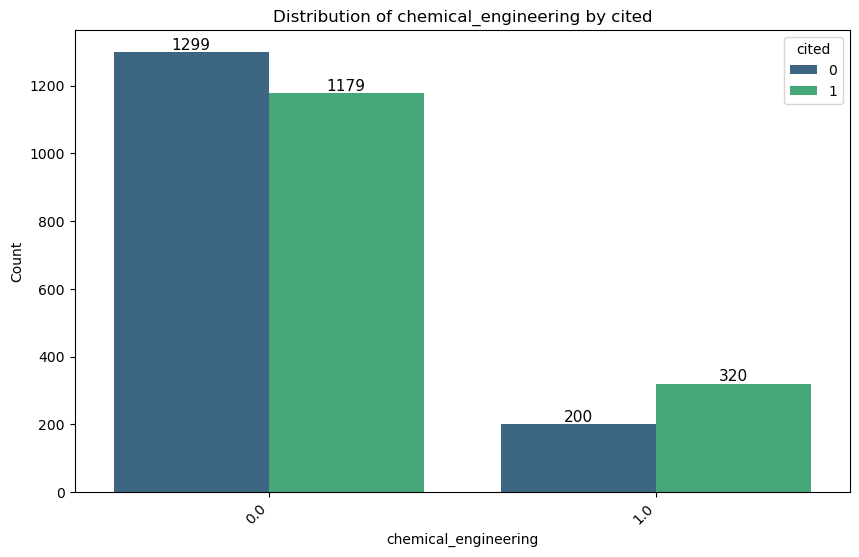

now in materials_engineering
Chi-Squared Value: 6.551389367761049
Original P-value: 0.010480229018045831
Bootstrap Mean P-value: 0.06033808500355062
Cramér's V (Effect Size): 0.046746692839686334
Effect Size: Weak association
Significant association between materials_engineering and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


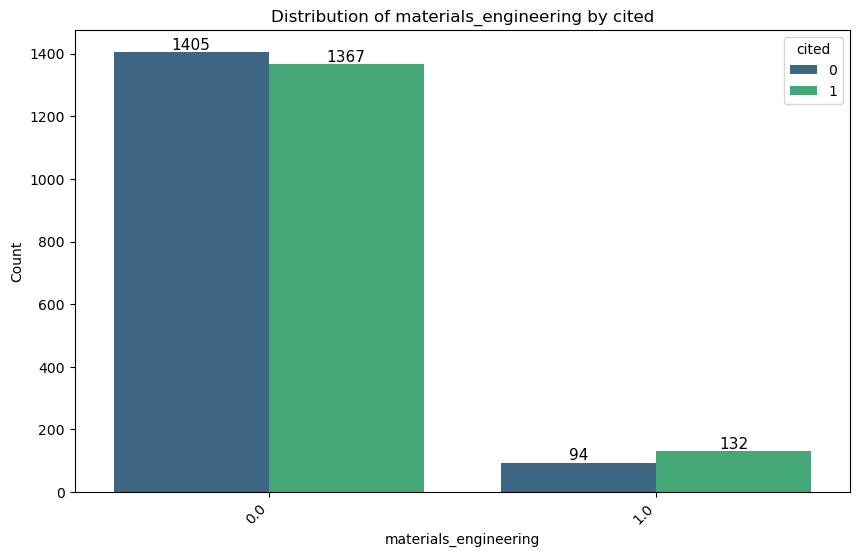

now in environmental_engineering
Chi-Squared Value: 8.102899344872469
Original P-value: 0.004419450943697625
Bootstrap Mean P-value: 0.04439509083262032
Cramér's V (Effect Size): 0.051988155322342765
Effect Size: Weak association
Significant association between environmental_engineering and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


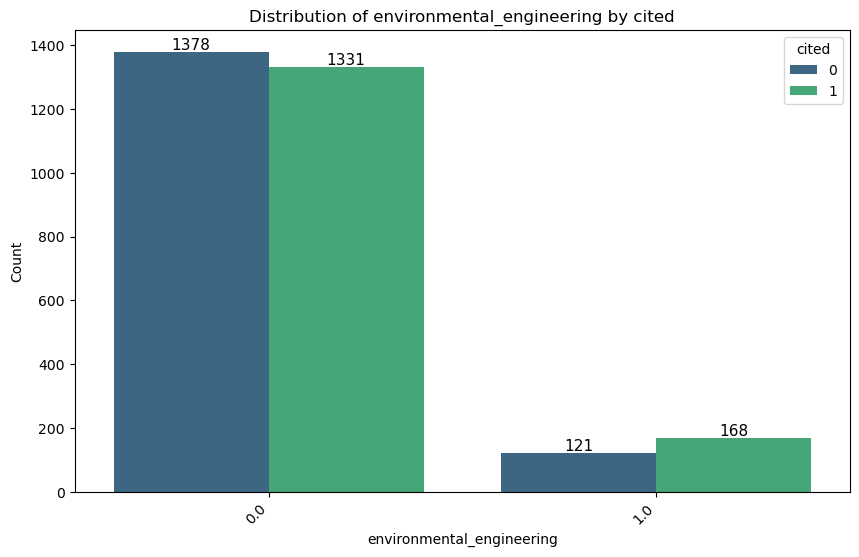

now in evironmental_biotechnology
Chi-Squared Value: 25.112479056269272
Original P-value: 5.408174178301265e-07
Bootstrap Mean P-value: 0.00018096206604617144
Cramér's V (Effect Size): 0.09152273283638507
Effect Size: Weak association
Significant association between evironmental_biotechnology and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


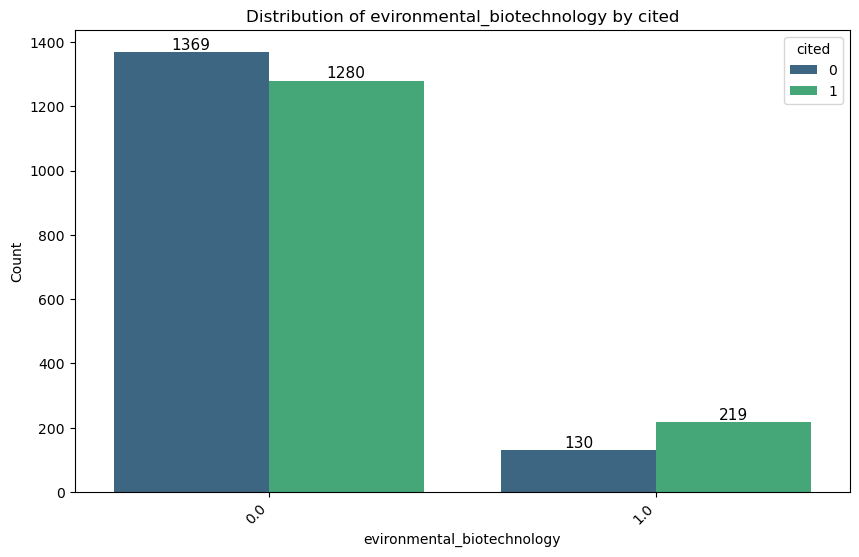

now in industrial_biotechnology
Chi-Squared Value: 33.197081692996534
Original P-value: 8.327541718460591e-09
Bootstrap Mean P-value: 2.9599704394873646e-05
Cramér's V (Effect Size): 0.10522868405666636
Effect Size: Moderate association
Significant association between industrial_biotechnology and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


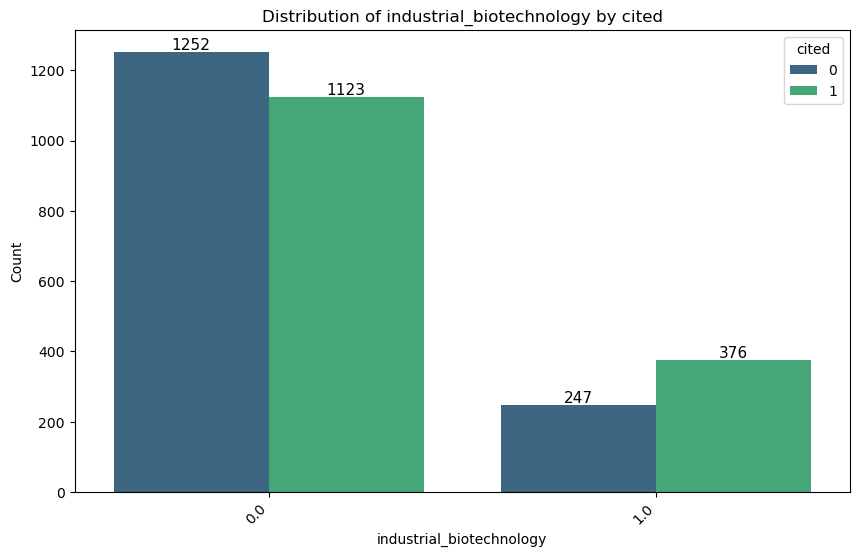

now in nano-technology
Chi-Squared Value: 6.493591489859529
Original P-value: 0.010826403654746542
Bootstrap Mean P-value: 0.06616924466606823
Cramér's V (Effect Size): 0.04654003093688537
Effect Size: Weak association
Significant association between nano-technology and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


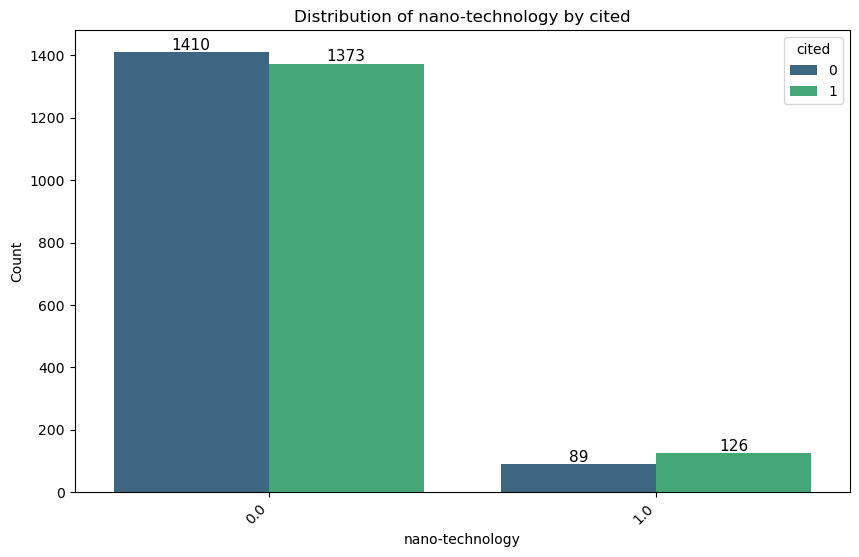

now in other_engineering_and_technologies
Chi-Squared Value: 3.0501733046172923
Original P-value: 0.08072852808452795
Bootstrap Mean P-value: 0.1971071483834814
Cramér's V (Effect Size): 0.03189675067058281
Effect Size: Weak association
No significant association between other_engineering_and_technologies and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


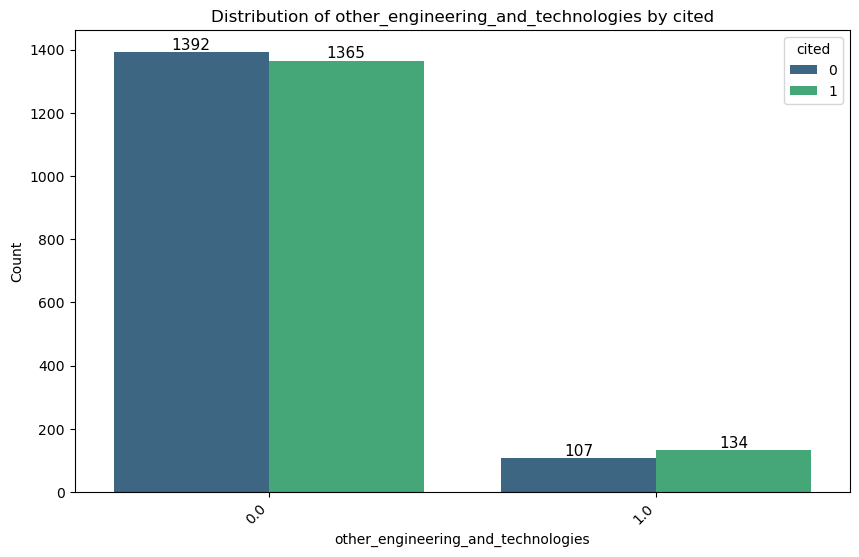

now in basic_medicine
Chi-Squared Value: 71.17841884385182
Original P-value: 3.2633819696507715e-17
Bootstrap Mean P-value: 8.096477110430999e-11
Cramér's V (Effect Size): 0.1540842873008556
Effect Size: Moderate association
Significant association between basic_medicine and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


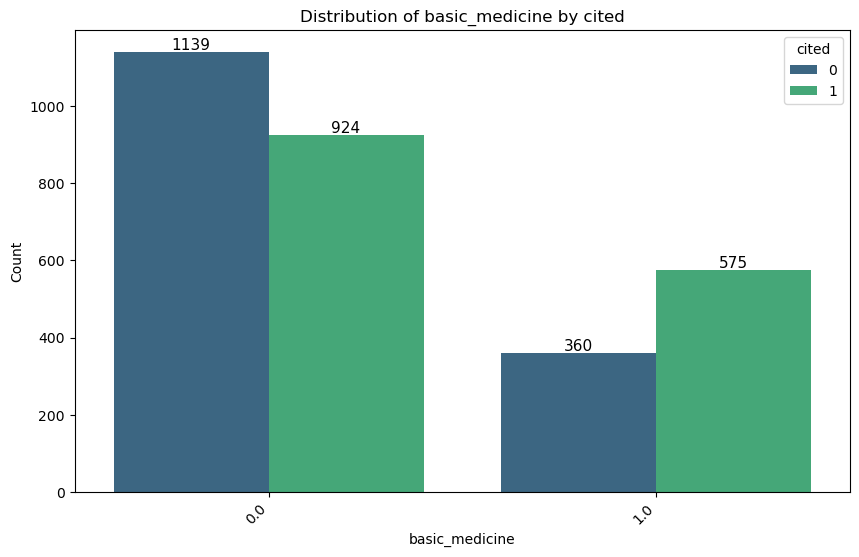

now in clinical_medicine
Chi-Squared Value: 16.386800407035906
Original P-value: 5.1643619203403903e-05
Bootstrap Mean P-value: 0.004156826223110325
Cramér's V (Effect Size): 0.07393179791429753
Effect Size: Weak association
Significant association between clinical_medicine and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


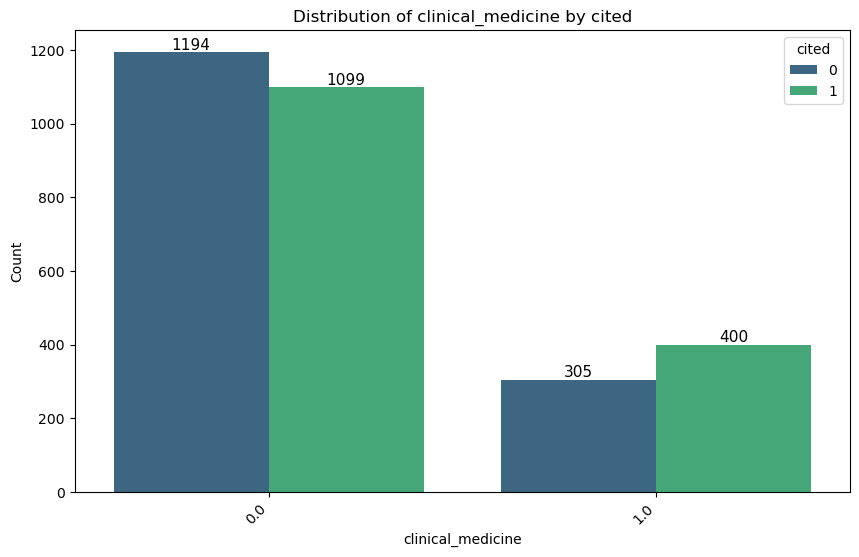

now in health_sciences
Chi-Squared Value: 8.449239435737798
Original P-value: 0.0036519613227176777
Bootstrap Mean P-value: 0.04088212445096335
Cramér's V (Effect Size): 0.053087588065230985
Effect Size: Weak association
Significant association between health_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


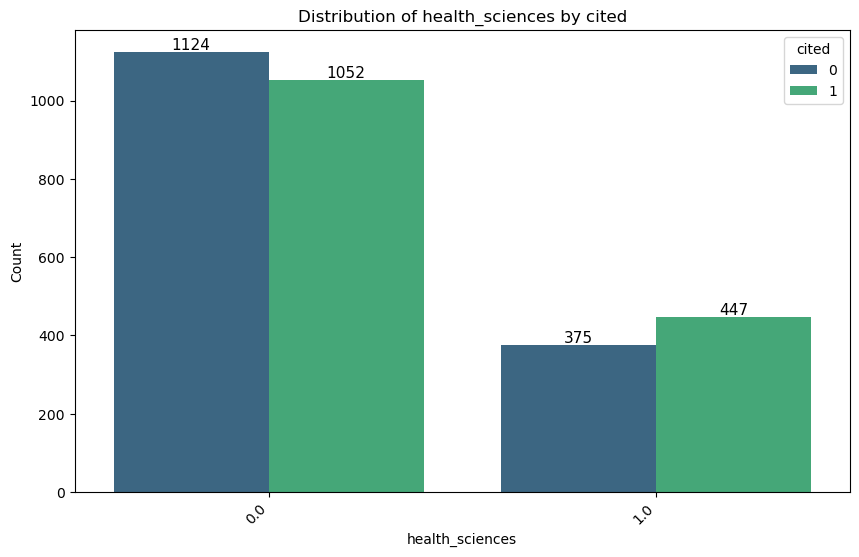

now in medical_biotechnology
Chi-Squared Value: 23.556488262410088
Original P-value: 1.212997020405208e-06
Bootstrap Mean P-value: 0.0004214794462249571
Cramér's V (Effect Size): 0.08864198227411407
Effect Size: Weak association
Significant association between medical_biotechnology and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


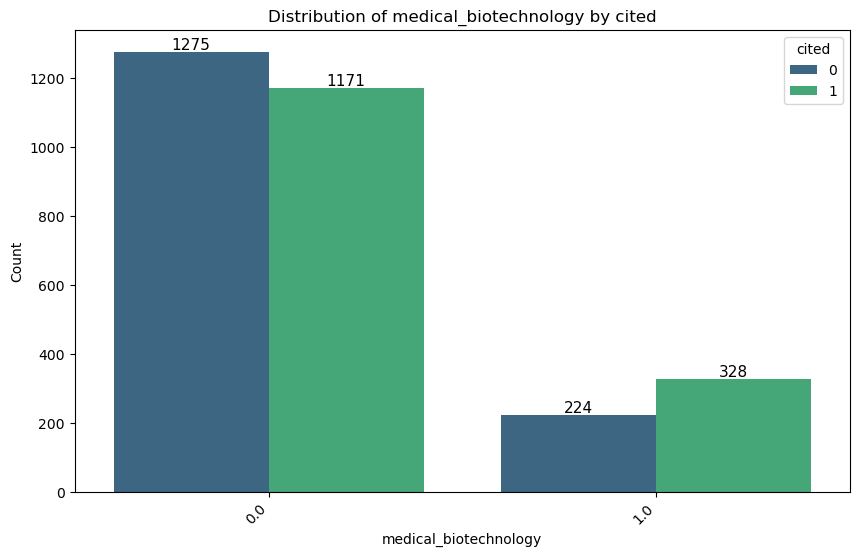

now in other_medical_sciences
Chi-Squared Value: 23.97648473695145
Original P-value: 9.751951295315822e-07
Bootstrap Mean P-value: 0.000334872573849748
Cramér's V (Effect Size): 0.0894287047940681
Effect Size: Weak association
Significant association between other_medical_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


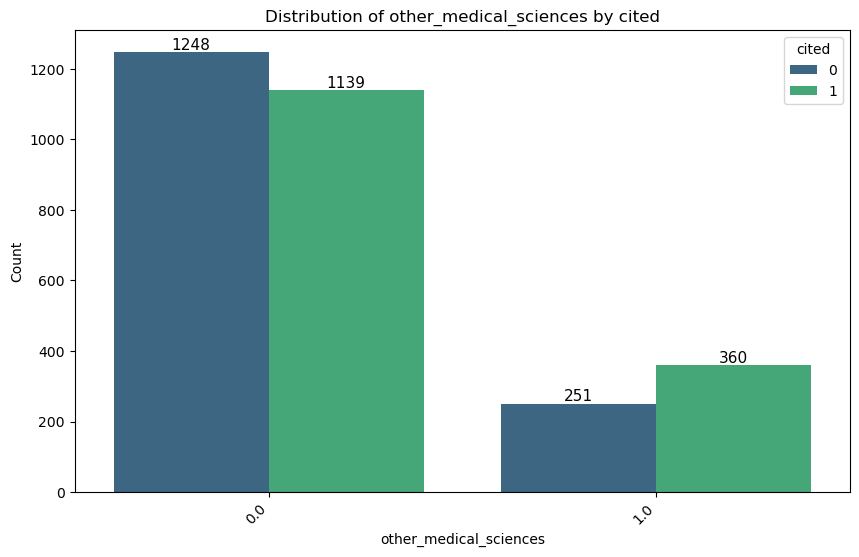

now in agriculture_forestry_and_fisheries
Chi-Squared Value: 33.90726570474738
Original P-value: 5.78024357540128e-09
Bootstrap Mean P-value: 1.9879772584637864e-05
Cramér's V (Effect Size): 0.10634830452887611
Effect Size: Moderate association
Significant association between agriculture_forestry_and_fisheries and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


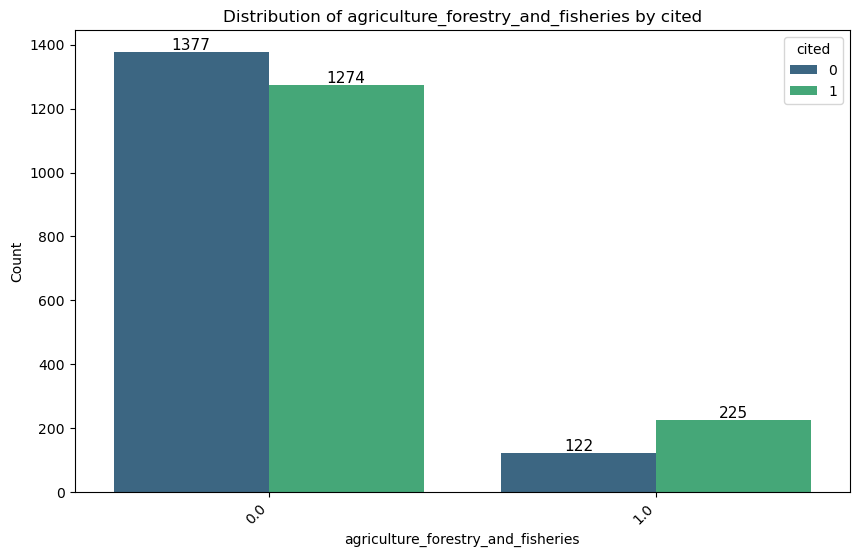

now in animal_and_dairy_science
Chi-Squared Value: 43.38974106838451
Original P-value: 4.485335395623643e-11
Bootstrap Mean P-value: 1.1832844140280941e-06
Cramér's V (Effect Size): 0.12030334833193444
Effect Size: Moderate association
Significant association between animal_and_dairy_science and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


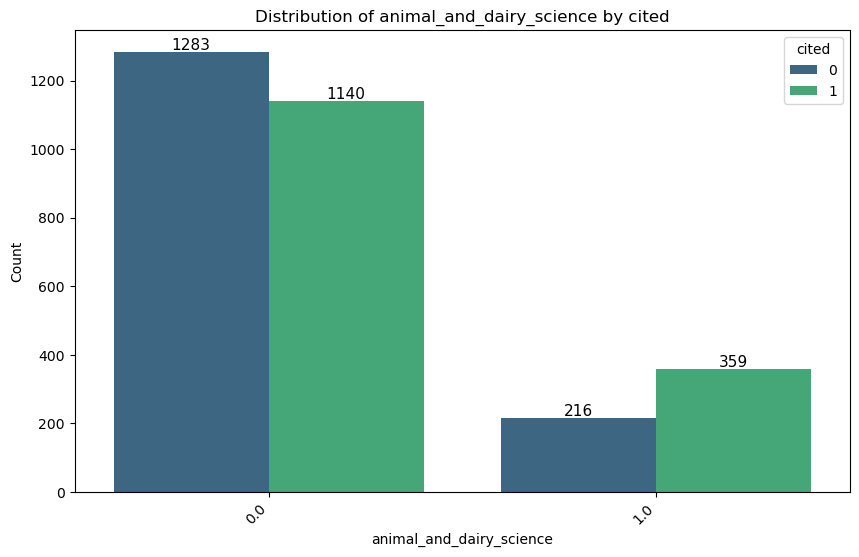

now in veterinary_science
Chi-Squared Value: 51.18677480381166
Original P-value: 8.398252997817666e-13
Bootstrap Mean P-value: 2.061293784534848e-07
Cramér's V (Effect Size): 0.1306661421144256
Effect Size: Moderate association
Significant association between veterinary_science and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


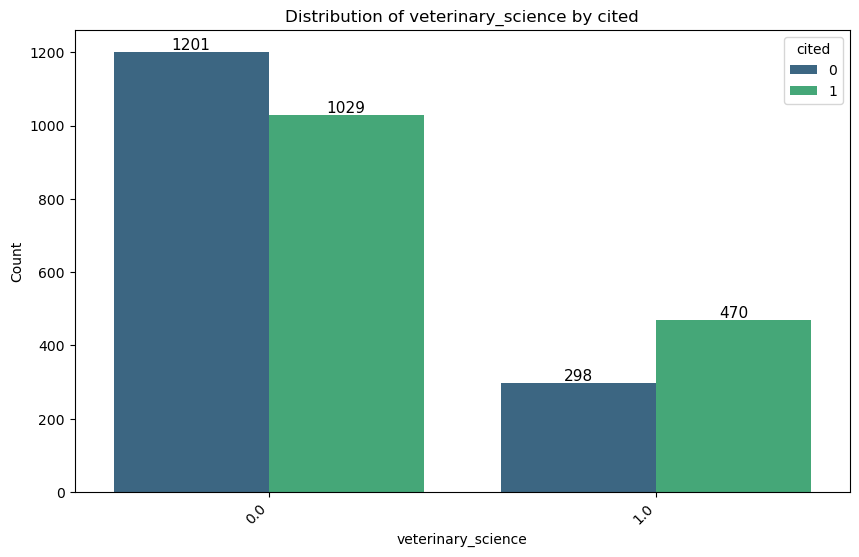

now in agricultural_biotechnology
Chi-Squared Value: 8.596793071161049
Original P-value: 0.0033675548168735758
Bootstrap Mean P-value: 0.036787180162546125
Cramér's V (Effect Size): 0.05354913036918415
Effect Size: Weak association
Significant association between agricultural_biotechnology and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


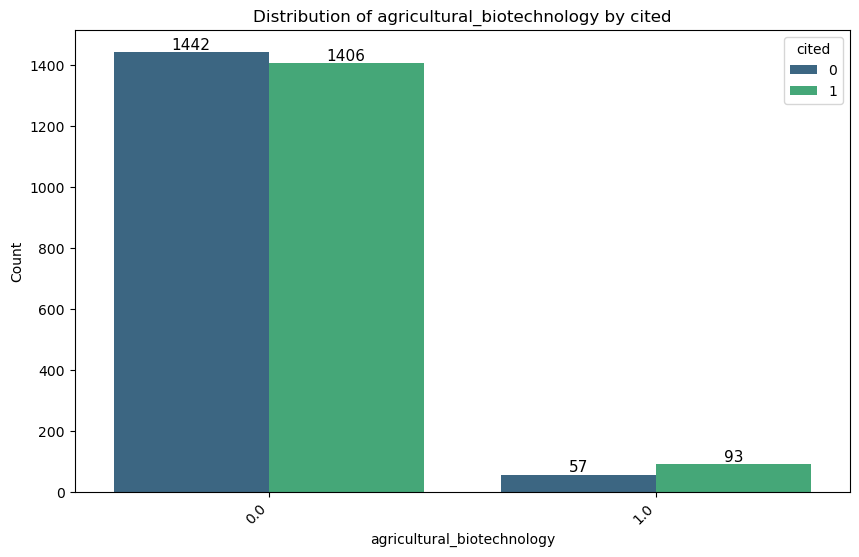

now in other_agricultural_sciences
Chi-Squared Value: 12.39537204089443
Original P-value: 0.00043039923263464764
Bootstrap Mean P-value: 0.012062803822995362
Cramér's V (Effect Size): 0.0643004435831885
Effect Size: Weak association
Significant association between other_agricultural_sciences and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


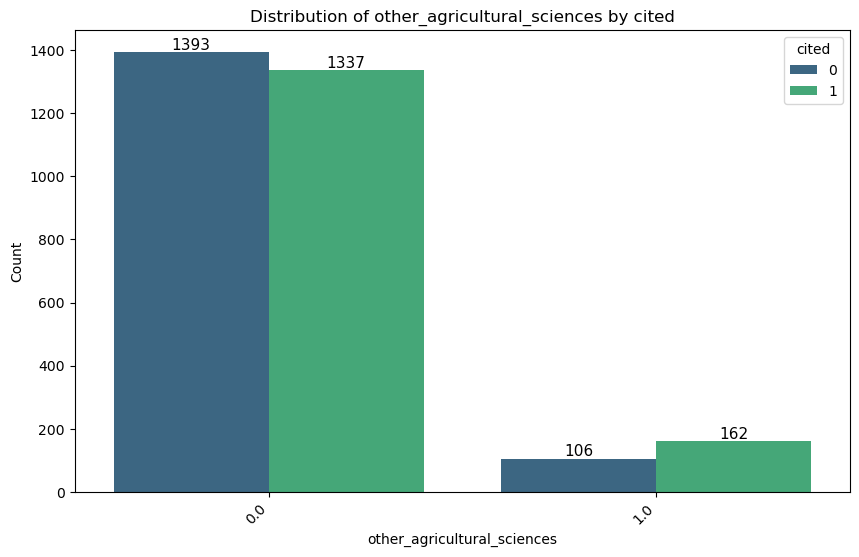

now in psychology
Chi-Squared Value: 9.677048280259289
Original P-value: 0.0018658414291885578
Bootstrap Mean P-value: 0.027037152477786926
Cramér's V (Effect Size): 0.05681403567652098
Effect Size: Weak association
Significant association between psychology and cited.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


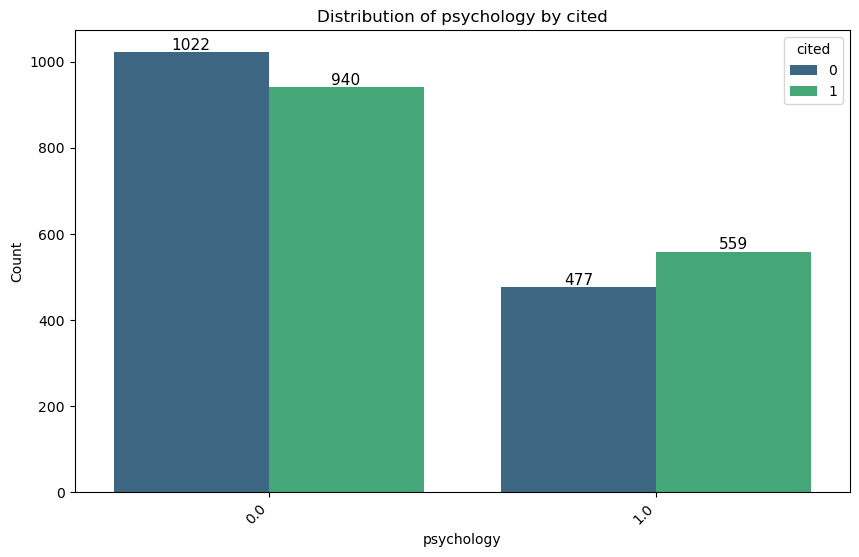

now in economics_and_business
Chi-Squared Value: 0.0025679240757871657
Original P-value: 0.9595847462123431
Bootstrap Mean P-value: 0.5217502472418054
Cramér's V (Effect Size): 0.0009254975539733546
Effect Size: Weak association
No significant association between economics_and_business and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


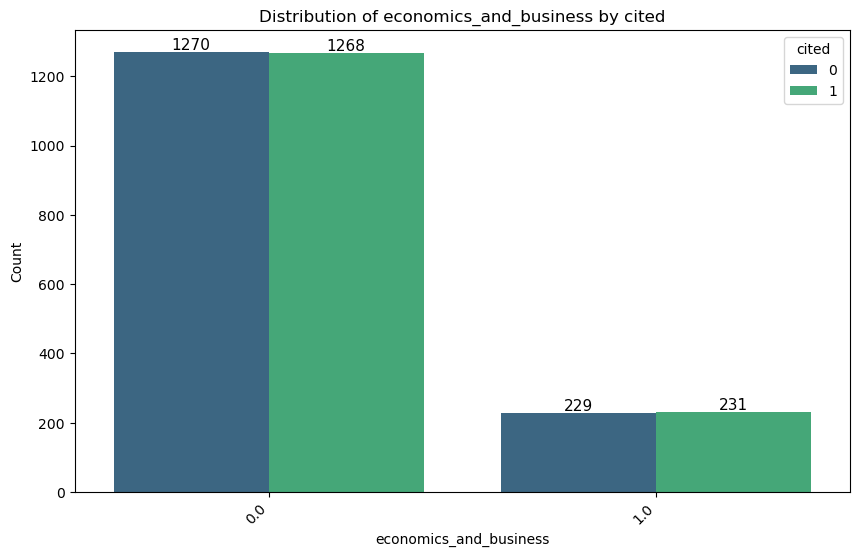

now in education
Chi-Squared Value: 2.430864884103751
Original P-value: 0.11896724395481026
Bootstrap Mean P-value: 0.25961963563085616
Cramér's V (Effect Size): 0.028475056580560015
Effect Size: Weak association
No significant association between education and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


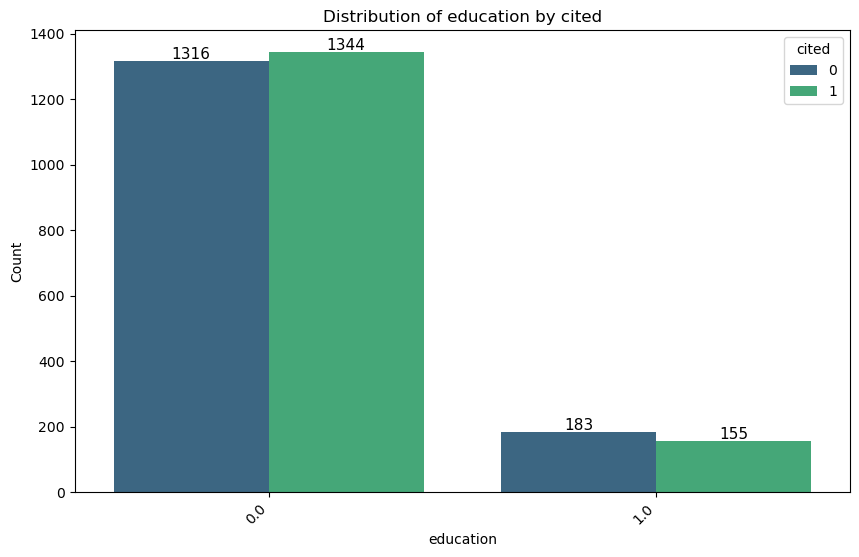

now in sociology
Chi-Squared Value: 0.007696548554939635
Original P-value: 0.930091294677
Bootstrap Mean P-value: 0.5199188982642236
Cramér's V (Effect Size): 0.0016022570549363401
Effect Size: Weak association
No significant association between sociology and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


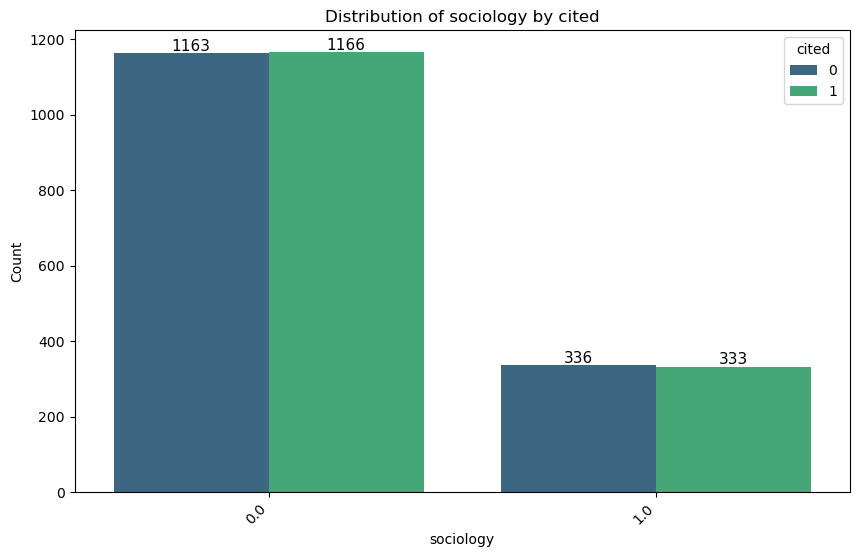

now in law
Chi-Squared Value: 6.010954239861201
Original P-value: 0.014217337004710687
Bootstrap Mean P-value: 0.0765736147725383
Cramér's V (Effect Size): 0.04477709316159028
Effect Size: Weak association
Significant association between law and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


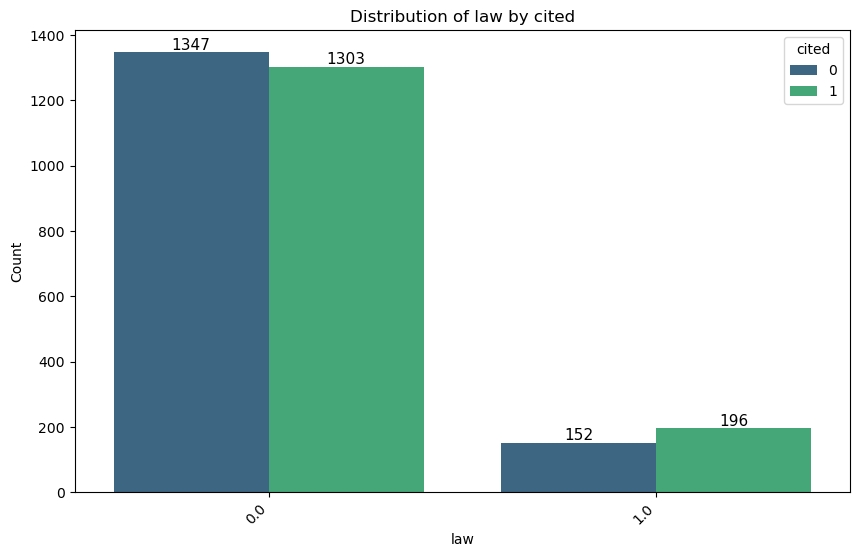

now in political_science
Chi-Squared Value: 0.44120871762494906
Original P-value: 0.5065396350949756
Bootstrap Mean P-value: 0.447331231881535
Cramér's V (Effect Size): 0.012131268867319848
Effect Size: Weak association
No significant association between political_science and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


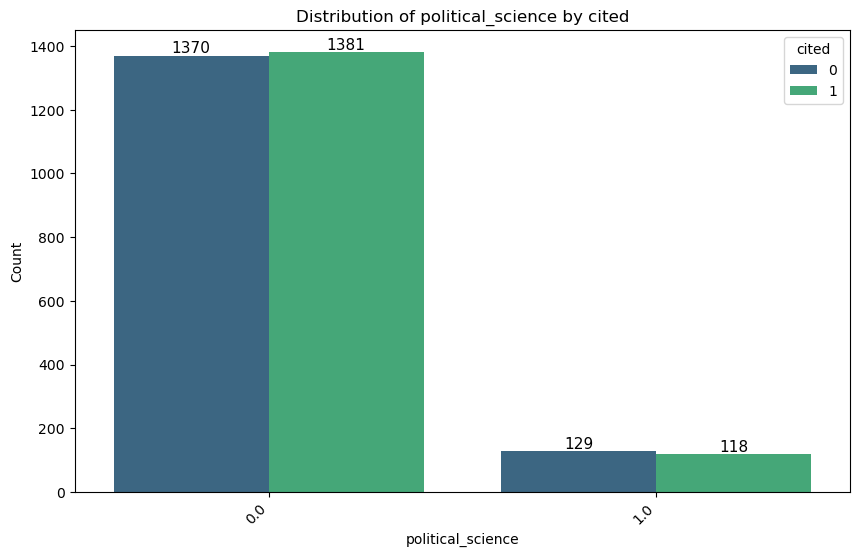

now in social_and_economic_geography
Chi-Squared Value: 0.17733786175178812
Original P-value: 0.6736710927369942
Bootstrap Mean P-value: 0.504807654273308
Cramér's V (Effect Size): 0.007691037334940869
Effect Size: Weak association
No significant association between social_and_economic_geography and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


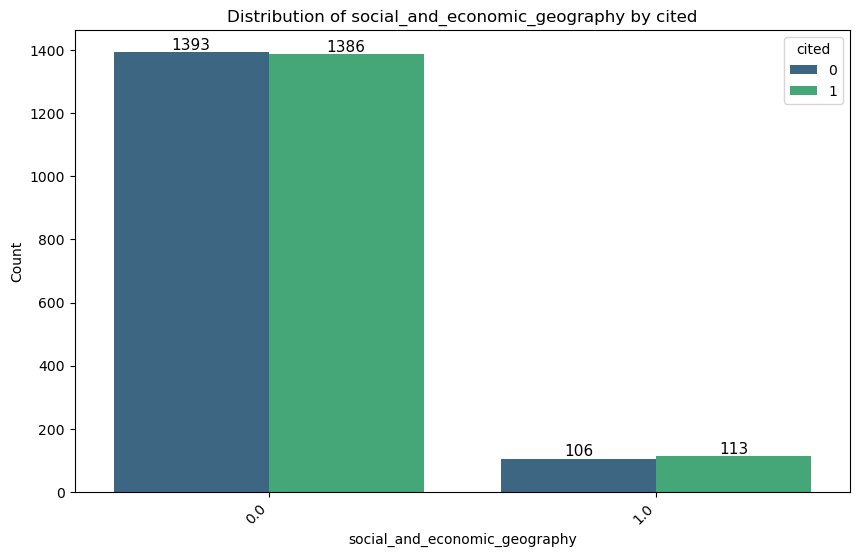

now in media_and_communications
Chi-Squared Value: 0.9792074016139927
Original P-value: 0.32239456429700736
Bootstrap Mean P-value: 0.40236643421974333
Cramér's V (Effect Size): 0.01807263716268345
Effect Size: Weak association
No significant association between media_and_communications and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


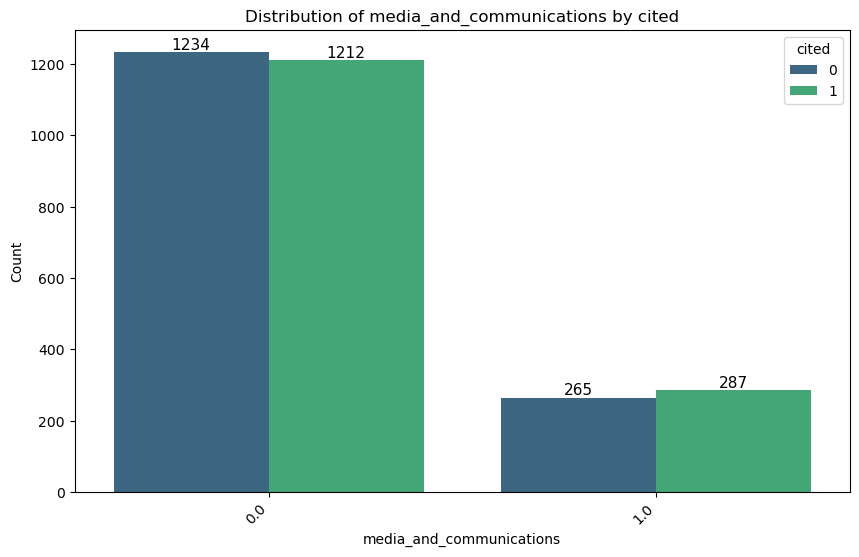

now in other_social_sciences
Chi-Squared Value: 2.0698562492020938
Original P-value: 0.15023568127802642
Bootstrap Mean P-value: 0.2770765166828594
Cramér's V (Effect Size): 0.02627569900064848
Effect Size: Weak association
No significant association between other_social_sciences and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


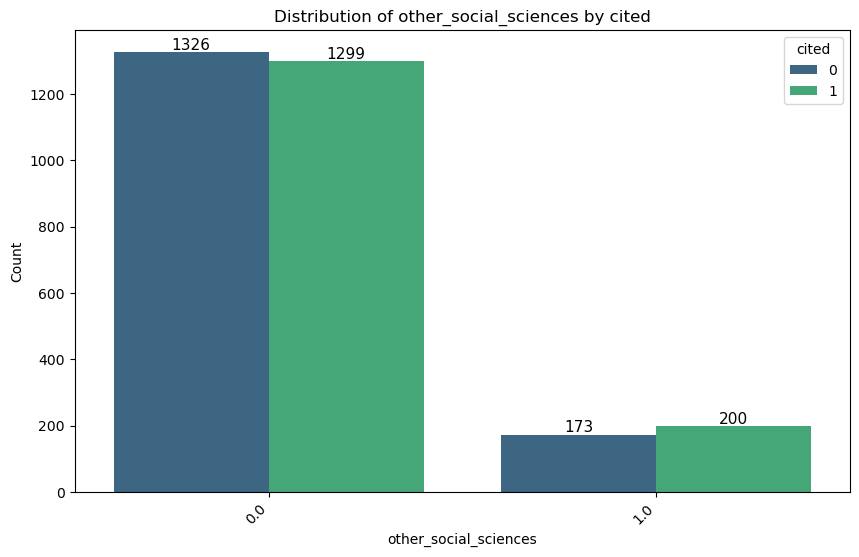

now in history_and_archaeology
Chi-Squared Value: 2.9373078760119036
Original P-value: 0.08655488155503387
Bootstrap Mean P-value: 0.2071527182874782
Cramér's V (Effect Size): 0.03130105103455601
Effect Size: Weak association
No significant association between history_and_archaeology and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


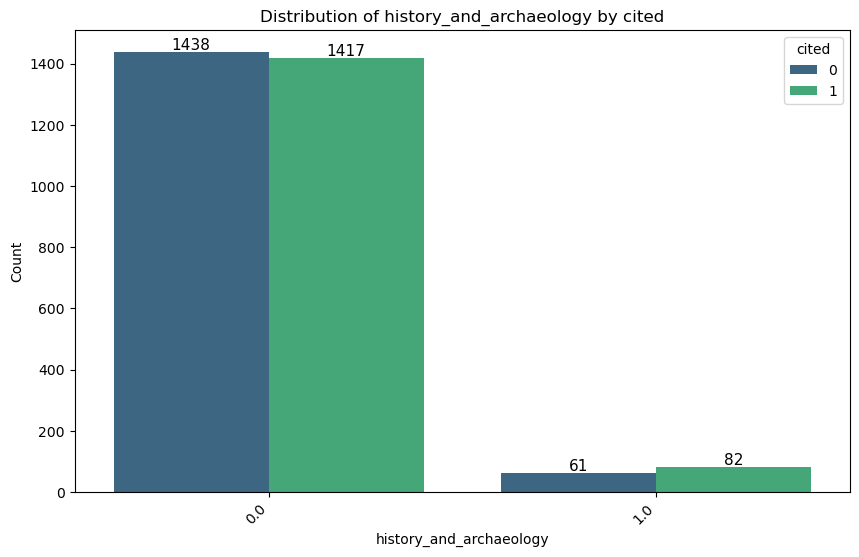

now in languages_and_literature
Chi-Squared Value: 0.7756465347456474
Original P-value: 0.3784758999559332
Bootstrap Mean P-value: 0.3952040766180404
Cramér's V (Effect Size): 0.016084816623110187
Effect Size: Weak association
No significant association between languages_and_literature and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


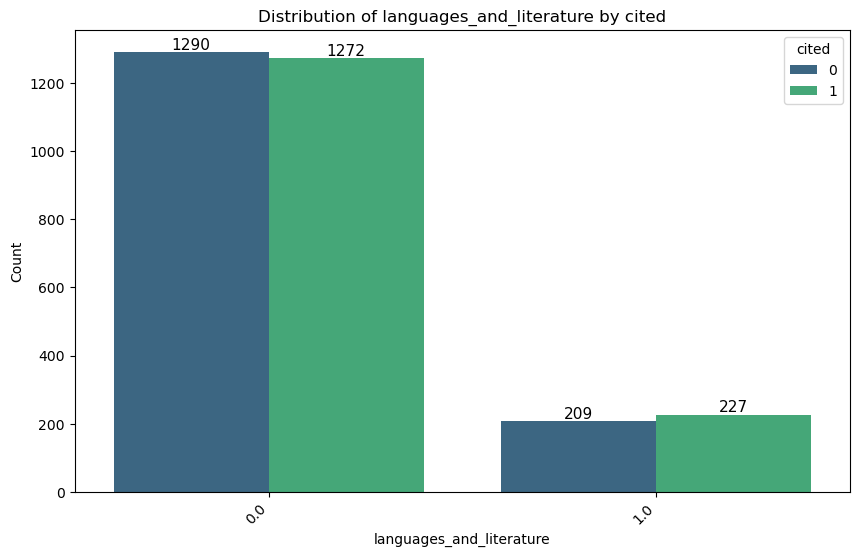

now in philosophy_ethics_and_religion
Chi-Squared Value: 0.01224793280386966
Original P-value: 0.9118777357318046
Bootstrap Mean P-value: 0.5387884607588412
Cramér's V (Effect Size): 0.002021229290931858
Effect Size: Weak association
No significant association between philosophy_ethics_and_religion and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


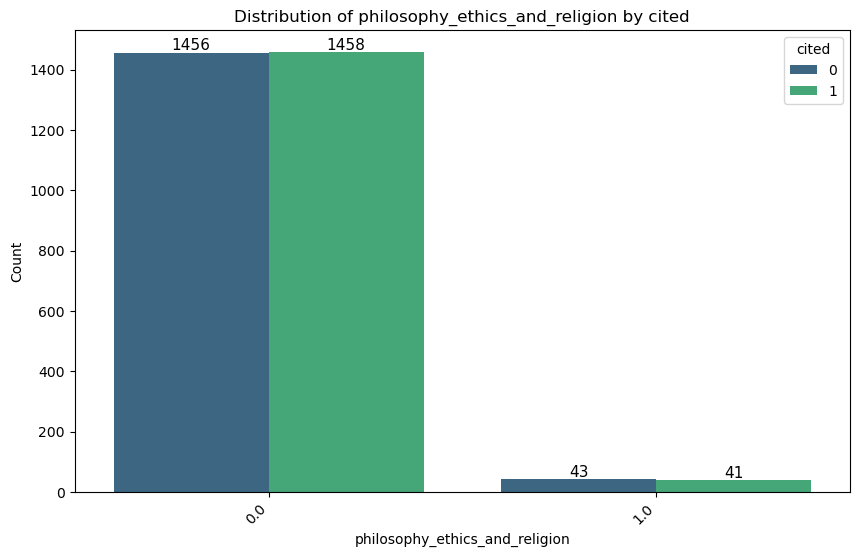

now in arts
Chi-Squared Value: 0.04200291414481058
Original P-value: 0.8376142174825421
Bootstrap Mean P-value: 0.5673614653102224
Cramér's V (Effect Size): 0.003743035077224063
Effect Size: Weak association
No significant association between arts and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


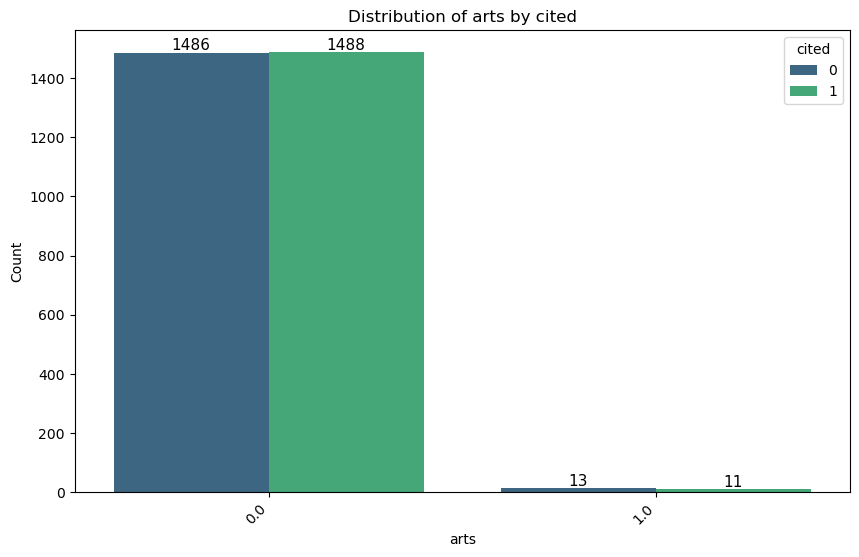

now in other_humanities_and_the_arts
Chi-Squared Value: 1.3842323104068073
Original P-value: 0.23938154440504283
Bootstrap Mean P-value: 0.32780409126252896
Cramér's V (Effect Size): 0.02148763790005667
Effect Size: Weak association
No significant association between other_humanities_and_the_arts and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


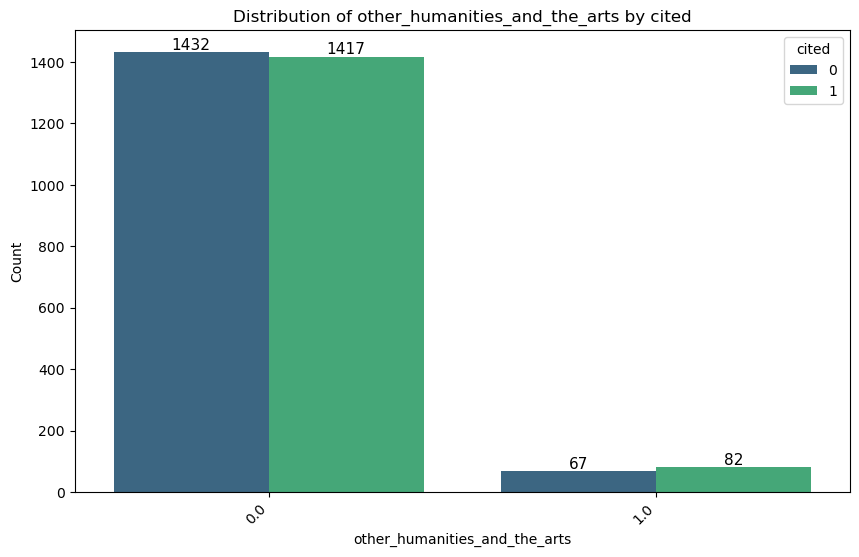

now in applied_research
Chi-Squared Value: 3.3759664520371784
Original P-value: 0.0661537695532712
Bootstrap Mean P-value: 0.183752480079854
Cramér's V (Effect Size): 0.03355700919216443
Effect Size: Weak association
No significant association between applied_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


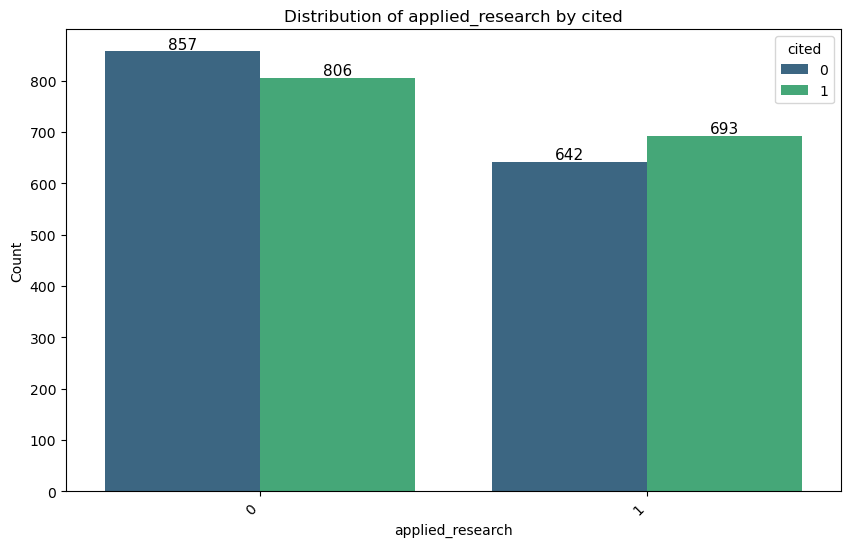

now in conclusive_research
Chi-Squared Value: 0.08366822951551686
Original P-value: 0.7723865441139722
Bootstrap Mean P-value: 0.6058743990840769
Cramér's V (Effect Size): 0.005282803723588476
Effect Size: Weak association
No significant association between conclusive_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


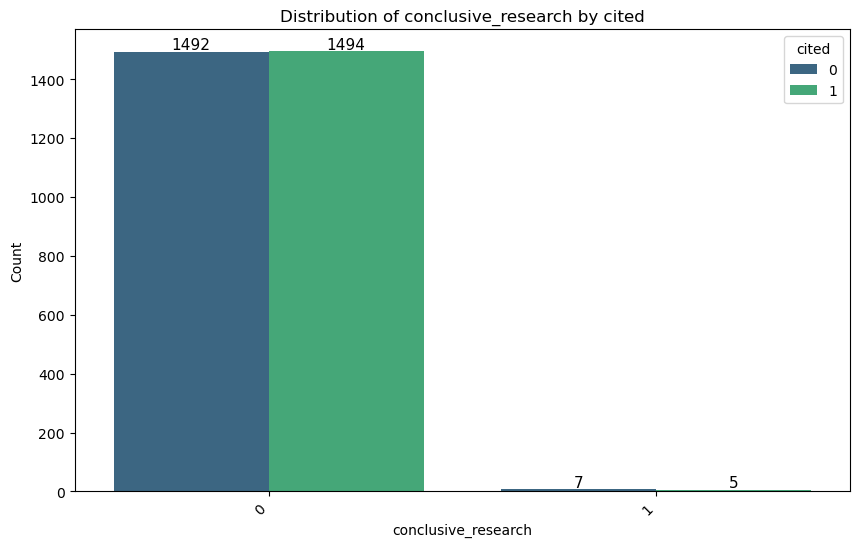

now in correlational_research
Chi-Squared Value: 0.3730696449874532
Original P-value: 0.5413357847335041
Bootstrap Mean P-value: 0.44900264418445557
Cramér's V (Effect Size): 0.011155245761575665
Effect Size: Weak association
No significant association between correlational_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


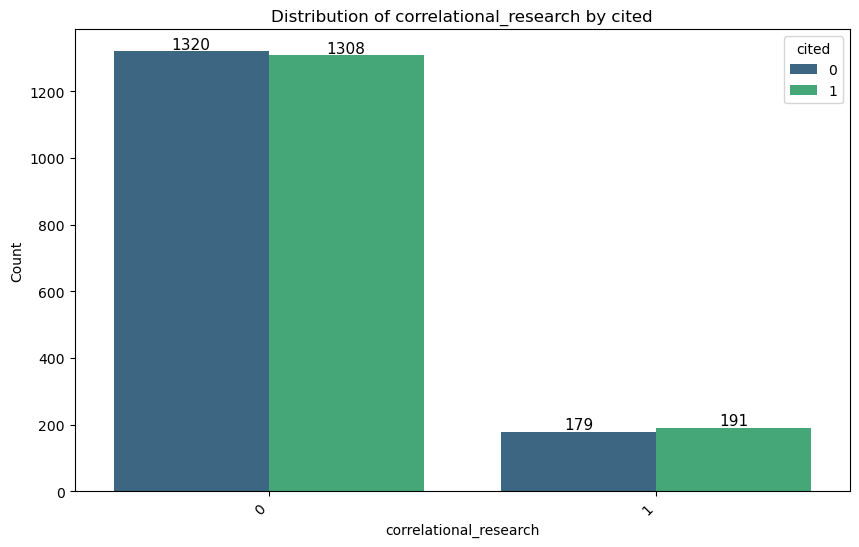

now in descriptive_research
Chi-Squared Value: 5.6069212013742655
Original P-value: 0.017889668650925485
Bootstrap Mean P-value: 0.09461913950306342
Cramér's V (Effect Size): 0.043246046611103636
Effect Size: Weak association
Significant association between descriptive_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


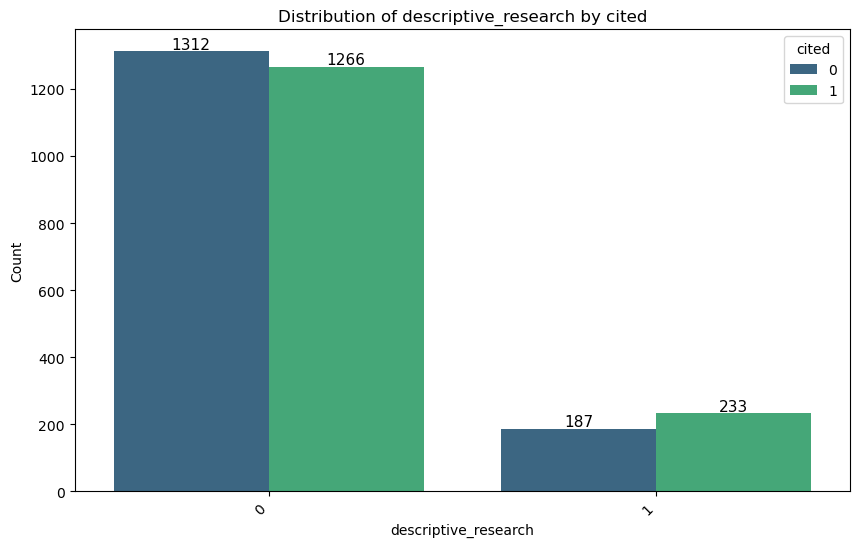

now in ethnographic_research
Chi-Squared Value: 0.0380818098386477
Original P-value: 0.8452789557981925
Bootstrap Mean P-value: 0.5393038707271373
Cramér's V (Effect Size): 0.0035640433334633344
Effect Size: Weak association
No significant association between ethnographic_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


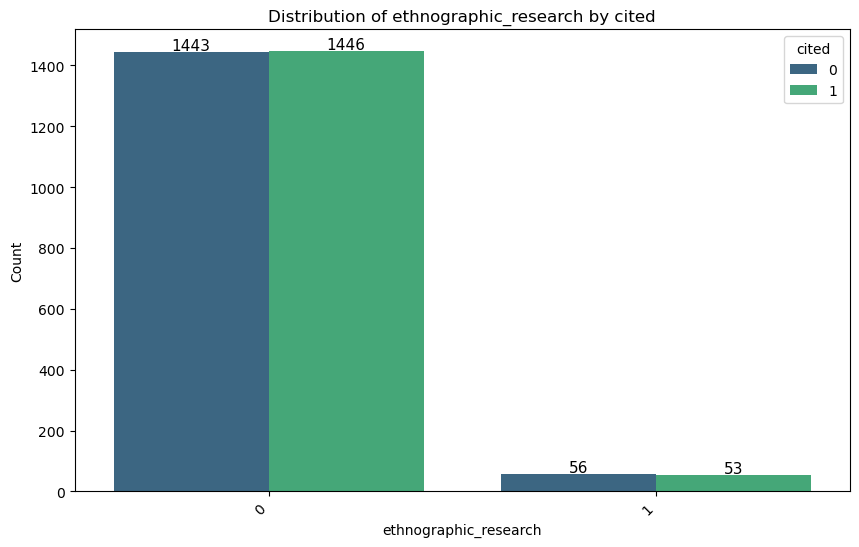

now in experiment
Chi-Squared Value: 0.025338066260987155
Original P-value: 0.8735275707631016
Bootstrap Mean P-value: 0.5664680368112611
Cramér's V (Effect Size): 0.002907173287693535
Effect Size: Weak association
No significant association between experiment and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


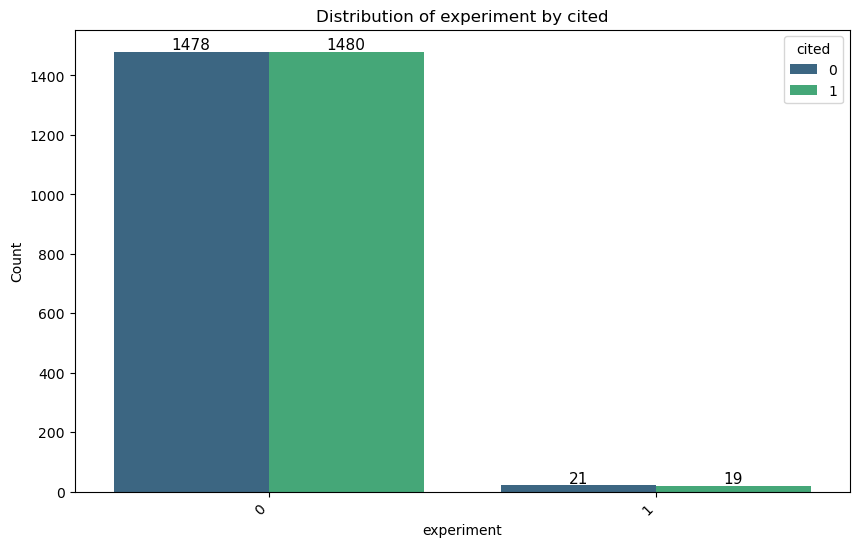

now in exploratory_research
Chi-Squared Value: 0.5745995971570289
Original P-value: 0.44843692612302355
Bootstrap Mean P-value: 0.42305181233426586
Cramér's V (Effect Size): 0.013844167473501824
Effect Size: Weak association
No significant association between exploratory_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


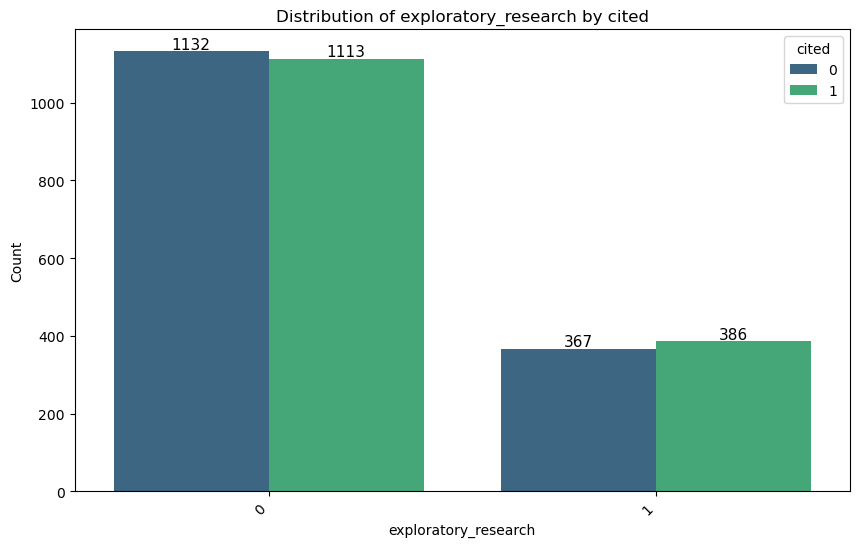

now in focus_groups
Chi-Squared Value: 2.129723543224737
Original P-value: 0.14446680955268124
Bootstrap Mean P-value: 0.2677855739084379
Cramér's V (Effect Size): 0.026652981734979594
Effect Size: Weak association
No significant association between focus_groups and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


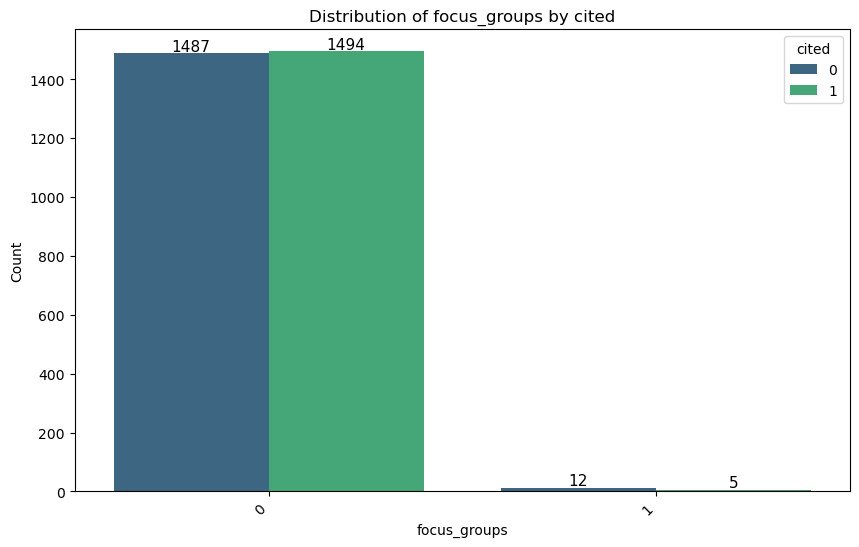

now in interviews
Chi-Squared Value: 1.9609790995963003
Original P-value: 0.16140864423461249
Bootstrap Mean P-value: 0.2926259617843971
Cramér's V (Effect Size): 0.02557529596520645
Effect Size: Weak association
No significant association between interviews and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


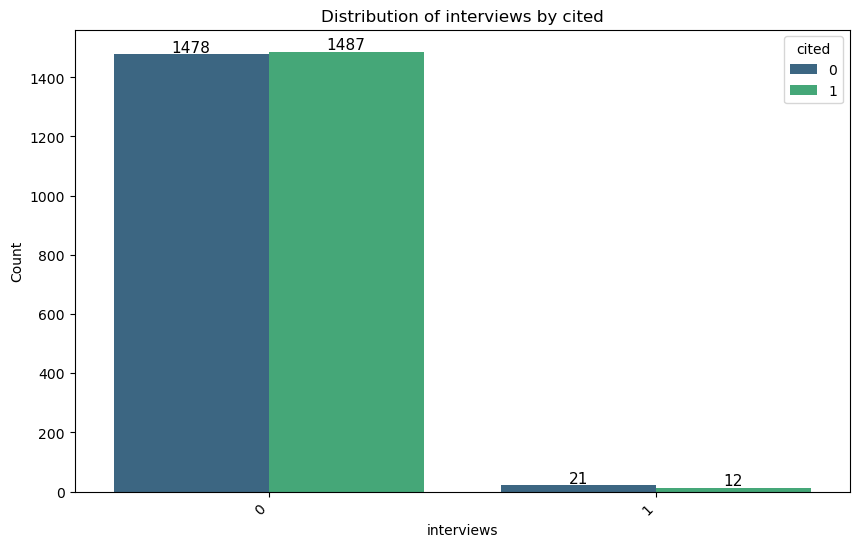

now in mixed_methods
Chi-Squared Value: 0.42322459251501565
Original P-value: 0.5153324050908868
Bootstrap Mean P-value: 0.46029779699805695
Cramér's V (Effect Size): 0.011881455164368006
Effect Size: Weak association
No significant association between mixed_methods and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


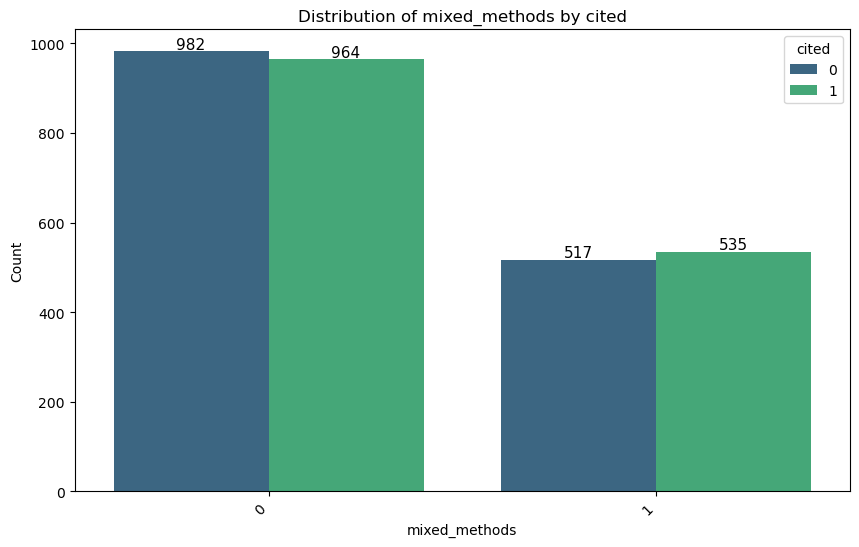

now in observation
Chi-Squared Value: 0.3055620267909144
Original P-value: 0.5804163581414713
Bootstrap Mean P-value: 0.47524356996916445
Cramér's V (Effect Size): 0.010095640489913085
Effect Size: Weak association
No significant association between observation and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


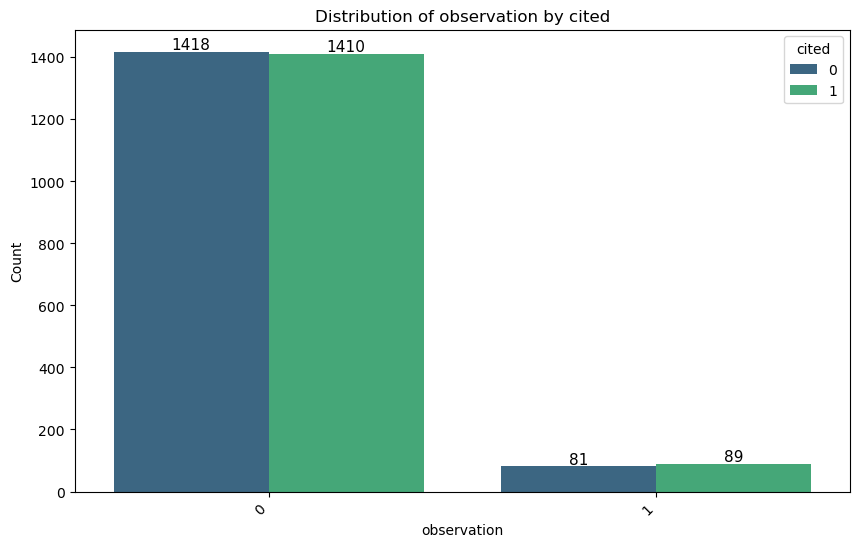

now in qualitative_research
Chi-Squared Value: 0.8154577751461771
Original P-value: 0.3665115616658329
Bootstrap Mean P-value: 0.4021475953439429
Cramér's V (Effect Size): 0.016492440453436005
Effect Size: Weak association
No significant association between qualitative_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


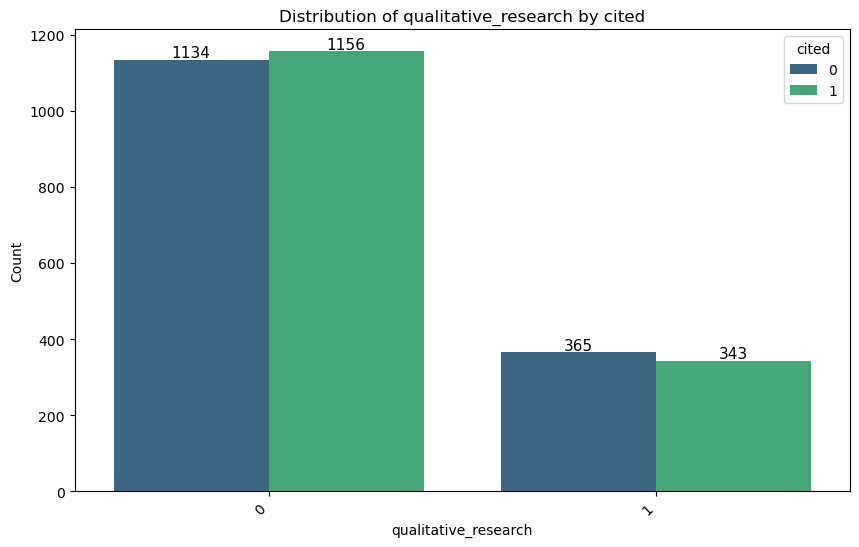

now in quantitative_research
Chi-Squared Value: 0.3305087620419368
Original P-value: 0.5653596640197057
Bootstrap Mean P-value: 0.4713971596189491
Cramér's V (Effect Size): 0.010499670601299966
Effect Size: Weak association
No significant association between quantitative_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


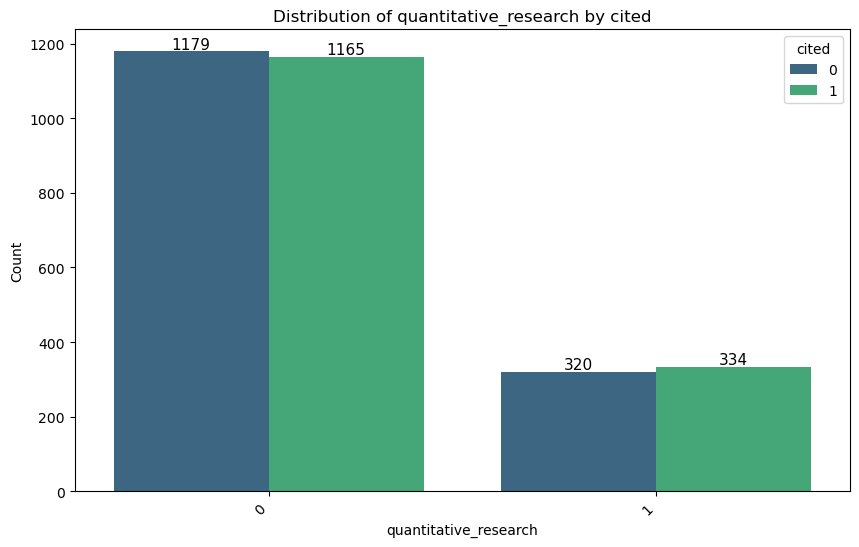

now in questionnaires
Chi-Squared Value: 5.808435923309788
Original P-value: 0.015949473485907743
Bootstrap Mean P-value: 0.07716638121528448
Cramér's V (Effect Size): 0.044016325748425705
Effect Size: Weak association
Significant association between questionnaires and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


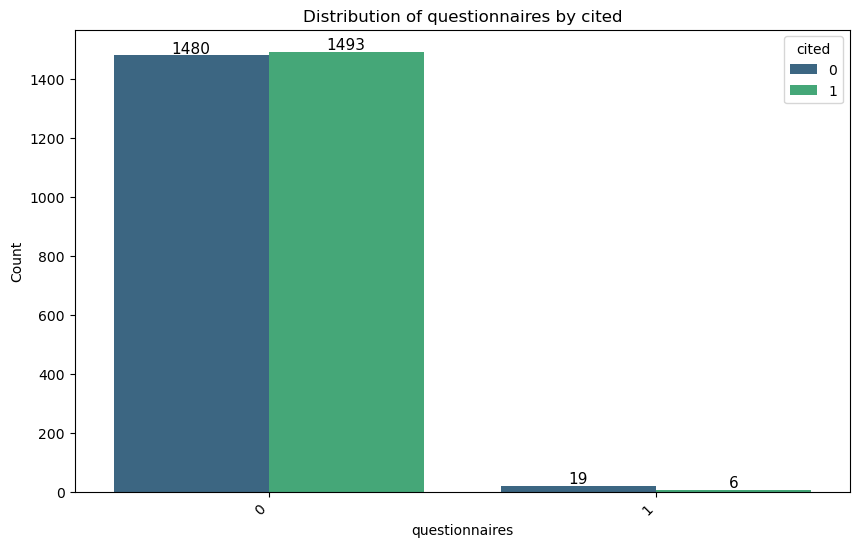

now in secondary_research
Chi-Squared Value: 0.875070417190843
Original P-value: 0.3495554167167664
Bootstrap Mean P-value: 0.39560678465648397
Cramér's V (Effect Size): 0.017084634291750864
Effect Size: Weak association
No significant association between secondary_research and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


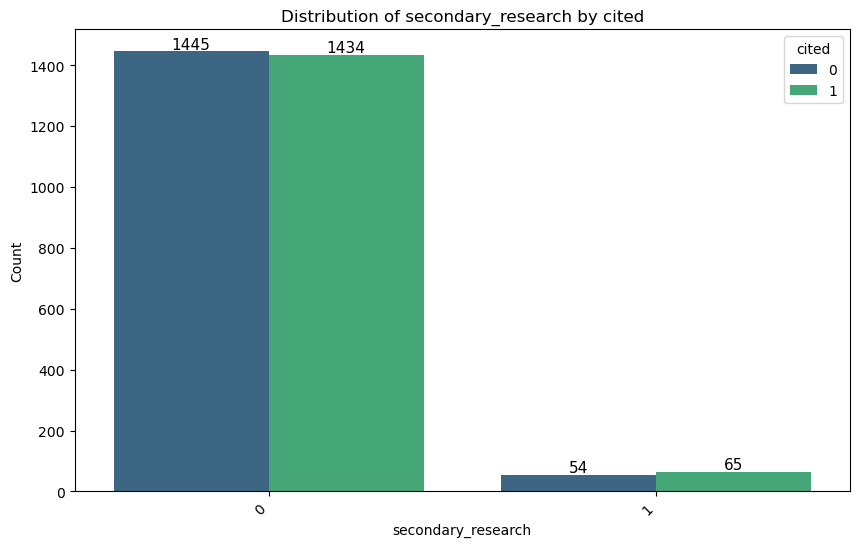

now in survey_methodology
Chi-Squared Value: 0.746305074145394
Original P-value: 0.3876485935345415
Bootstrap Mean P-value: 0.41172590509604934
Cramér's V (Effect Size): 0.015777652368396573
Effect Size: Weak association
No significant association between survey_methodology and cited.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


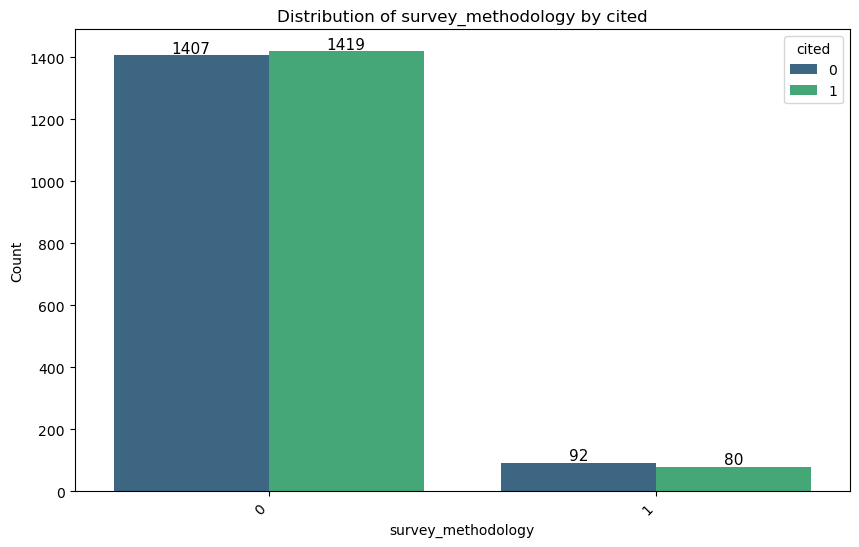

In [21]:
for col in df_c19.columns:
    if col in ['abstract', 'title', 'Unnamed: 0', 'Unnamed: 0.1', 'cited', 'research_methods>=5_c19', 'disciplines>=5_c19']:
        continue
    print(f"now in {col}")
    get_stat_significance(df_c19, col, 'cited')
    try:
        plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable=col)
    except: 
        pass


now in novelty
Chi-Squared Value: 240.26277645273726
Original P-value: 1.9920906553215145e-47
Bootstrap Mean P-value: 2.7396789015166223e-33
Cramér's V (Effect Size): 0.24508303513948965
Effect Size: Moderate association
Significant association between novelty and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


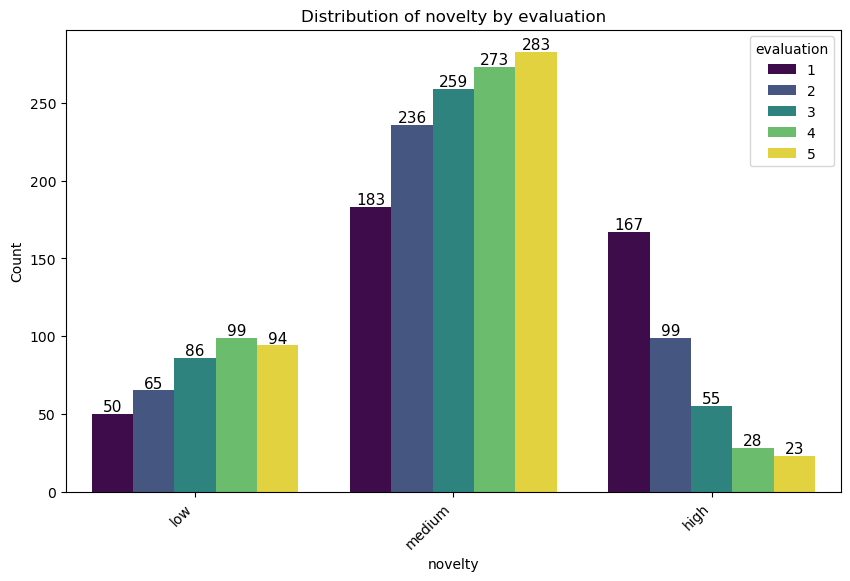

now in rigor
Chi-Squared Value: 350.50105711647814
Original P-value: 7.0785552881818806e-71
Bootstrap Mean P-value: 1.3036167314856757e-50
Cramér's V (Effect Size): 0.2960156487064823
Effect Size: Moderate association
Significant association between rigor and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


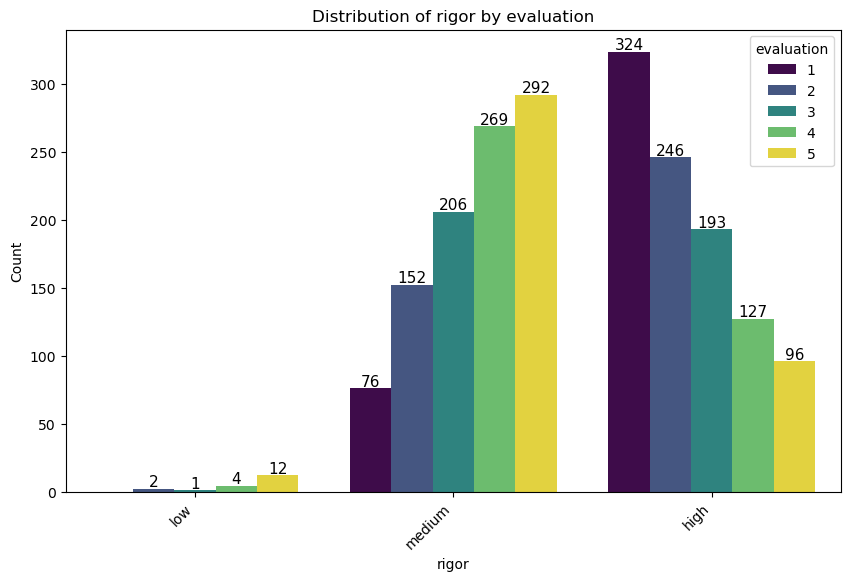

now in grammar
Chi-Squared Value: 96.81421111606593
Original P-value: 4.686521172253479e-20
Bootstrap Mean P-value: 1.5156003423023729e-12
Cramér's V (Effect Size): 0.2200161484028683
Effect Size: Moderate association
Significant association between grammar and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


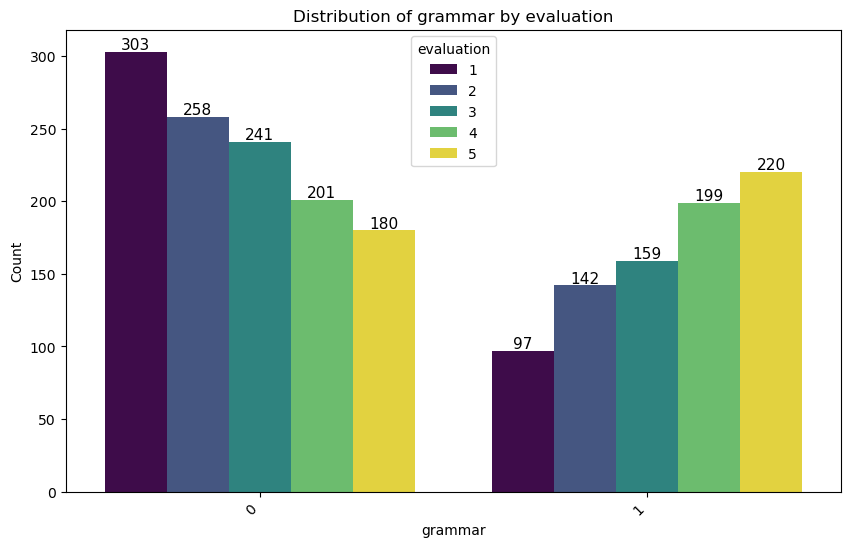

now in replicability
Chi-Squared Value: 207.7815894147755
Original P-value: 7.971471796954154e-44
Bootstrap Mean P-value: 1.0810050995345587e-27
Cramér's V (Effect Size): 0.32232094984252535
Effect Size: Strong association
Significant association between replicability and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


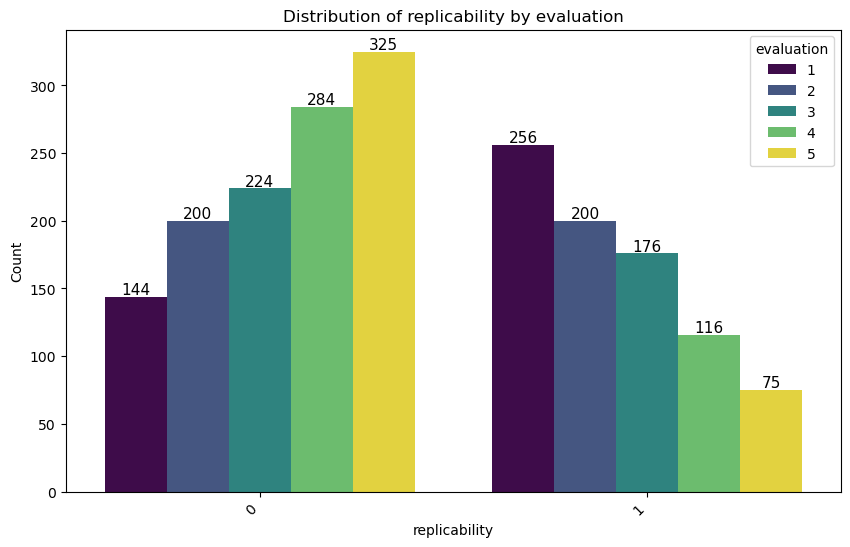

now in accessibility
Chi-Squared Value: 12.046424759871933
Original P-value: 0.1491445134929061
Bootstrap Mean P-value: 0.07002943038312734
Cramér's V (Effect Size): 0.0548781030099254
Effect Size: Weak association
No significant association between accessibility and evaluation.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


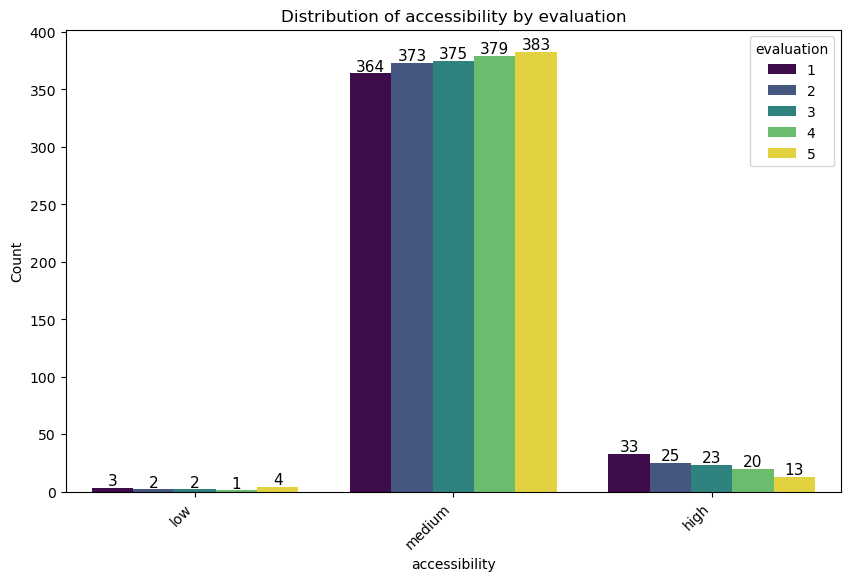

now in mathematics
Chi-Squared Value: 77.14631997136937
Original P-value: 7.003097929743016e-16
Bootstrap Mean P-value: 2.293598305482805e-10
Cramér's V (Effect Size): 0.19640050912786525
Effect Size: Moderate association
Significant association between mathematics and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


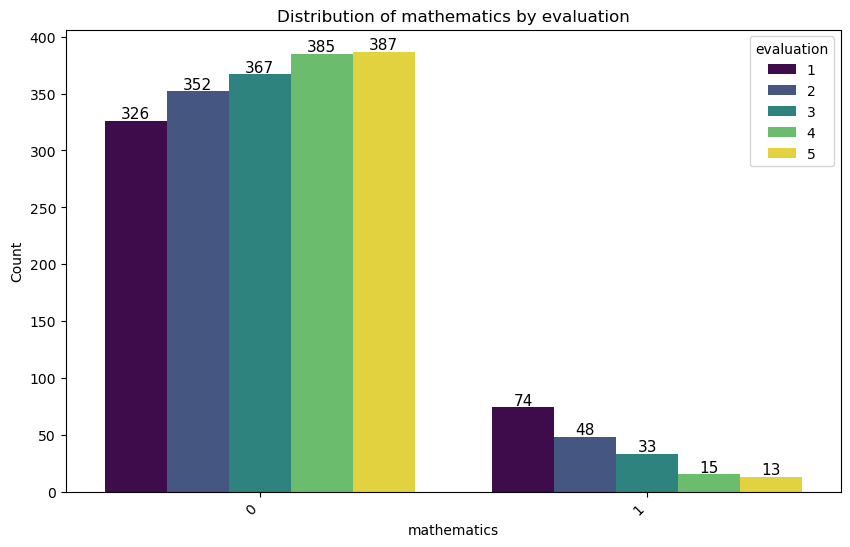

now in computer_and_information_sciences
Chi-Squared Value: 156.49496080627097
Original P-value: 8.251568346617146e-33
Bootstrap Mean P-value: 1.0389320254964428e-21
Cramér's V (Effect Size): 0.27972751098727394
Effect Size: Moderate association
Significant association between computer_and_information_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


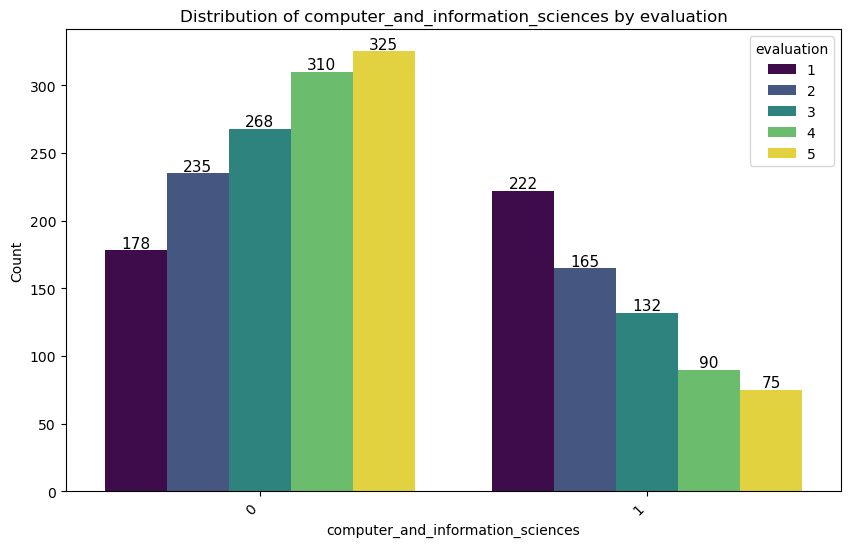

now in physical_sciences
Chi-Squared Value: 186.38392857142856
Original P-value: 3.171451007308937e-39
Bootstrap Mean P-value: 4.874314840922071e-28
Cramér's V (Effect Size): 0.30527358923712067
Effect Size: Strong association
Significant association between physical_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


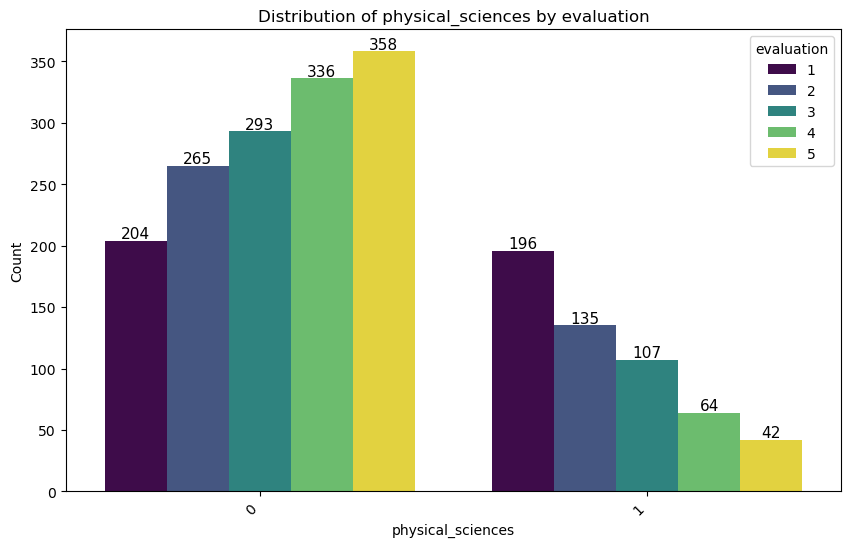

now in chemical_sciences
Chi-Squared Value: 135.98793642951253
Original P-value: 2.0389469481192423e-28
Bootstrap Mean P-value: 1.6510014294767746e-17
Cramér's V (Effect Size): 0.26075653053136805
Effect Size: Moderate association
Significant association between chemical_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


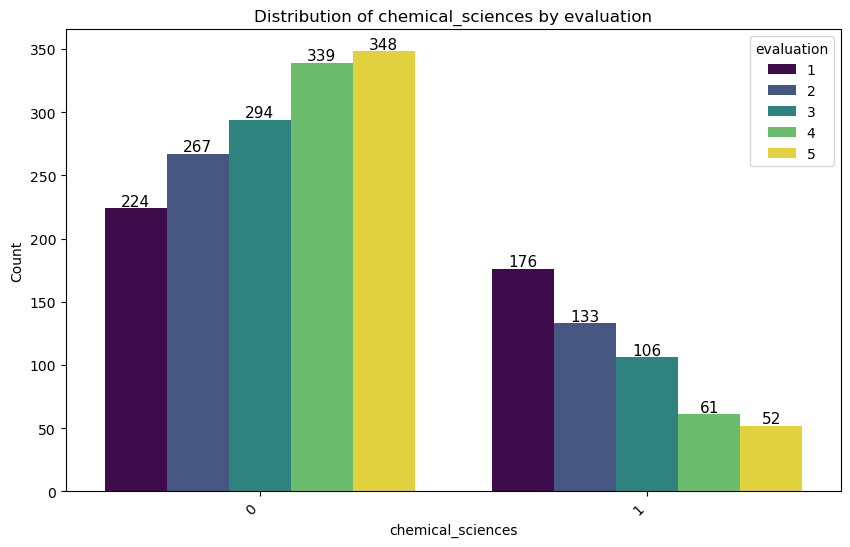

now in earth_and_related_environmental_sciences
Chi-Squared Value: 118.0999429868569
Original P-value: 1.3596778711456364e-24
Bootstrap Mean P-value: 1.215945791037273e-16
Cramér's V (Effect Size): 0.2430019989494499
Effect Size: Moderate association
Significant association between earth_and_related_environmental_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


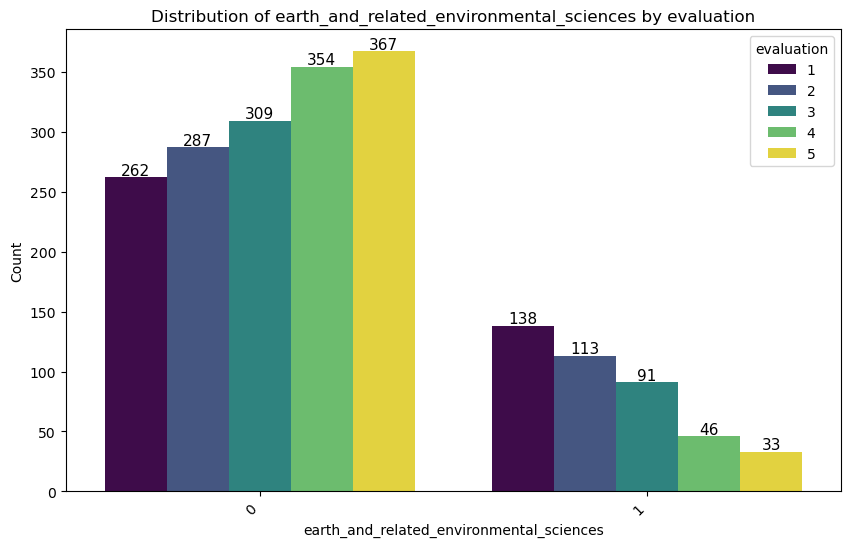

now in biological_sciences
Chi-Squared Value: 243.44701165950548
Original P-value: 1.6791165934255688e-51
Bootstrap Mean P-value: 5.350149489266908e-38
Cramér's V (Effect Size): 0.3488889591686053
Effect Size: Strong association
Significant association between biological_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


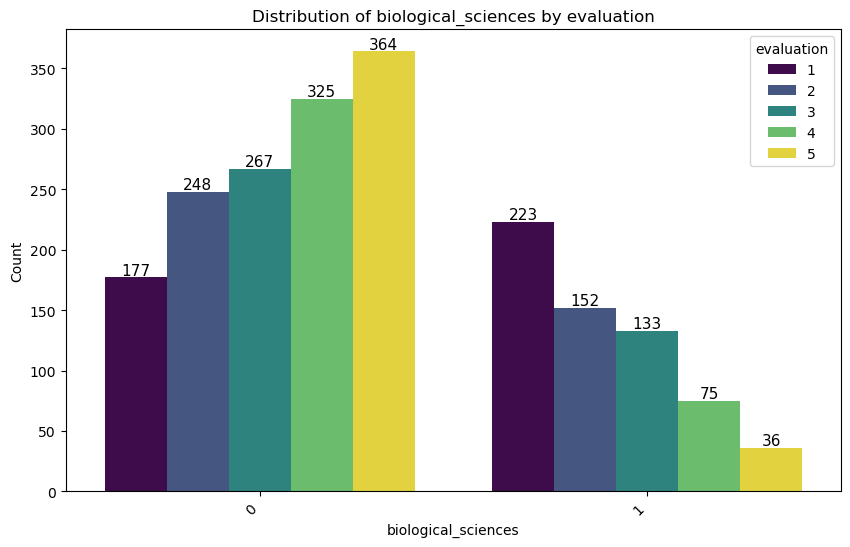

now in other_natural_sciences
Chi-Squared Value: 171.73796612438912
Original P-value: 4.430362137640699e-36
Bootstrap Mean P-value: 3.189383426427022e-24
Cramér's V (Effect Size): 0.29303409880454967
Effect Size: Moderate association
Significant association between other_natural_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


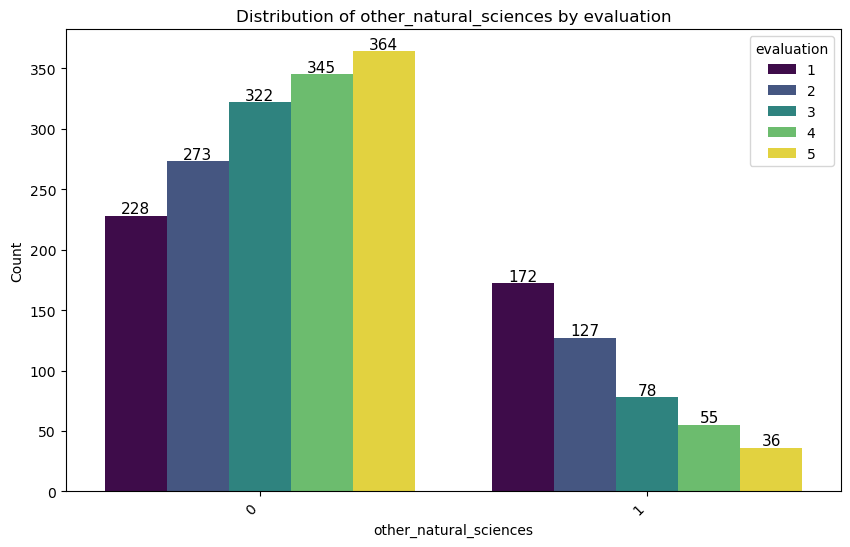

now in civil_engineering
Chi-Squared Value: 31.824466758845794
Original P-value: 2.0778099018927364e-06
Bootstrap Mean P-value: 0.0007859763213398676
Cramér's V (Effect Size): 0.1261437013069733
Effect Size: Moderate association
Significant association between civil_engineering and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


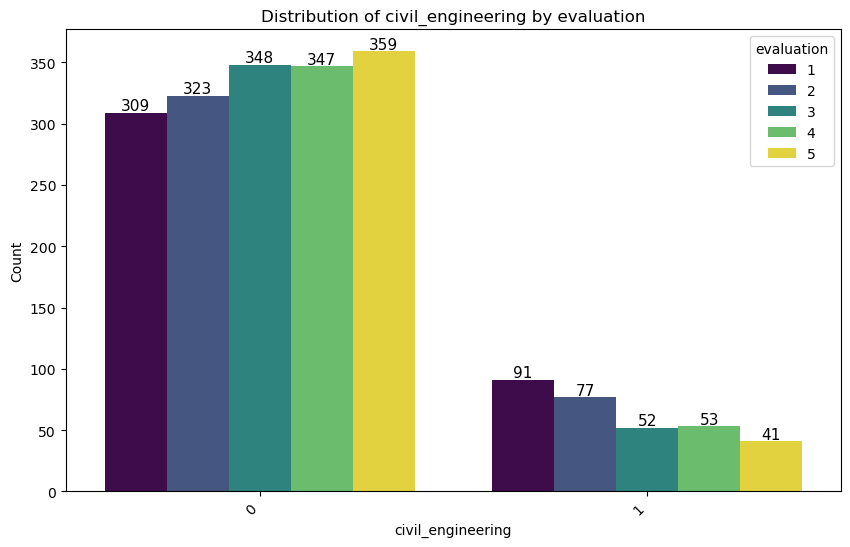

now in electrical_engineering
Chi-Squared Value: 57.1160020555436
Original P-value: 1.1697493144825432e-11
Bootstrap Mean P-value: 4.3131414569429305e-06
Cramér's V (Effect Size): 0.1689911270681742
Effect Size: Moderate association
Significant association between electrical_engineering and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


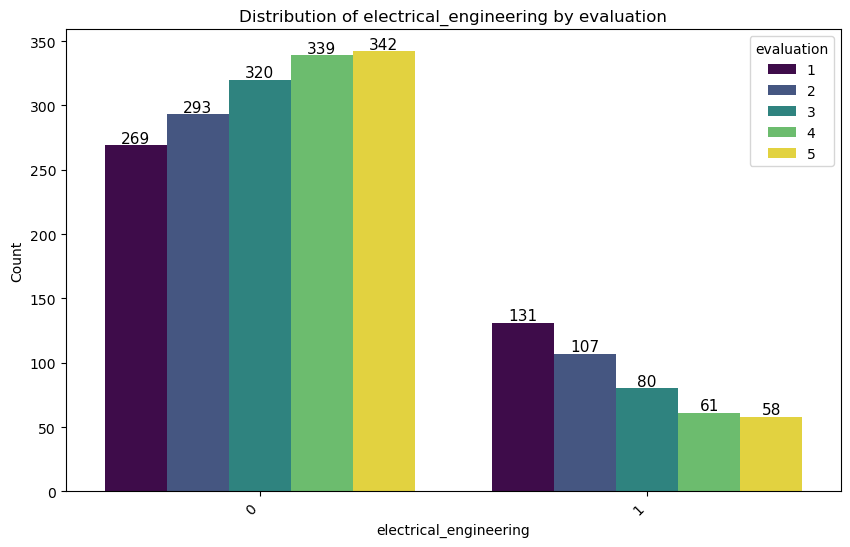

now in mechanical_engineering
Chi-Squared Value: 29.272184236601785
Original P-value: 6.88262609520225e-06
Bootstrap Mean P-value: 0.0016420340066561645
Cramér's V (Effect Size): 0.1209797177972444
Effect Size: Moderate association
Significant association between mechanical_engineering and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


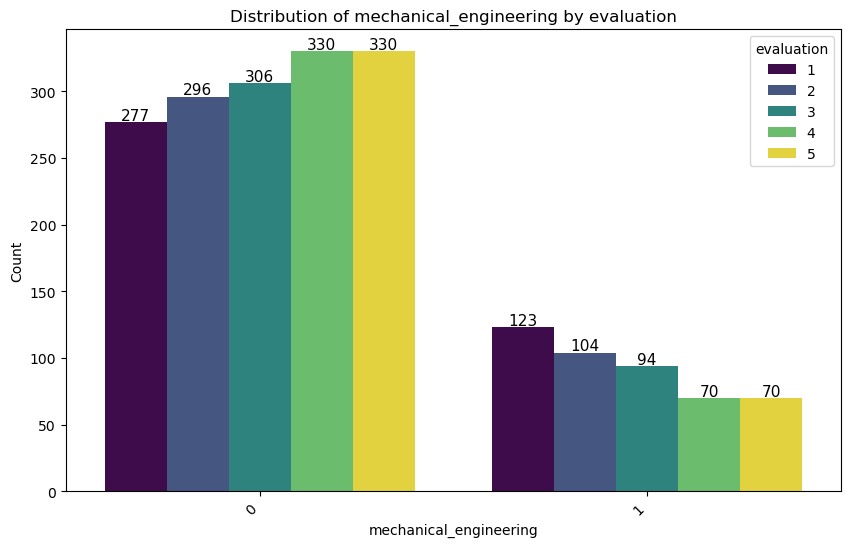

now in chemical_engineering
Chi-Squared Value: 47.04117400484583
Original P-value: 1.495098192136837e-09
Bootstrap Mean P-value: 6.701633167956694e-06
Cramér's V (Effect Size): 0.15336422986610312
Effect Size: Moderate association
Significant association between chemical_engineering and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


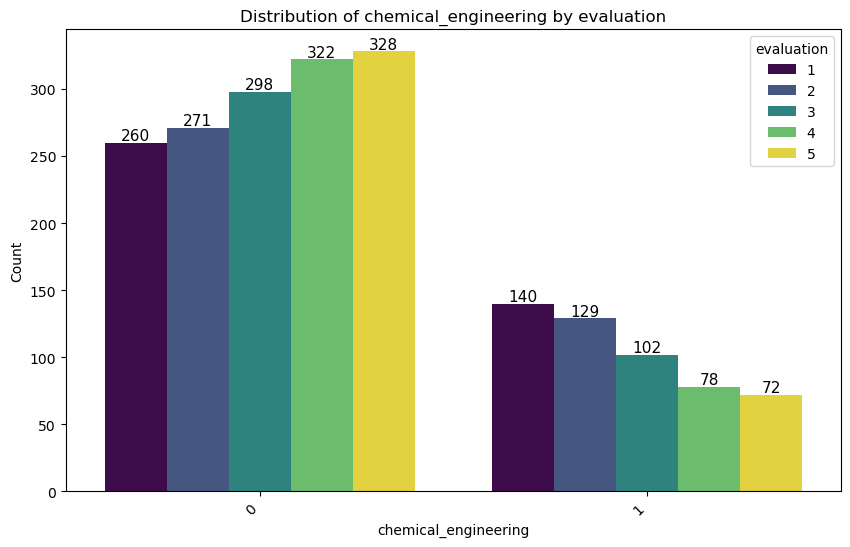

now in materials_engineering
Chi-Squared Value: 25.58519324986391
Original P-value: 3.8361175935041533e-05
Bootstrap Mean P-value: 0.002483111160118515
Cramér's V (Effect Size): 0.11310436165299707
Effect Size: Moderate association
Significant association between materials_engineering and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


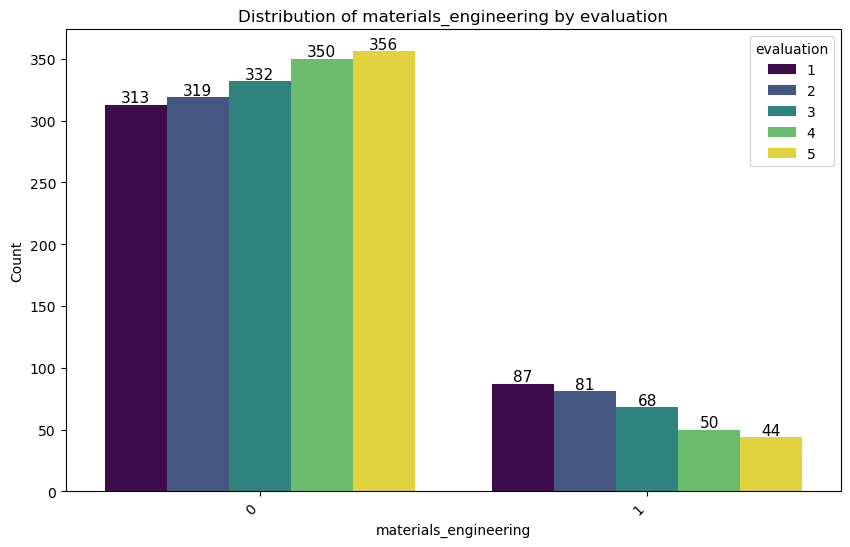

now in environmental_engineering
Chi-Squared Value: 54.235611488097796
Original P-value: 4.697513428368978e-11
Bootstrap Mean P-value: 6.743800829097507e-07
Cramér's V (Effect Size): 0.16467484854721712
Effect Size: Moderate association
Significant association between environmental_engineering and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


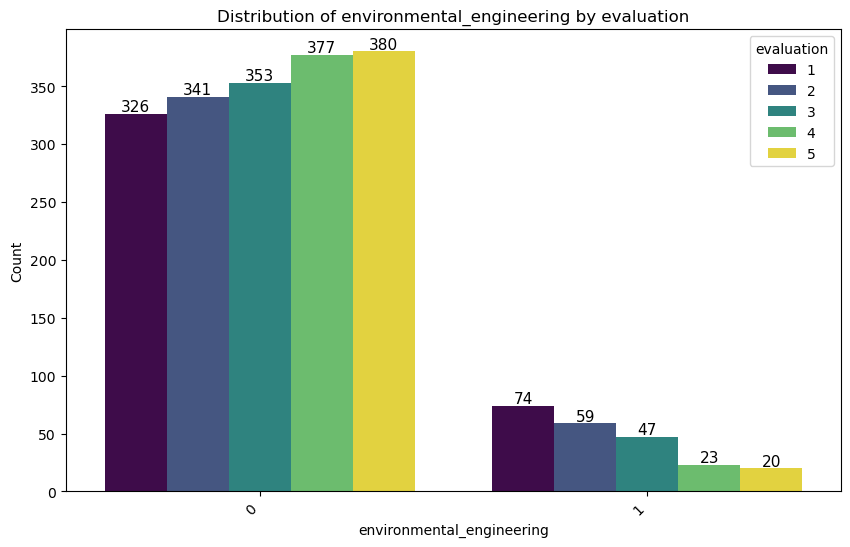

now in evironmental_biotechnology
Chi-Squared Value: 89.69808082384147
Original P-value: 1.5262985128654605e-18
Bootstrap Mean P-value: 1.6666056153041584e-12
Cramér's V (Effect Size): 0.21177592028349382
Effect Size: Moderate association
Significant association between evironmental_biotechnology and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


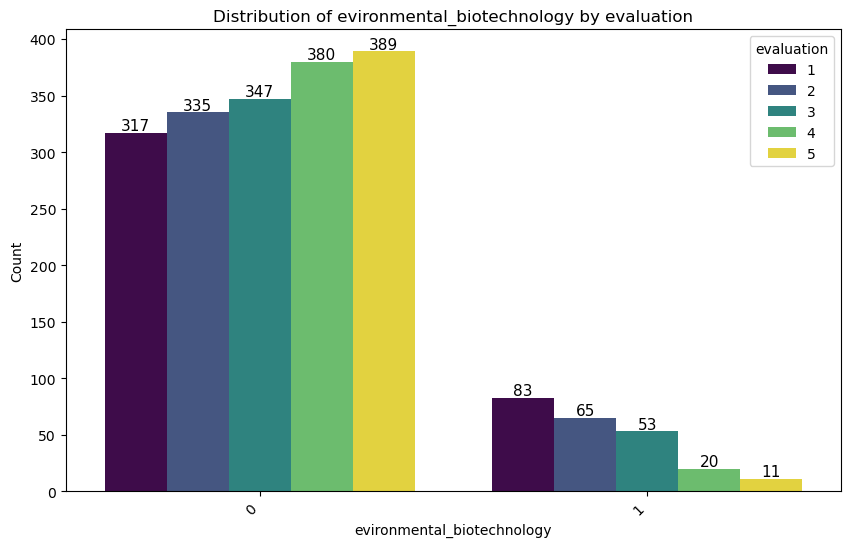

now in industrial_biotechnology
Chi-Squared Value: 73.00787148409914
Original P-value: 5.2555598403588826e-15
Bootstrap Mean P-value: 8.972874908500212e-09
Cramér's V (Effect Size): 0.1910600317754856
Effect Size: Moderate association
Significant association between industrial_biotechnology and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


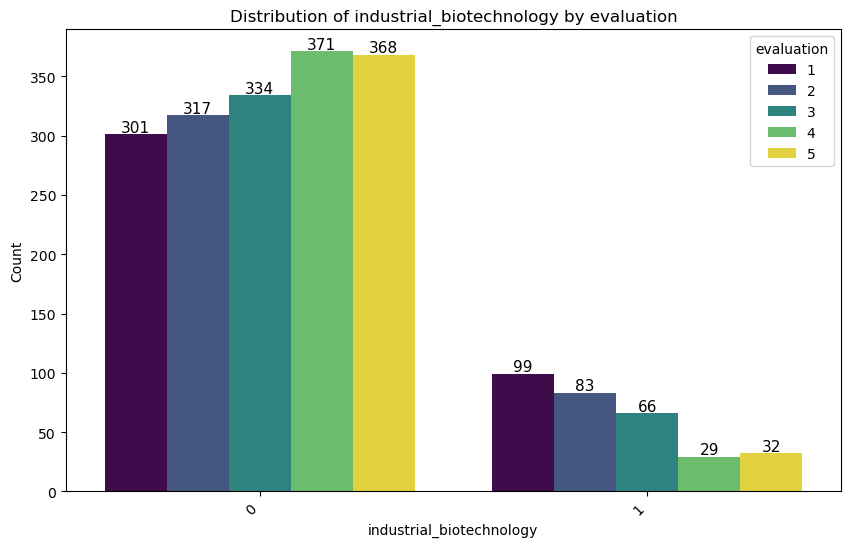

now in nano-technology
Chi-Squared Value: 38.54496913065243
Original P-value: 8.64914701503055e-08
Bootstrap Mean P-value: 1.613248842238784e-05
Cramér's V (Effect Size): 0.13882537435687403
Effect Size: Moderate association
Significant association between nano-technology and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


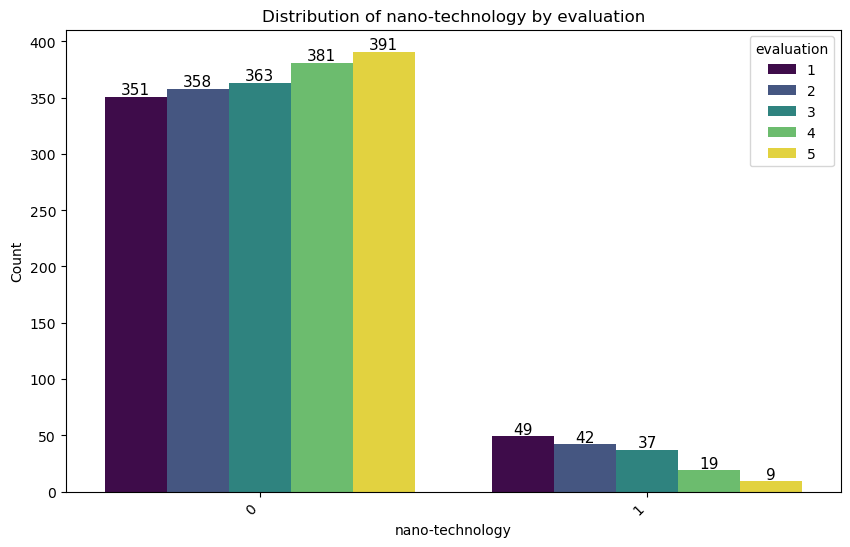

now in other_engineering_and_technologies
Chi-Squared Value: 57.14861867311957
Original P-value: 1.1514623497203819e-11
Bootstrap Mean P-value: 3.0941213249347427e-07
Cramér's V (Effect Size): 0.16903937214909368
Effect Size: Moderate association
Significant association between other_engineering_and_technologies and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


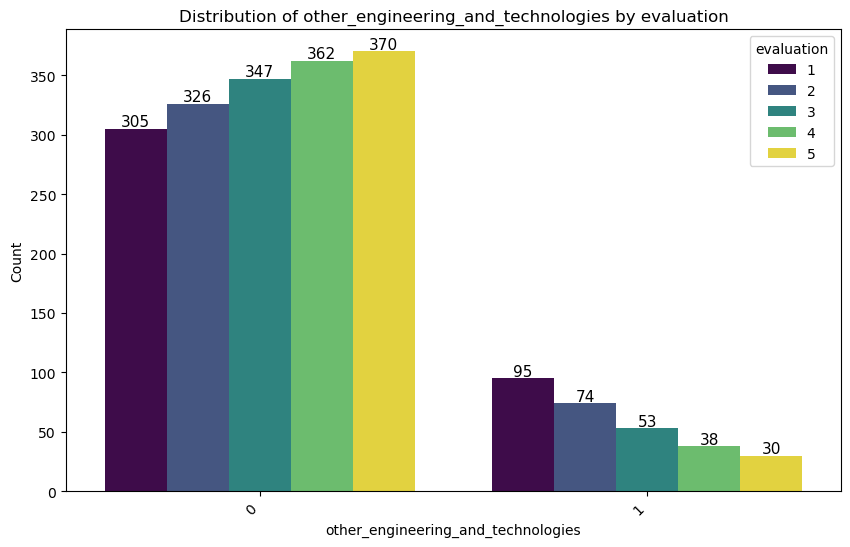

now in basic_medicine
Chi-Squared Value: 197.45258093773413
Original P-value: 1.3259480087015795e-41
Bootstrap Mean P-value: 1.6879900138569237e-26
Cramér's V (Effect Size): 0.314207400404362
Effect Size: Strong association
Significant association between basic_medicine and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


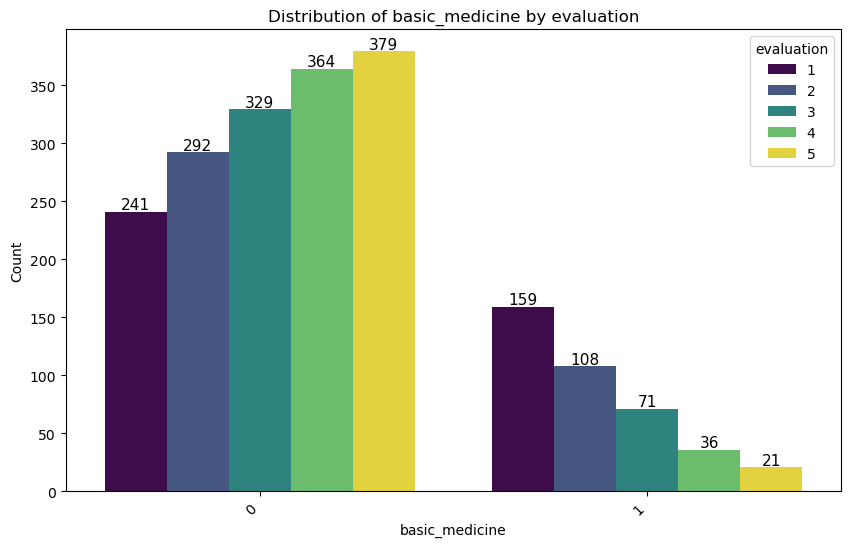

now in clinical_medicine
Chi-Squared Value: 103.70039460948551
Original P-value: 1.6024778598939112e-21
Bootstrap Mean P-value: 6.56325734165847e-14
Cramér's V (Effect Size): 0.22770638397889234
Effect Size: Moderate association
Significant association between clinical_medicine and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


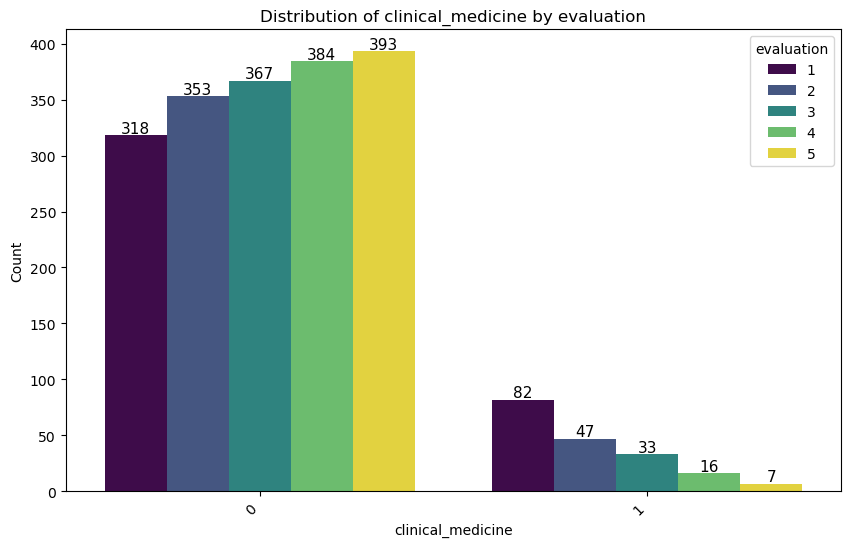

now in health_sciences
Chi-Squared Value: 86.43705364557383
Original P-value: 7.516861606224953e-18
Bootstrap Mean P-value: 3.662182061706107e-11
Cramér's V (Effect Size): 0.2078906607396949
Effect Size: Moderate association
Significant association between health_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


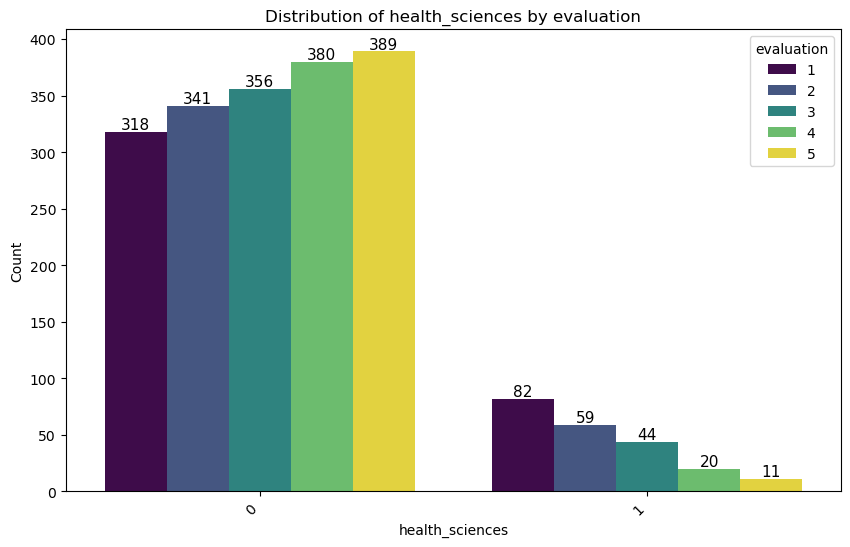

now in medical_biotechnology
Chi-Squared Value: 132.21433316724793
Original P-value: 1.3085527689783016e-27
Bootstrap Mean P-value: 2.7079347381065177e-17
Cramér's V (Effect Size): 0.25711313965572424
Effect Size: Moderate association
Significant association between medical_biotechnology and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


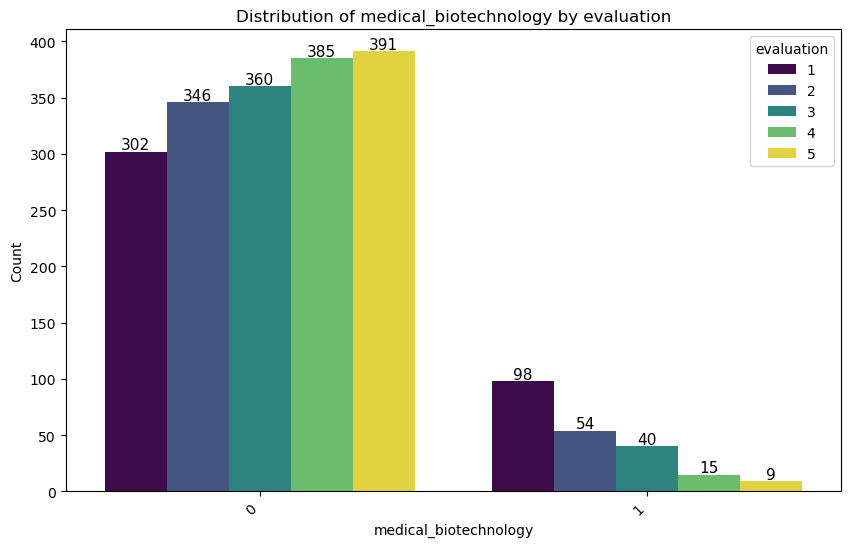

now in other_medical_sciences
Chi-Squared Value: 140.22992033088343
Original P-value: 2.520116816655975e-29
Bootstrap Mean P-value: 1.2112227279269266e-18
Cramér's V (Effect Size): 0.2647922962728367
Effect Size: Moderate association
Significant association between other_medical_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


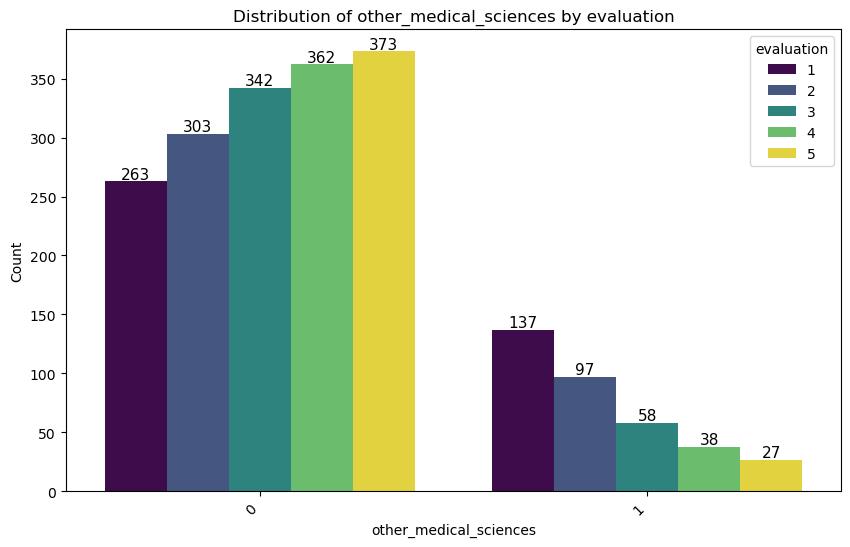

now in agriculture_forestry_and_fisheries
Chi-Squared Value: 83.15004887585533
Original P-value: 3.744132483415088e-17
Bootstrap Mean P-value: 4.947490883396855e-12
Cramér's V (Effect Size): 0.20389954496743654
Effect Size: Moderate association
Significant association between agriculture_forestry_and_fisheries and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


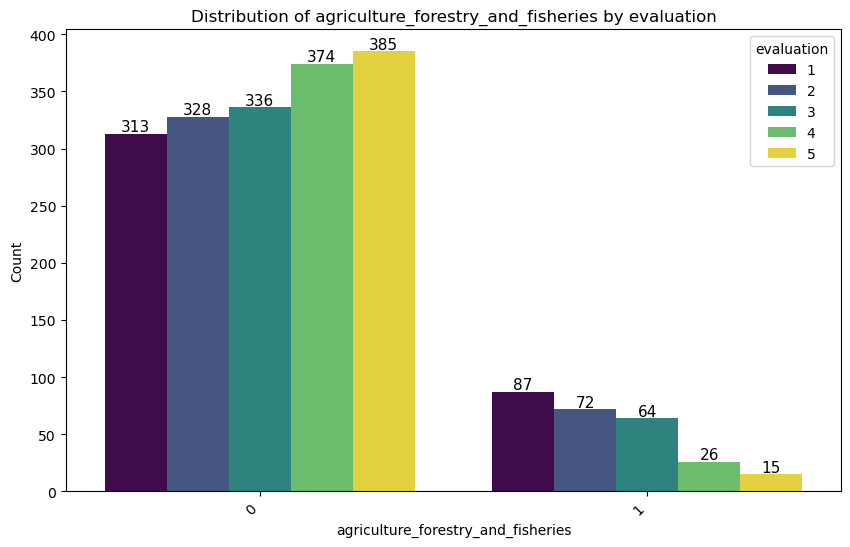

now in animal_and_dairy_science
Chi-Squared Value: 124.73277956755597
Original P-value: 5.205710652190268e-26
Bootstrap Mean P-value: 1.0380261880272741e-17
Cramér's V (Effect Size): 0.24973263660118192
Effect Size: Moderate association
Significant association between animal_and_dairy_science and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


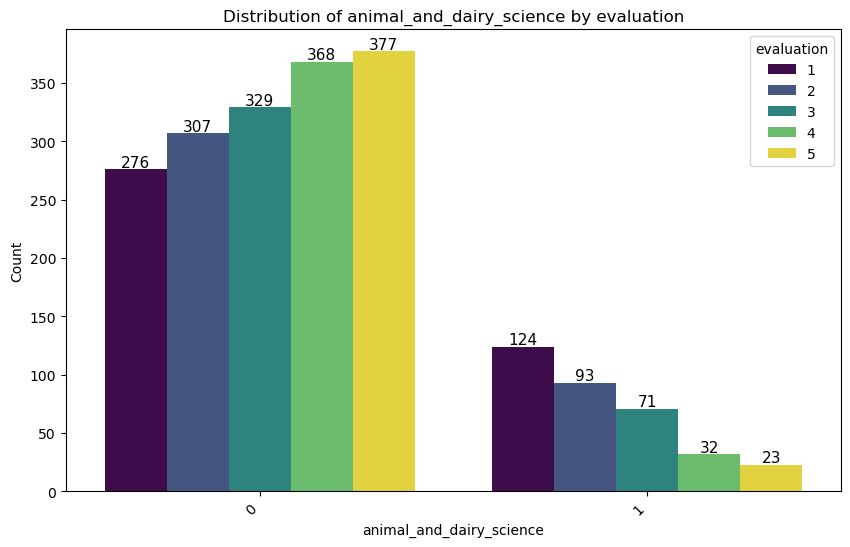

now in veterinary_science
Chi-Squared Value: 123.0176452559219
Original P-value: 1.2105955222919015e-25
Bootstrap Mean P-value: 2.622570189287139e-15
Cramér's V (Effect Size): 0.2480097228496515
Effect Size: Moderate association
Significant association between veterinary_science and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


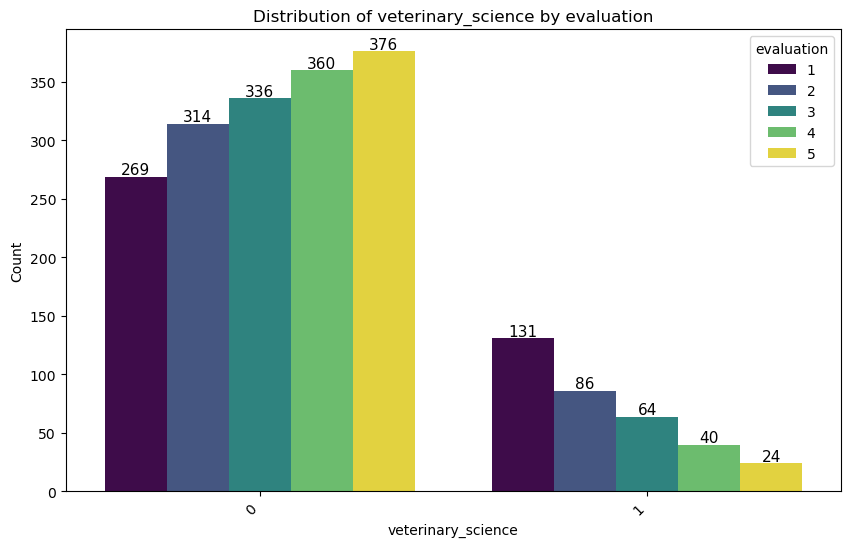

now in agricultural_biotechnology
Chi-Squared Value: 41.88719926756993
Original P-value: 1.760427396923287e-08
Bootstrap Mean P-value: 8.212372146291255e-06
Cramér's V (Effect Size): 0.14471903687416168
Effect Size: Moderate association
Significant association between agricultural_biotechnology and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


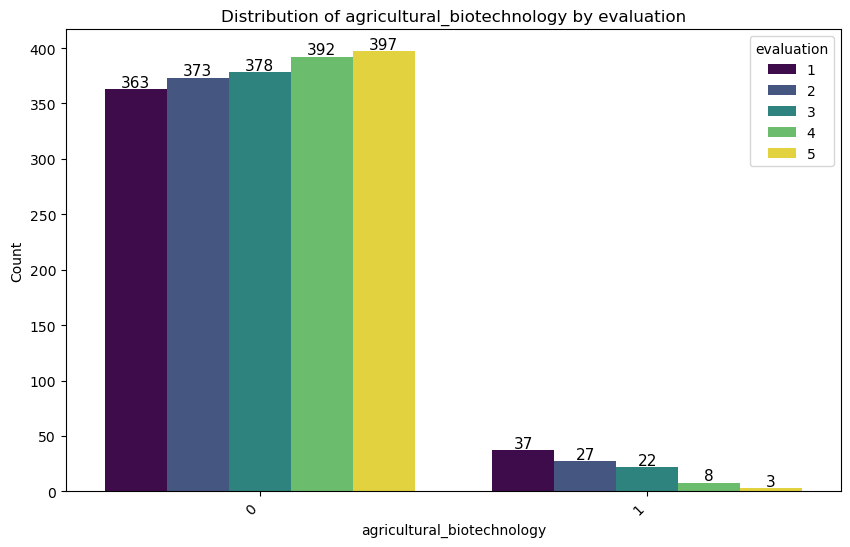

now in other_agricultural_sciences
Chi-Squared Value: 113.03211076741788
Original P-value: 1.6412627056404238e-23
Bootstrap Mean P-value: 5.460966063809327e-16
Cramér's V (Effect Size): 0.23773105683462759
Effect Size: Moderate association
Significant association between other_agricultural_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


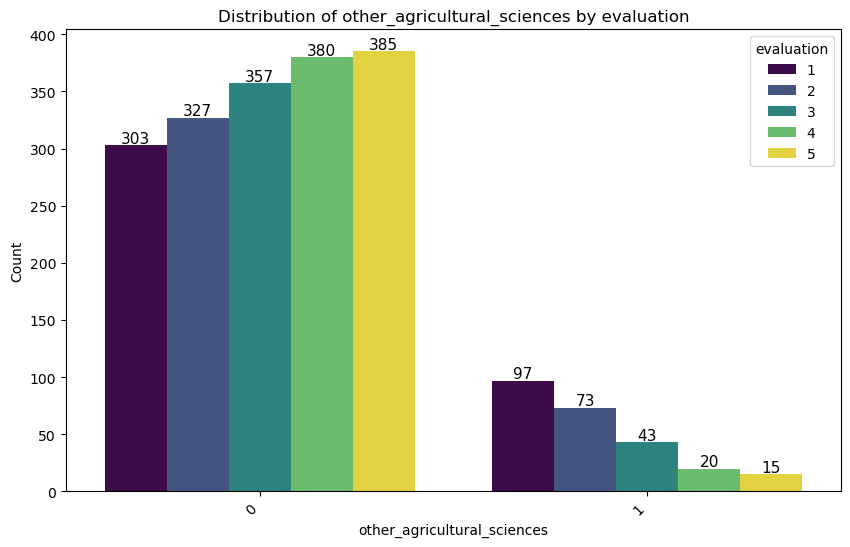

now in psychology
Chi-Squared Value: 120.73096223682134
Original P-value: 3.728454060433183e-25
Bootstrap Mean P-value: 4.046870979190653e-17
Cramér's V (Effect Size): 0.2456938768435442
Effect Size: Moderate association
Significant association between psychology and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


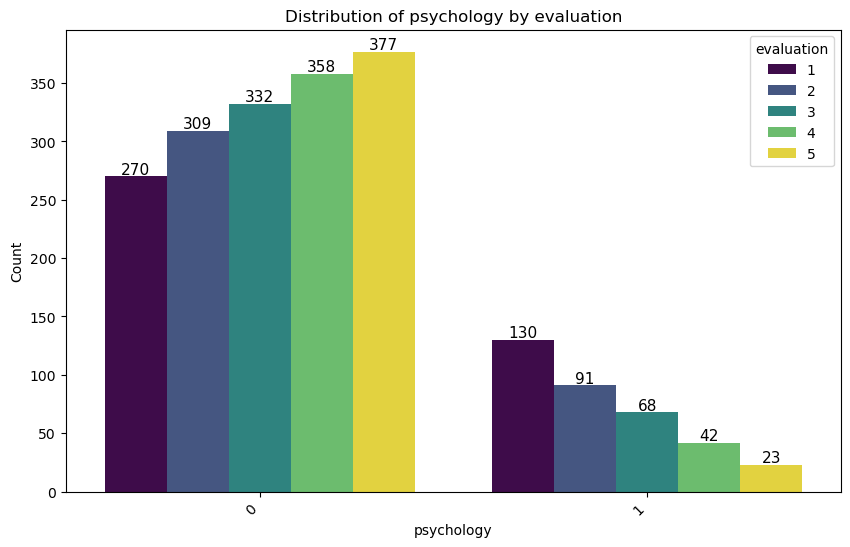

now in economics_and_business
Chi-Squared Value: 27.19926123454379
Original P-value: 1.8117460991224797e-05
Bootstrap Mean P-value: 0.002862670853665331
Cramér's V (Effect Size): 0.11661745417077109
Effect Size: Moderate association
Significant association between economics_and_business and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


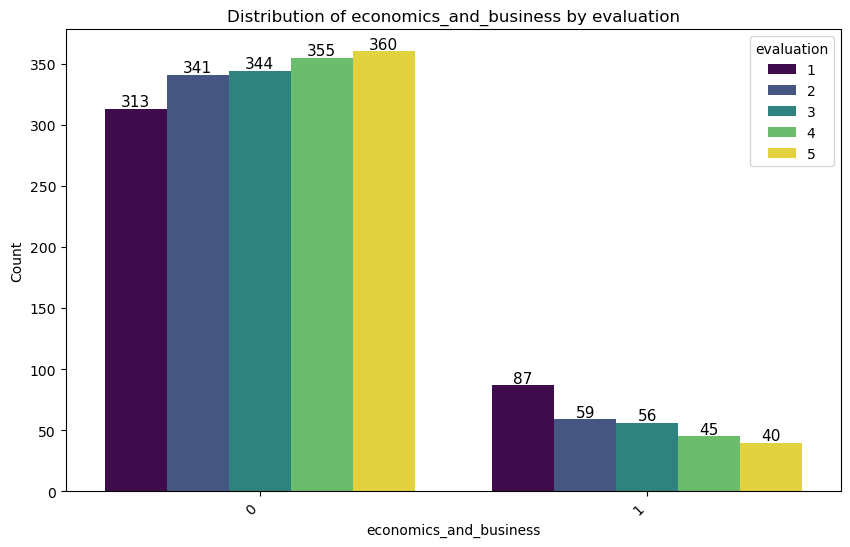

now in education
Chi-Squared Value: 33.26564478798201
Original P-value: 1.0538501190667017e-06
Bootstrap Mean P-value: 0.0002675538619574596
Cramér's V (Effect Size): 0.12896829995774545
Effect Size: Moderate association
Significant association between education and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


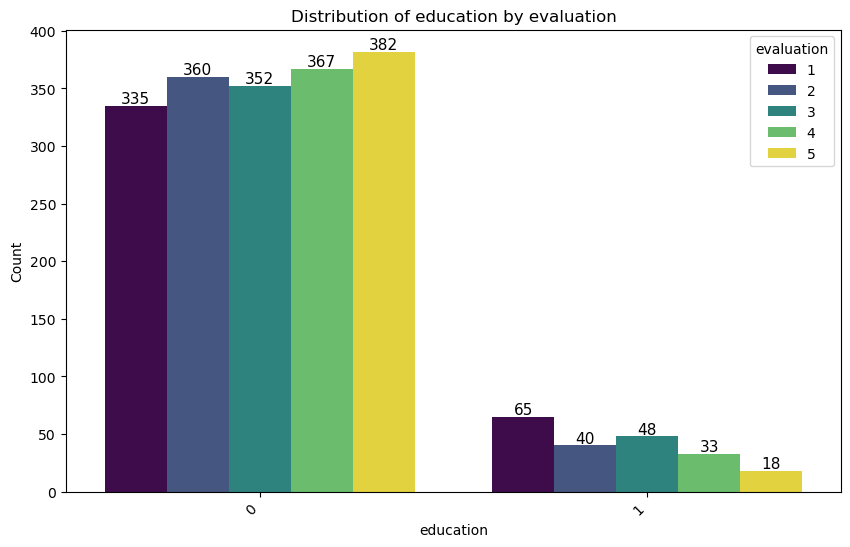

now in sociology
Chi-Squared Value: 55.77865612648221
Original P-value: 2.231290718230671e-11
Bootstrap Mean P-value: 1.4928664318036146e-07
Cramér's V (Effect Size): 0.16700098222238427
Effect Size: Moderate association
Significant association between sociology and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


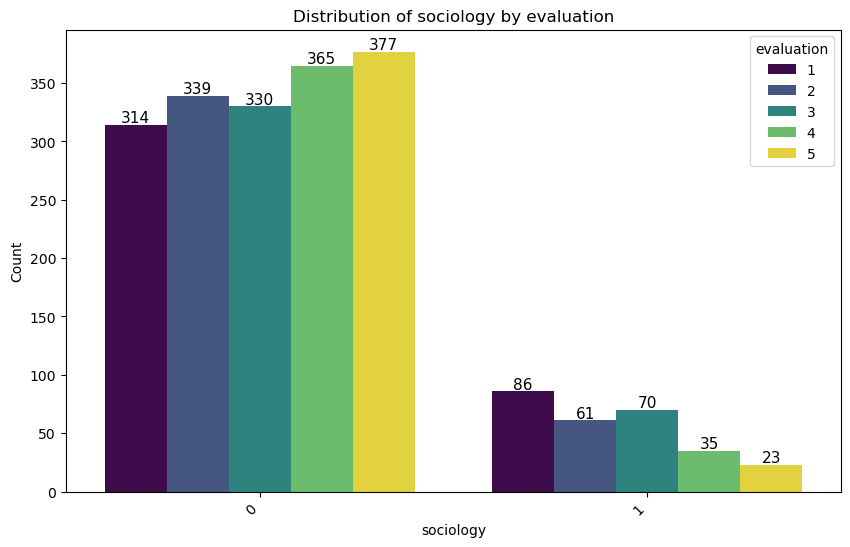

now in law
Chi-Squared Value: 57.81983973473335
Original P-value: 8.325236485044399e-12
Bootstrap Mean P-value: 6.776442782829238e-07
Cramér's V (Effect Size): 0.17002917357726197
Effect Size: Moderate association
Significant association between law and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


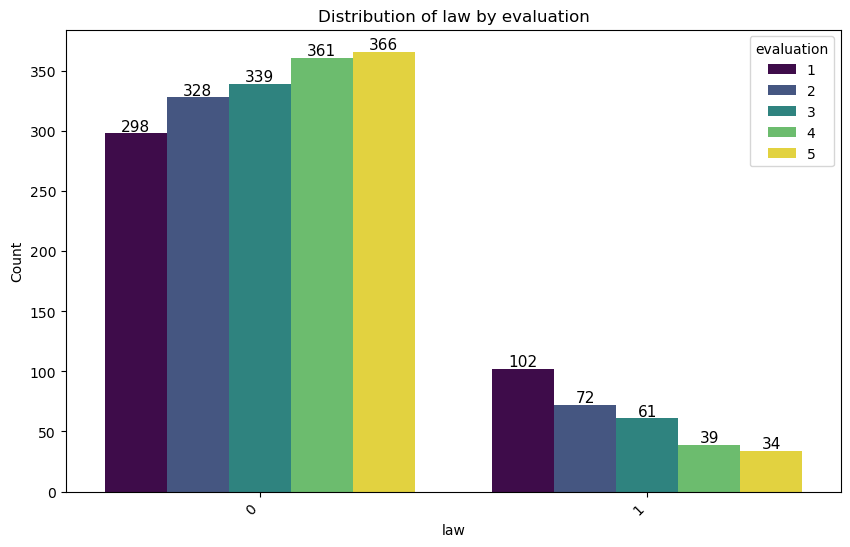

now in political_science
Chi-Squared Value: 15.086177944357125
Original P-value: 0.004525775553697879
Bootstrap Mean P-value: 0.021432373688796278
Cramér's V (Effect Size): 0.08685095838376547
Effect Size: Weak association
Significant association between political_science and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


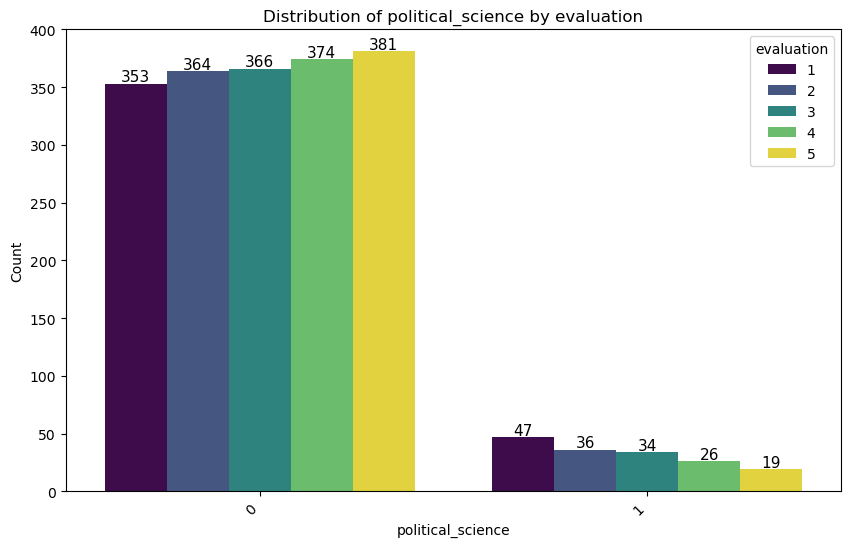

now in social_and_economic_geography
Chi-Squared Value: 34.252604748328096
Original P-value: 6.613793087687494e-07
Bootstrap Mean P-value: 0.00014252690870638469
Cramér's V (Effect Size): 0.1308674993043118
Effect Size: Moderate association
Significant association between social_and_economic_geography and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


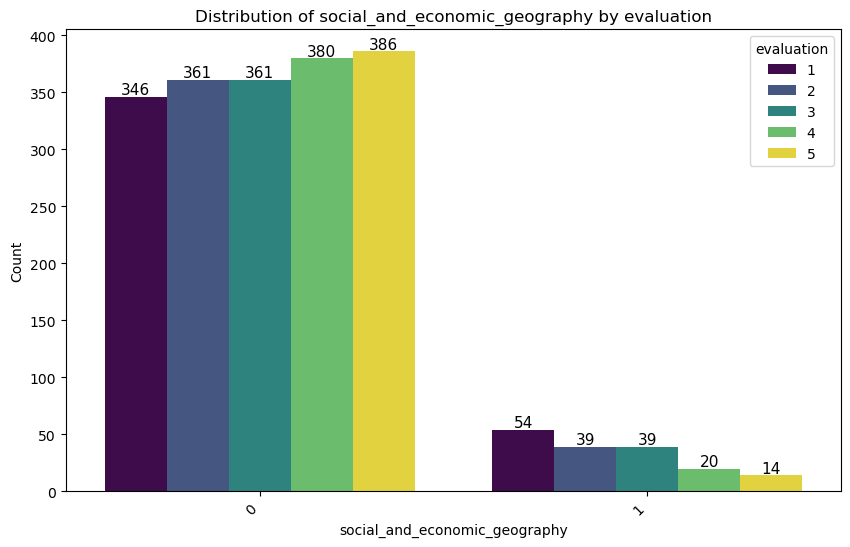

now in media_and_communications
Chi-Squared Value: 55.93852124183007
Original P-value: 2.0655792410968958e-11
Bootstrap Mean P-value: 3.1375455050462237e-06
Cramér's V (Effect Size): 0.16724012862024185
Effect Size: Moderate association
Significant association between media_and_communications and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


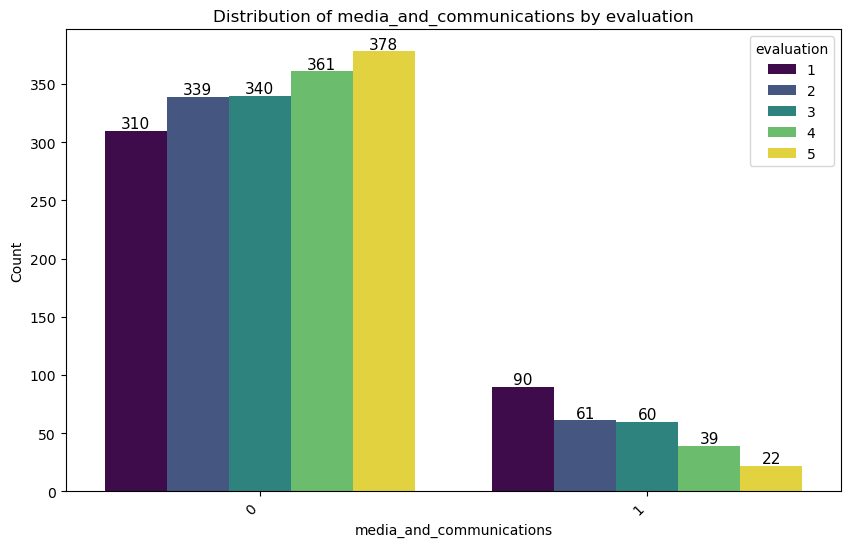

now in other_social_sciences
Chi-Squared Value: 90.84722440341312
Original P-value: 8.699910851313755e-19
Bootstrap Mean P-value: 6.936379531539319e-10
Cramér's V (Effect Size): 0.21312815910082497
Effect Size: Moderate association
Significant association between other_social_sciences and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


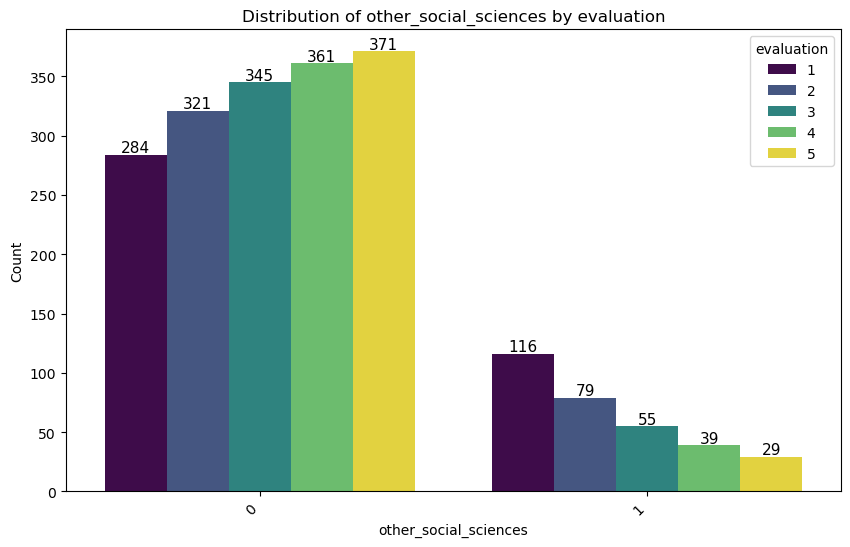

now in history_and_archaeology
Chi-Squared Value: 63.15509444001064
Original P-value: 6.294538196374285e-13
Bootstrap Mean P-value: 1.933443245814233e-08
Cramér's V (Effect Size): 0.1777007237464308
Effect Size: Moderate association
Significant association between history_and_archaeology and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


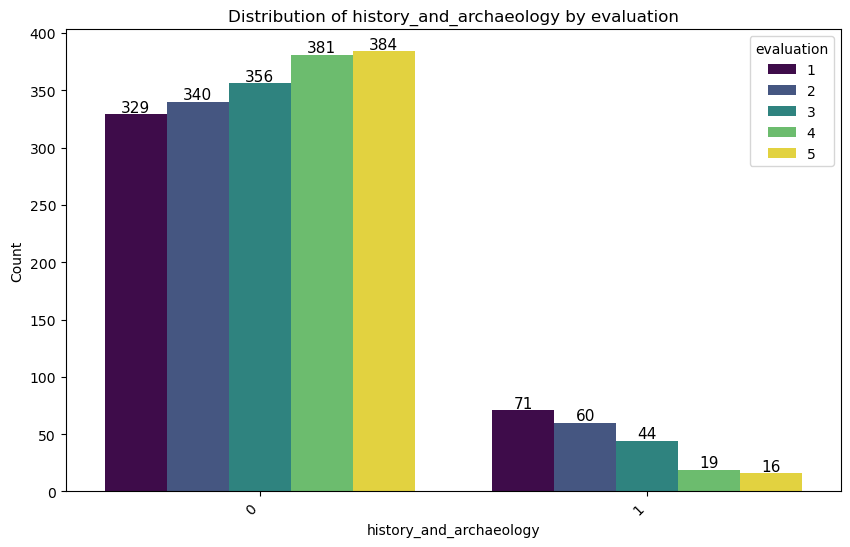

now in languages_and_literature
Chi-Squared Value: 64.29900265488982
Original P-value: 3.615147131589007e-13
Bootstrap Mean P-value: 1.326718904928637e-07
Cramér's V (Effect Size): 0.17930282018820817
Effect Size: Moderate association
Significant association between languages_and_literature and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


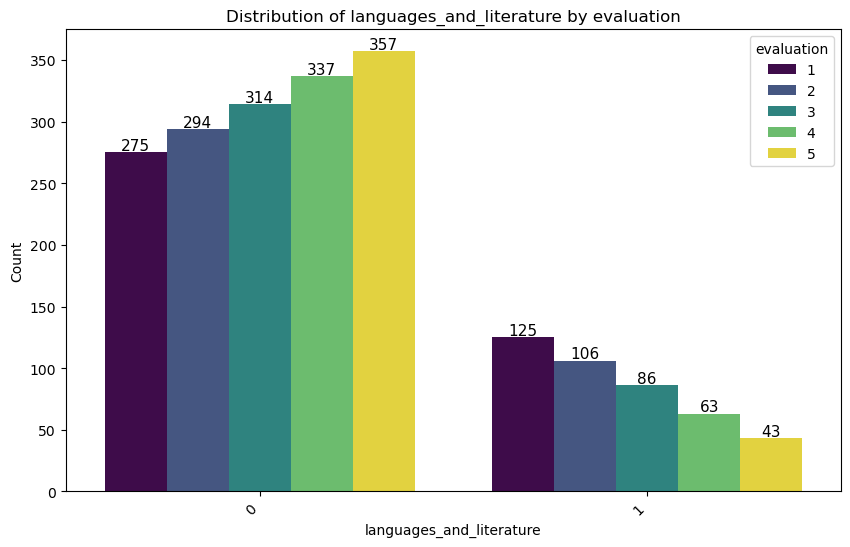

now in philosophy_ethics_and_religion
Chi-Squared Value: 50.91847880051634
Original P-value: 2.321507926106625e-10
Bootstrap Mean P-value: 1.5757022802283275e-06
Cramér's V (Effect Size): 0.15955951679626687
Effect Size: Moderate association
Significant association between philosophy_ethics_and_religion and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


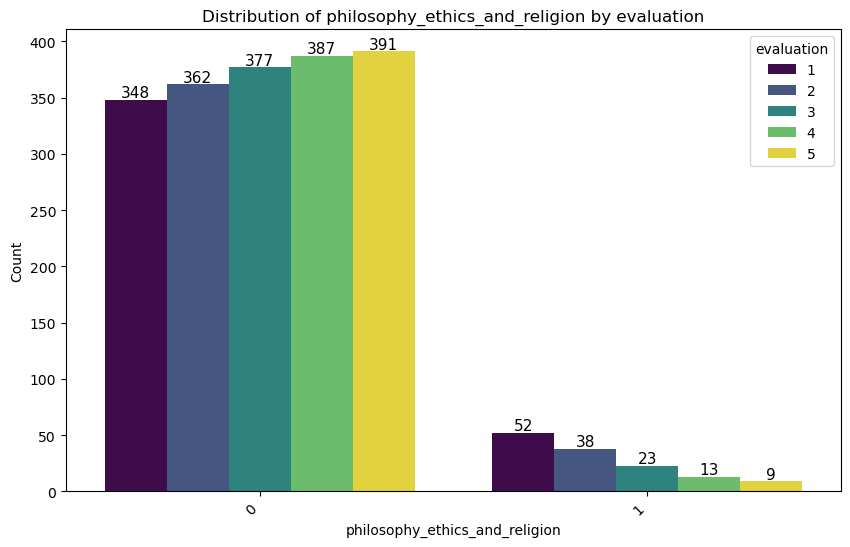

now in arts
Chi-Squared Value: 18.28379694464389
Original P-value: 0.0010860334404684253
Bootstrap Mean P-value: 0.012732121104548966
Cramér's V (Effect Size): 0.09561327560711402
Effect Size: Weak association
Significant association between arts and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


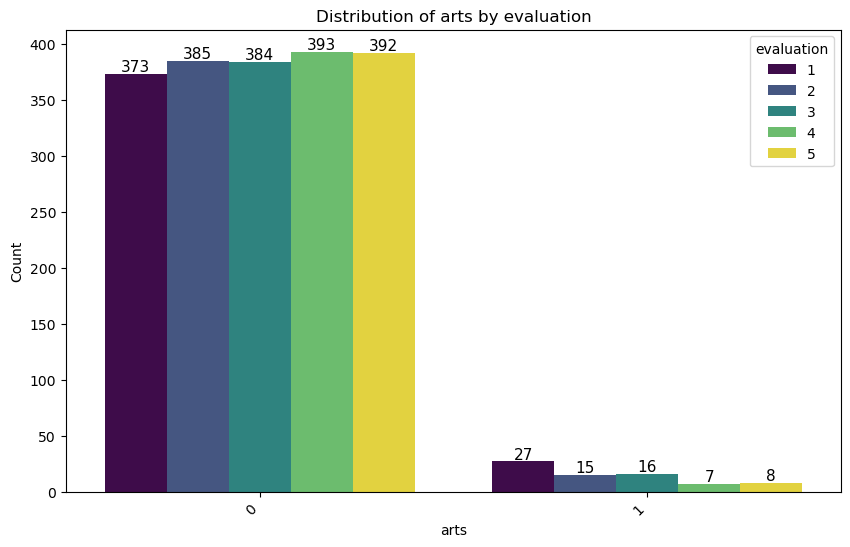

now in other_humanities_and_the_arts
Chi-Squared Value: 62.79727487245999
Original P-value: 7.486378282280144e-13
Bootstrap Mean P-value: 5.594175840912433e-07
Cramér's V (Effect Size): 0.1771966067288818
Effect Size: Moderate association
Significant association between other_humanities_and_the_arts and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


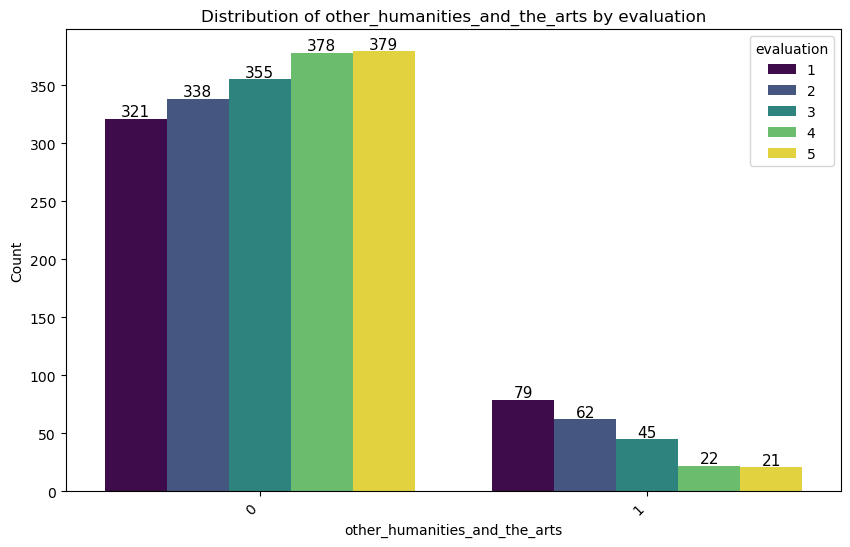

now in applied_research
Chi-Squared Value: 48.47412649270234
Original P-value: 7.516505691881802e-10
Bootstrap Mean P-value: 4.952900738188226e-06
Cramér's V (Effect Size): 0.15568257207006558
Effect Size: Moderate association
Significant association between applied_research and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


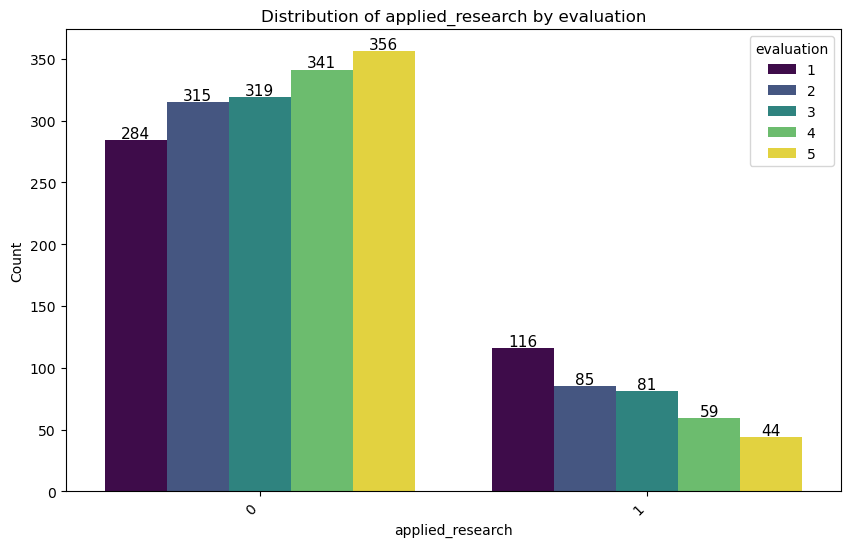

now in conclusive_research
Chi-Squared Value: 34.751188926379555
Original P-value: 5.225364645782965e-07
Bootstrap Mean P-value: 0.001988420649931366
Cramér's V (Effect Size): 0.1318165181727608
Effect Size: Moderate association
Significant association between conclusive_research and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


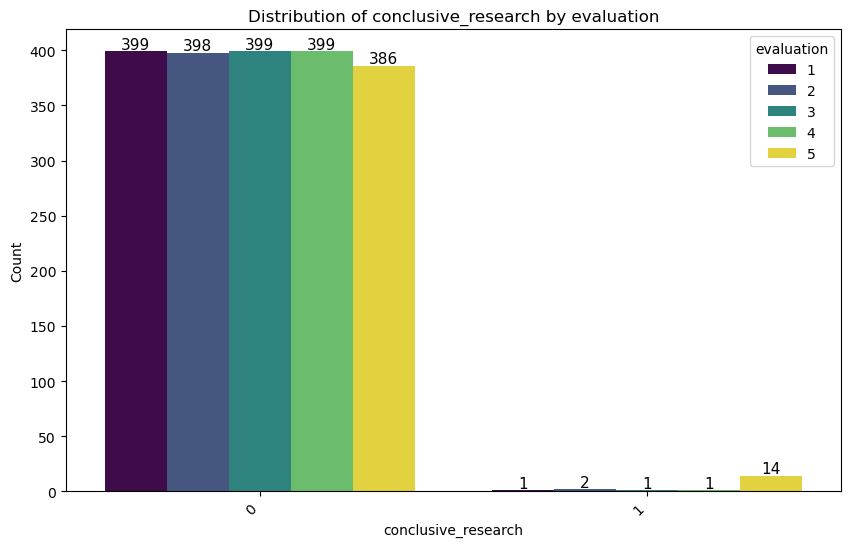

now in correlational_research
Chi-Squared Value: 16.17219313554392
Original P-value: 0.0027965991975449317
Bootstrap Mean P-value: 0.01717822416568324
Cramér's V (Effect Size): 0.0899227255357174
Effect Size: Weak association
Significant association between correlational_research and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


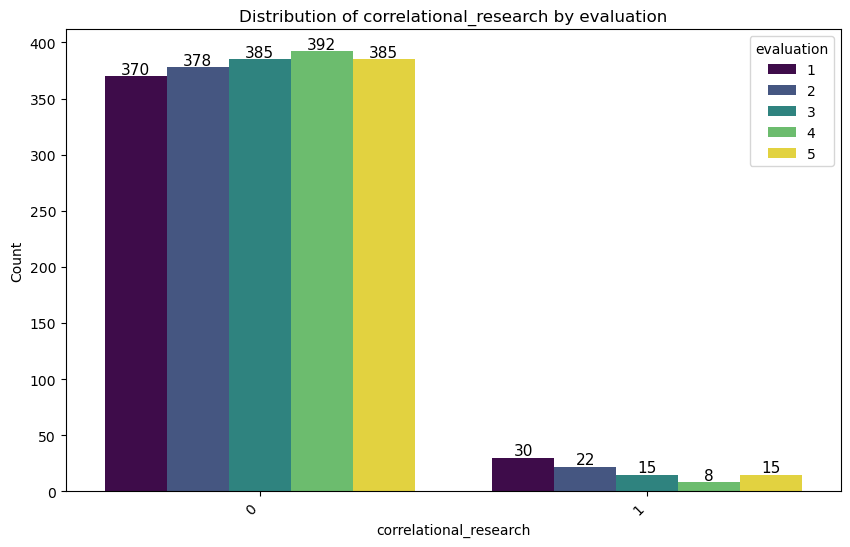

now in descriptive_research
Chi-Squared Value: 13.229671577802307
Original P-value: 0.010206429981623282
Bootstrap Mean P-value: 0.03746453477596403
Cramér's V (Effect Size): 0.08133164076115244
Effect Size: Weak association
Significant association between descriptive_research and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


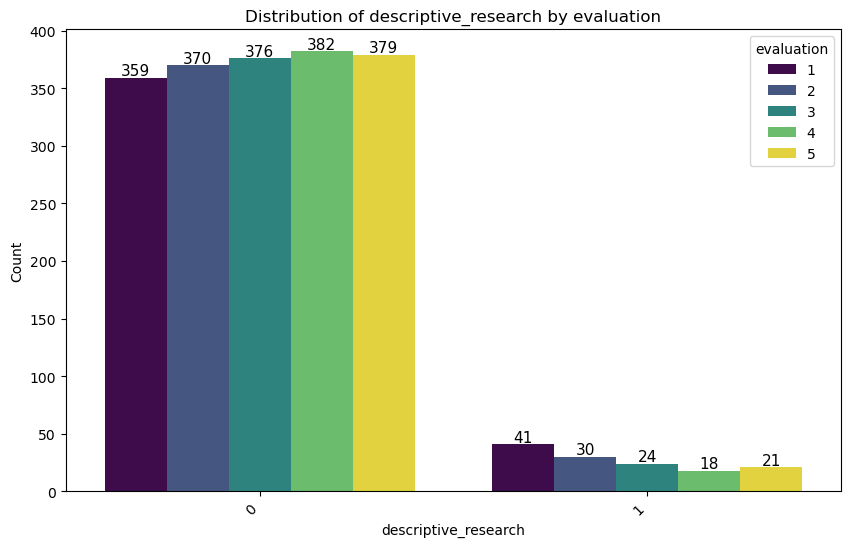

now in ethnographic_research
Chi-Squared Value: 9.73360655737705
Original P-value: 0.04516226529402489
Bootstrap Mean P-value: 0.06663715357358387
Cramér's V (Effect Size): 0.06976247758421804
Effect Size: Weak association
Significant association between ethnographic_research and evaluation.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


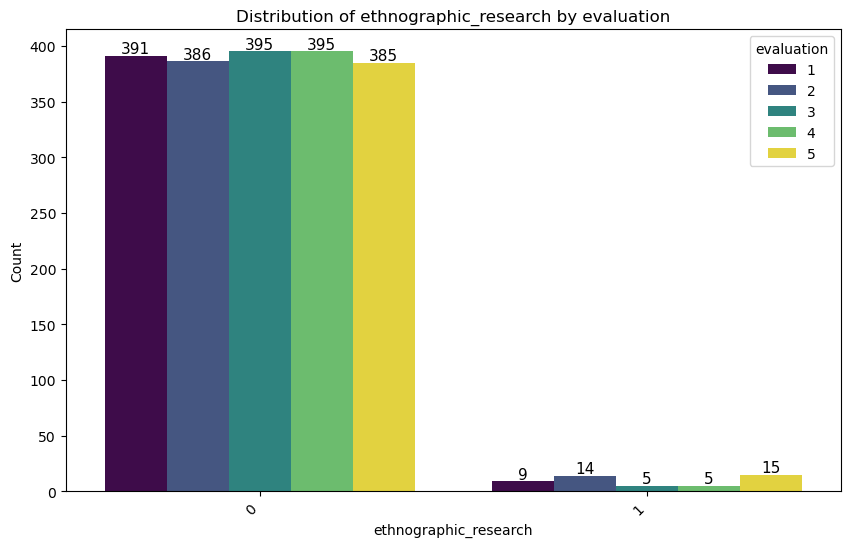

now in experiment
Chi-Squared Value: 17.625753474810075
Original P-value: 0.0014602008833185527
Bootstrap Mean P-value: 0.023577301064970052
Cramér's V (Effect Size): 0.09387692334863258
Effect Size: Weak association
Significant association between experiment and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


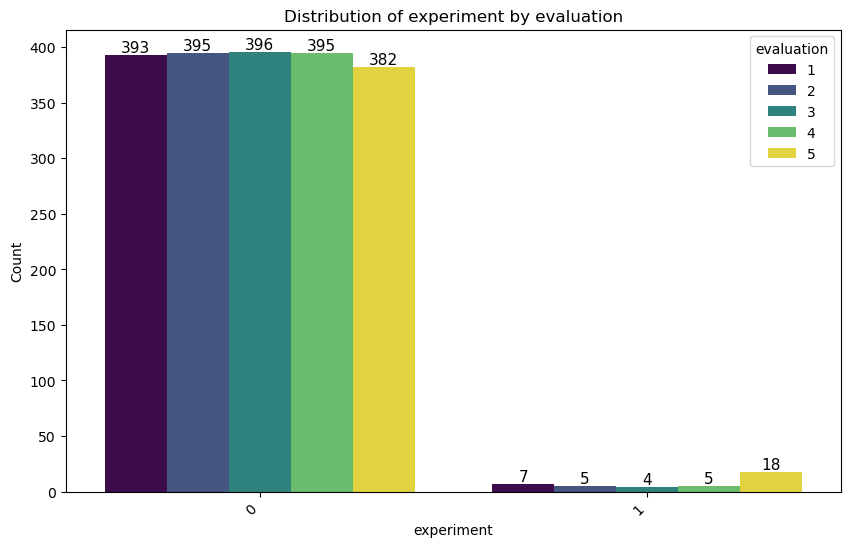

now in exploratory_research
Chi-Squared Value: 33.340200783906766
Original P-value: 1.0174343687708971e-06
Bootstrap Mean P-value: 0.0005193113089107297
Cramér's V (Effect Size): 0.12911274294953765
Effect Size: Moderate association
Significant association between exploratory_research and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


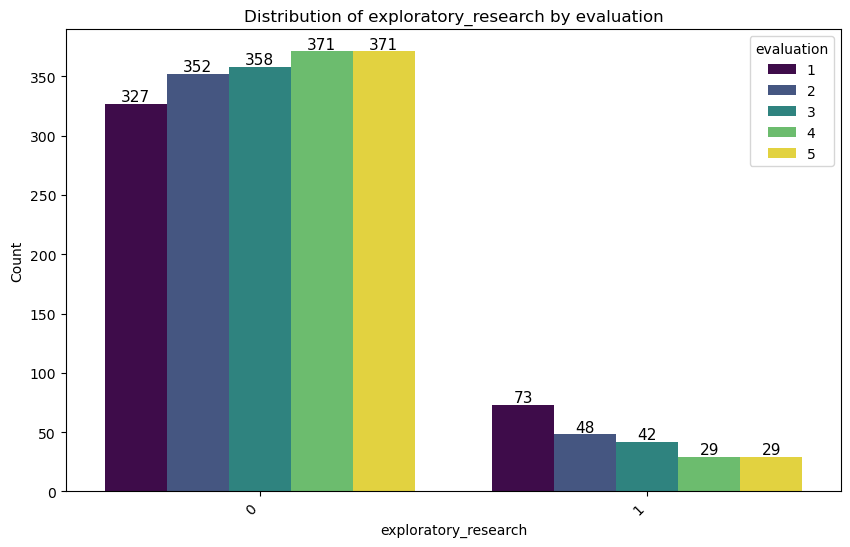

now in focus_groups
Chi-Squared Value: 37.89662518219532
Original P-value: 1.1769514961718205e-07
Bootstrap Mean P-value: 0.002090659942672818
Cramér's V (Effect Size): 0.13765286989778913
Effect Size: Moderate association
Significant association between focus_groups and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


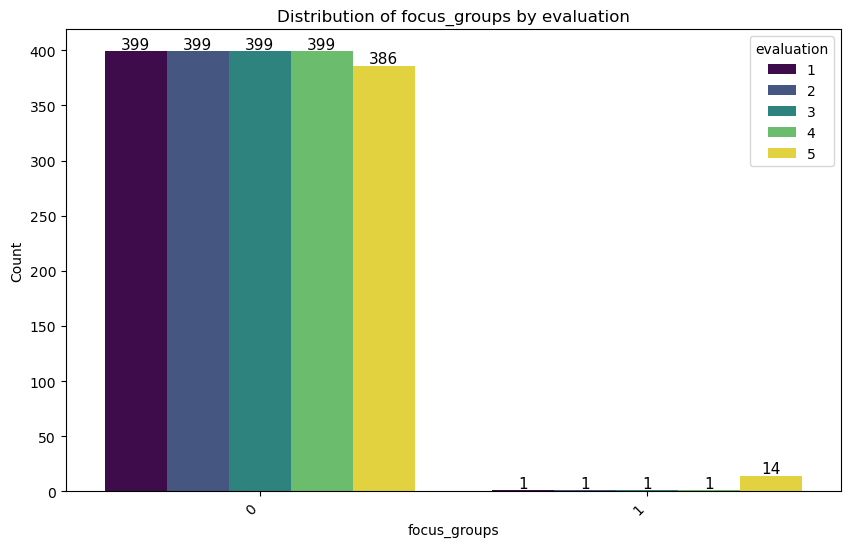

now in interviews
Chi-Squared Value: 25.095471903982546
Original P-value: 4.813425332094345e-05
Bootstrap Mean P-value: 0.0061960533151775845
Cramér's V (Effect Size): 0.11201667711546916
Effect Size: Moderate association
Significant association between interviews and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


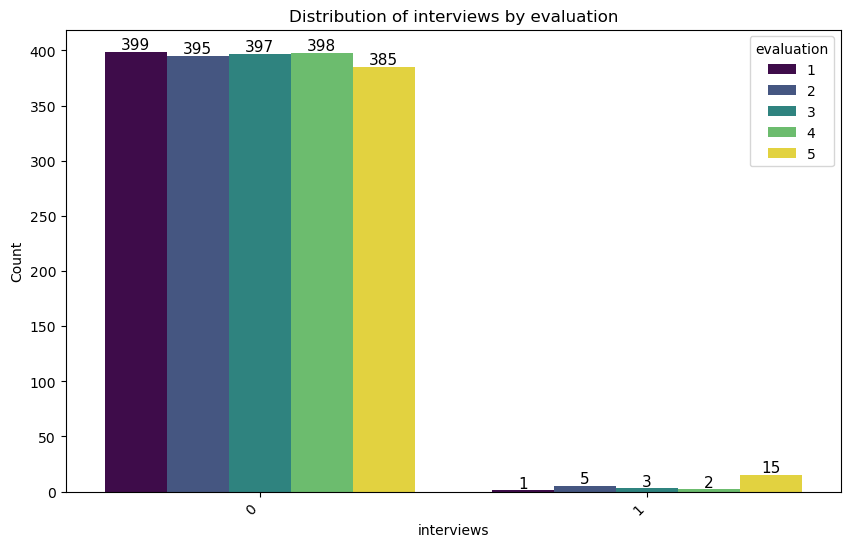

now in mixed_methods
Chi-Squared Value: 69.10554899315724
Original P-value: 3.505857017555222e-14
Bootstrap Mean P-value: 1.189333694856591e-08
Cramér's V (Effect Size): 0.18588376609208945
Effect Size: Moderate association
Significant association between mixed_methods and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


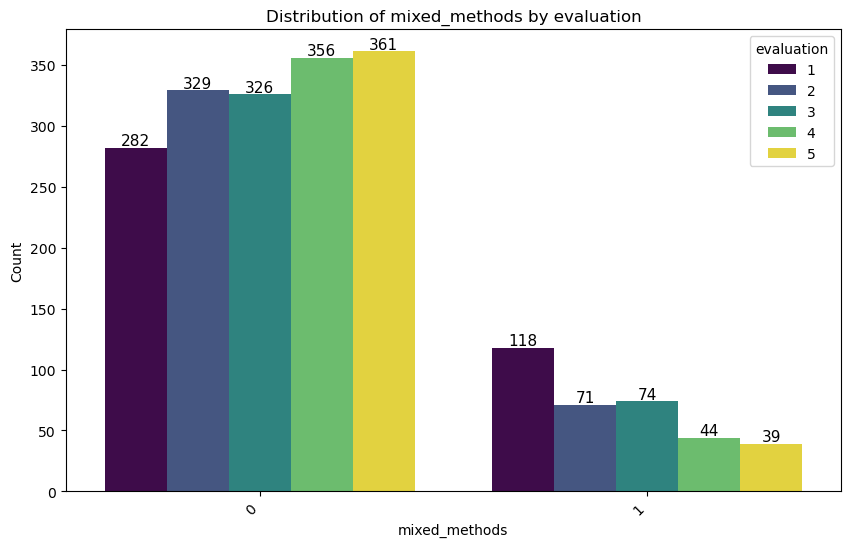

now in observation
Chi-Squared Value: 6.50352733686067
Original P-value: 0.16456826817436787
Bootstrap Mean P-value: 0.11478941249216698
Cramér's V (Effect Size): 0.05702423755238061
Effect Size: Weak association
No significant association between observation and evaluation.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


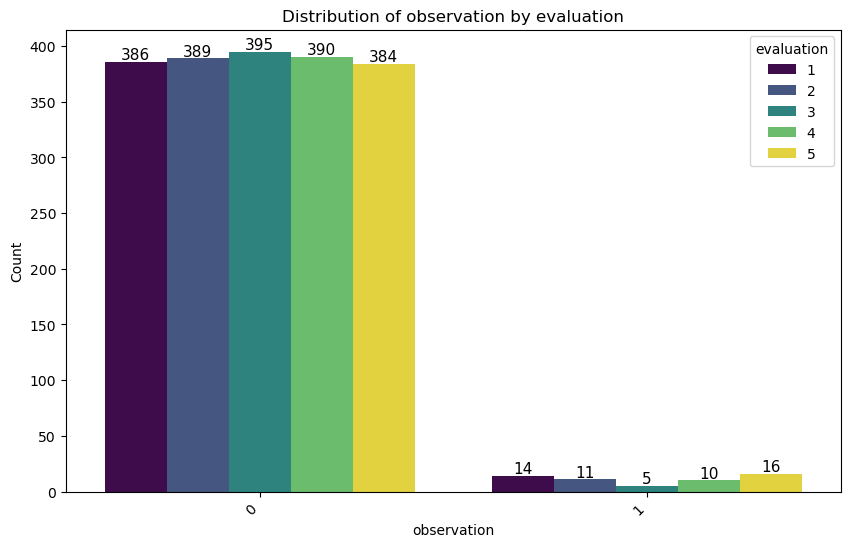

now in qualitative_research
Chi-Squared Value: 12.155046865080847
Original P-value: 0.016234780662333886
Bootstrap Mean P-value: 0.03722457959087053
Cramér's V (Effect Size): 0.07795847248721863
Effect Size: Weak association
Significant association between qualitative_research and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


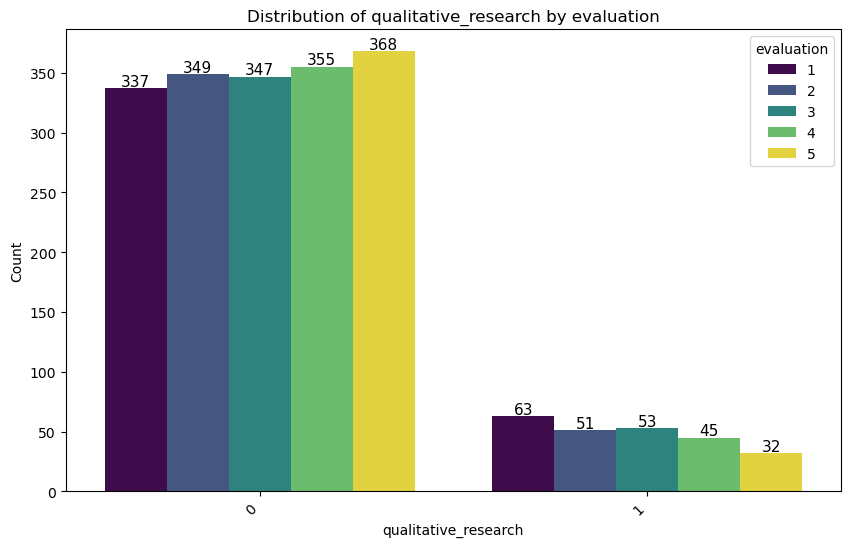

now in quantitative_research
Chi-Squared Value: 21.5794797569019
Original P-value: 0.00024298515013624063
Bootstrap Mean P-value: 0.006814498782671317
Cramér's V (Effect Size): 0.10387367269164478
Effect Size: Moderate association
Significant association between quantitative_research and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


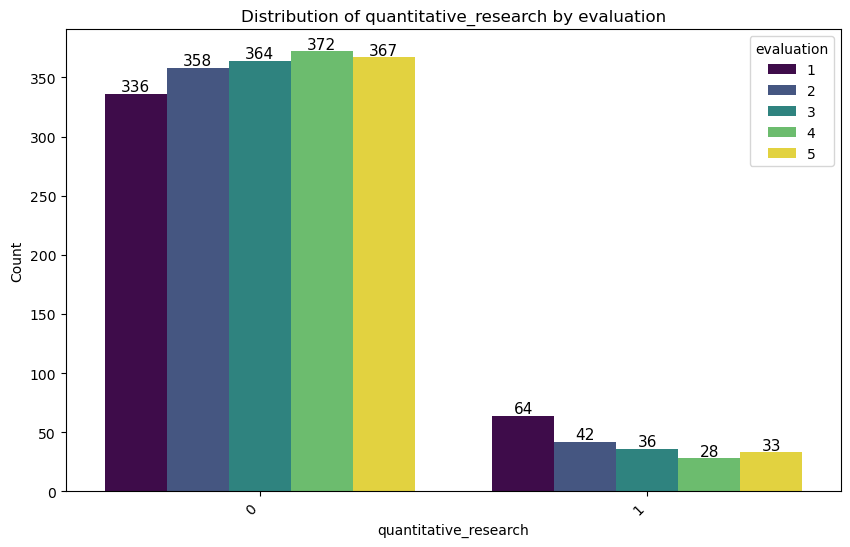

now in questionnaires
Chi-Squared Value: 42.190281357103004
Original P-value: 1.5233285420174528e-08
Bootstrap Mean P-value: 0.0004138734437890892
Cramér's V (Effect Size): 0.14524166302597716
Effect Size: Moderate association
Significant association between questionnaires and evaluation.
Bootstrap validation confirms significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


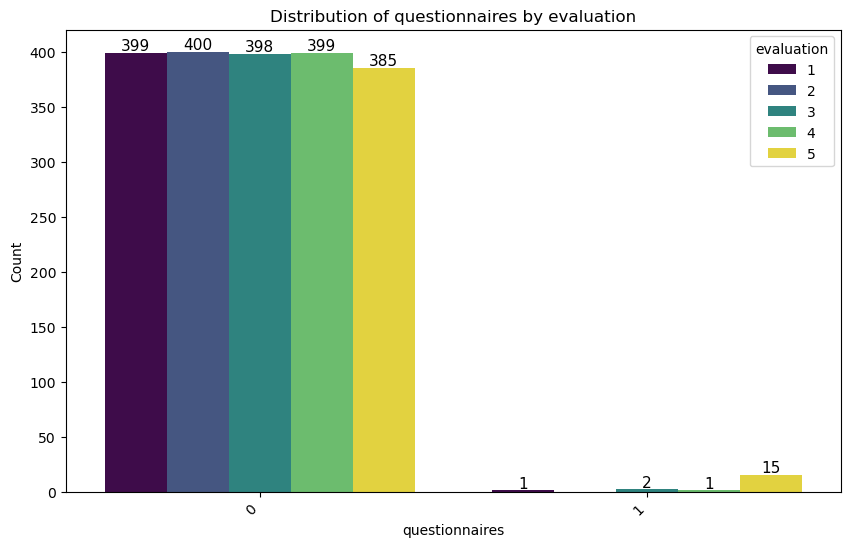

now in secondary_research
Chi-Squared Value: 9.093237704918032
Original P-value: 0.05881076714552742
Bootstrap Mean P-value: 0.07539922065978245
Cramér's V (Effect Size): 0.06742862042529875
Effect Size: Weak association
No significant association between secondary_research and evaluation.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


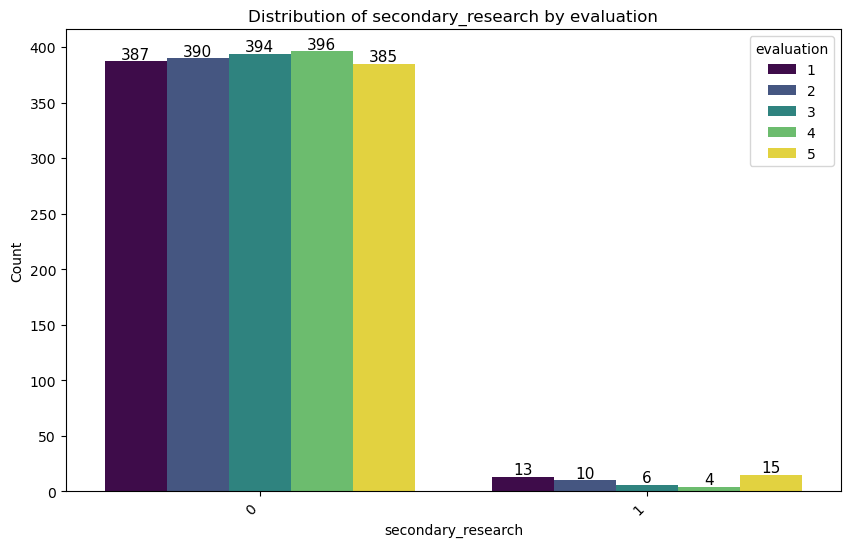

now in survey_methodology
Chi-Squared Value: 8.208594881699664
Original P-value: 0.08422911611002004
Bootstrap Mean P-value: 0.1187632692664477
Cramér's V (Effect Size): 0.06406479096079087
Effect Size: Weak association
No significant association between survey_methodology and evaluation.
Bootstrap validation does not confirm significance.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_8824\1224199557.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


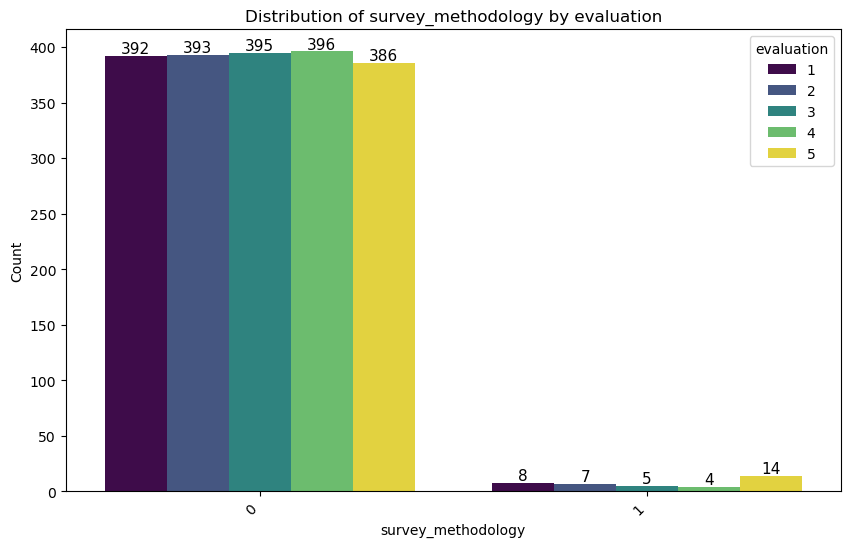

In [22]:
for col in df_m17.columns:
    if col in ['abstract', 'title', 'Unnamed: 0', 'Unnamed: 0.1', 'cited', 'science_field', 'collaborators', "journal_name", "evaluation"]:
        continue
    print(f"now in {col}")
    get_stat_significance(df_m17, col, 'evaluation')
    plot_categorical_distribution(df_m17, target_variable='evaluation', categorical_variable=col)
